# Построение модели для прогнозирования поздней отмены бронирования номеров в гостиницах сети UrbanStay

- Автор: Федоров Алексей Анатольевич
- Дата: 10.09.2026

<a id='цели-и-задачи-проекта'></a>
## Цели и задачи проекта
UrbanStay - сеть отелей среднего сегмента, которая работает давно и стабильно с хорошими финансовыми показателями, а клиенты оставляют хорошие отзывы. Однако, на доходность бизнеса влияют поздние отмены бронирований: за 48 часов и менее, который стало больше. В таких случаях, гостиница часто не успевает сдать номер и он простаивает. Чтобы увеличить загрузку гостиниц стали использовать овербукинг, но это не очень надёжная схема и возможны репутационные уроны. 
Чтобы предсказывать поздние отмены номеров, требуется создать модель, анализирующую данные киентов, включающие их предыдущие бронирования, лояльнсть, отзывы, прочее поведение и предсказывающую позднюю отмену бронирования по признакам текущих активных броней, чтобы вместо слепого овербукинга гостиницы могли начать более прицельно сдавать такие номера заранее.

Так же, модель поможет выявляя такие бронирования, снизить долю поздних отмен с 30% до 10% (целевой показатель) за счёт дополнительной работы с такими клиентами. Например, предоставлять этим клиентам гибкие даты и условия, возможно скидки или бонусы. 

Как результат снижения поздних отмен броней на 20%, UrbanStay хочет повысить загрузку гостиниц до 80% и сократить потери выручки от простоя номеров. Поэтому, ещё надо оценить экономическую эффективность модели используя три бизнес-метрики:
- динамику доли отмен бронирования (CR - Cancellation Rate);
- динамику загрузки отелей (OR - Occupancy Rate);
- прирост дохода благодаря модели (IR - Incremental Revenue).

**Динамика доли отмен бронирования (CR):**
$$\text{Динамика отмен} = \frac{\text{Доля отмен}_{\text{до}} - \text{Доля отмен}_{\text{после}}}{\text{Доля отмен}_{\text{до}}} \times 100\%$$

**Динамика загрузки отеля (OR):**
$$\text{Динамика загрузки} = \frac{\text{Загрузка отеля}_{\text{до}} - \text{Загрузка отеля}_{\text{после}}}{\text{Загрузка отеля}_{\text{до}}} \times 100\%$$


**IR (Incremental Revenue) — прирост дохода благодаря модели:**

$$IR = IR_{\text{after}} - IR_{\text{before}}$$

**Относительный IR (RIR - Relative Incremental Revenue):**
$$\text{Относительный } IR = \frac{IR_{\text{после}} - IR_{\text{до}}}{IR_{\text{до}}} \times 100\%$$

Доход до внедрения модели:
$$IR_{\text{до}} = (\text{TotalSuccess} \times \text{AvgRev}) - (\text{TotalCancellations} \times \text{LostRev})$$

Доход после внедрения модели:
$$IR_{\text{после}} = (\text{TP} \times \text{PerRebooking}) + (\text{TN} \times \text{AvgRev}) - (\text{FP} \times \text{CostFP}) - (\text{FN} \times \text{LostRev})$$


- TotalSuccess — все успешные брони, которые состоялись и были оплачены.
- AvgRev — средний доход от сдачи одного номера.
- TotalCancellations — все отмены бронирования.
- LostRev — упущенный доход от отмены одного бронирования. Равен 
- AvgRev, если нет других факторов.


- TP — верно предсказанные отмены бронирования.
- PerRebooking — стоимость повторной сдачи номеров, бронь на которые отменилась. Вовремя замеченная отмена даёт возможность сдать номер кому-то другому, это обеспечивает дополнительную прибыль.
- TN — количество случаев, когда модель не предсказала отмены и бронь действительно состоялась, гость вовремя заехал и оплатил номер.
- FP — ложные отмены бронирования — модель предсказала отмену, но гости приехали.
- CostFP — стоимость одного ложного предсказания отмены бронирования, компенсации, ущерб от потери лояльности, административные издержки.
- FN — пропущенные отмены — модель не предсказала отмену, но она произошла.


| Показатель | Значение | Комментарий |
| :--- | :--- | :--- |
| **AvgRev** | 64 500 рублей | Доход получен как среднее по фактам бронирования и по всем типам номеров. |
| **CostFP** | 7 000 рублей | В эту сумму входят компенсация гостю, административные затраты, маркетинговые издержки. |
| **LostRev** | 64 500 рублей | Упущенный доход (равен среднему доходу AvgRev). |
| **PerRebooking** | 45 000 рублей | Стоимость повторного бронирования. |


**1.** **Тип задачи** - бинарная классификация, обучение с учителем (на размеченных данных).


**2.** **Задача** - на основе данных о прошлых бронированиях клиента, отзывах, спрогнозировать позднюю отмену новой активной брони номера гостиницы.

**3.** **Цель** - получить быструю автоматическую предварительную классификацию брони по статусу отмены, чтобы правильнее планировать овербукинг, а так же, снижать число поздних отмен работая с клиентами на увеличение их лояльности и заинтересованности.


**4.** **Целевая переменная** - **`booking_status`**: 1 - отказ от брони, 0 - нет отказа.

**7.** **Модель** - ансамбль Decision Tree на основе Random Forest или градиентного бустинга: XGBoost, CatBoost или LightGBM.

**8.** **Метрики качества модели**
При обучении и отборе модели используем **ранжирующие** метрики.

 - **основная метрика:** - **IR** (показывает прирост выручки) и **PR_AUC**;
 
 - **вспомогательные:** - **Относительный IR (RIR), IR, CR, OR** и базовые метрики **F0.5-score, Precision, Recall**, как фильтр.
 
 
**9.** **Отбор лучшей модели:** - будем использовать бизнес-метрику IR, а остальные метрики как фильтры.

**10.** **Требования к модели**:
 - RIR >= 50%;
 - CR <= 10%;
 - OR  - снижение не более, чем на 8%;
 - std(RIR) / avg(RIR) ≤ 0.20 - стабильность на CV;
 - разница RIR между Train и Test <= 10% (нет переобучения).

<a id='описание-данных'></a>
## Описание данных

**hotel_bookings** - данные об истории бронирования

| Признак | Описание |
|---|---|
| `booking_id` | Уникальный номер брони. С его помощью можно идентифицировать каждое бронирование в системе. Пример: `INN000001310`. |
| `booking_date` | Дата оформления брони. Например: `18.06.2018`. |
| `sales_channel` | Способ оформления брони: `офлайн_бронирование` — через телефон, ресепшен и другие способы без использования интернета; `онлайн_бронирование` — через сайт или приложение; `корпоративное_бронирование` — от компании или организации. |
| `adult_count` | Количество взрослых гостей, которые планируют заселиться в отель. Например, значение `2` означает, что в рамках брони должны заехать как минимум два взрослых, не считая детей. |
| `child_count` | Количество детей, которые должны заселиться в отель. Например, значение `0` означает, что детей среди ожидаемых гостей нет. |
| `returning_customer` | Признак повторного клиента: `1` — клиент уже бронировал номер в сети отелей; `0` — новый клиент. |
| `previous_cancellations` | Количество отменённых бронирований у клиента в прошлом. Например, значение `0` означает, что клиент ранее не отменял бронирования, а `2` — что отменил две брони. |
| `previous_no_shows` | Количество случаев, когда клиент бронировал номер и в итоге заселялся. Например, значение `1` означает один подтверждённый заезд, а `0` — отсутствие подтверждённых заездов. |
| `booking_value` | Итоговая стоимость бронирования в рублях. |
| `days_until_checkin` | Количество дней от момента оформления брони до даты заселения. Например, значение `204` означает, что между бронированием и заездом запланировано 204 дня. |
| `weekend_nights` | Количество ночей в периоде проживания, которые приходятся на выходные дни — субботу и воскресенье. Например, значение `4` означает четыре ночи в выходные дни. |
| `weekday_nights` | Количество ночей в периоде проживания, которые приходятся на будние дни — с понедельника по пятницу. Например, значение `2` означает две ночи в будние дни. |
| `meal_plan` | Выбранный гостями тип питания. Примеры: `тип_питания_1`, `тип_питания_2`. |
| `parking_included` | Признак бронирования парковочного места. Например, значение `0` означает, что парковка не бронировалась. |
| `room_type` | Категория номера или номеров в брони. Примеры: `тип_1`, `тип_4`. |
| `customer_special_requests` | Количество комментариев и пожеланий клиента: например, просьб о дополнительной кровати, раннем заезде и других услугах. |
| `booking_status` | Целевая переменная, обозначающая текущий статус бронирования: `отказ_брони` — бронирование отменено; `нет_отказа` — бронирование активно и не отменено. |

**hotel_reviews** - данные по истории отзывов о проживании

| Признак | Описание |
|---|---|
| `customer_id` | Уникальный идентификатор клиента. Например, `C0003`. Используется, чтобы связать отзыв с его автором — конкретным гостем. |
| `booking_id` | Идентификатор брони, по которой оставлен отзыв. Например, `INN000201614`. Связывает отзыв с конкретной поездкой. |
| `review_date` | Дата, когда клиент оставил отзыв. Например, `2018-11-21`. Показывает, когда была получена обратная связь. |
| `stay_rating` | Оценка, которую клиент поставил проживанию: `1` — низший балл, `5` — высший балл. |
| `review_text` | Развёрнутый комментарий клиента о проживании. Содержит качественную обратную связь: что понравилось, а что нет. Пример: «Неплохо. Приветливый персонал на ресепшн, но завтрак однообразный. Питание в ресторане понравилось». |

<a id='подготовка-среды-и-библиотек'></a>
## Подготовка среды и библиотек
### Зависимости
Самый правильный и 100% надёжный безпроблемный вариант - использовать venv + kernel. Это даёт полную изоляцию окружения для тетради, кроме того, собственную изолированную версию Python для venv, которую умеет ставить Conda:
```
conda create -y -n "${ENV_NAME}" python="${PYTHON_VERSION}"
```
Однако, ревьюверы почему-то не любят переключать ядра Jupyter, поэтому, будем использовать установку библиотек в домашнюю папку под Python 3.9. При этом не исключены конфликты версий.

#### Обновляем pip, чтобы работал --dry-run.

In [1]:
%pip install --upgrade --user --disable-pip-version-check -i https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple pip

Looking in indexes: https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple
    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


In [2]:
# .local/lib/python3.9/site-packages должен стоять до глобального окружения
import sys
for p in sys.path:
    print(p)

/home/jovyan/work
/opt/conda/lib/python39.zip
/opt/conda/lib/python3.9
/opt/conda/lib/python3.9/lib-dynload

/home/jovyan/.local/lib/python3.9/site-packages
/opt/conda/lib/python3.9/site-packages
/opt/conda/lib/python3.9/site-packages/IPython/extensions
/home/jovyan/.ipython


In [3]:
%pip -V

pip 26.0.1 from /home/jovyan/.local/lib/python3.9/site-packages/pip (python 3.9)
Note: you may need to restart the kernel to use updated packages.


#### Проверяем зеркала репозиториев pip на скорость ответа
Если проблемы с доступностью репозитория pip по-умолчанию, то рассмотреть из списка и передать ключом -i в pip, в последующих двух командах.

In [4]:
"""
import time
import requests

mirrors = {
    "PyPI": "https://pypi.org/simple/",
    "USTC": "https://mirrors.ustc.edu.cn/pypi/simple/",
    "TUNA": "https://mirrors.tuna.tsinghua.edu.cn/pypi/web/simple/",
    "Aliyun": "https://mirrors.aliyun.com/pypi/simple/",
    "SUSTech": "https://mirrors.sustech.edu.cn/pypi/web/simple/",
    "ZJU": "https://mirrors.zju.edu.cn/pypi/web/simple/",
    "Douban": "https://pypi.douban.com/simple/",
    "Baidu": "https://mirror.baidu.com/pypi/simple/",
}

results = []

for name, url in mirrors.items():
    try:
        start = time.perf_counter()

        response = requests.get(url, timeout=3)
        response.raise_for_status()

        elapsed = time.perf_counter() - start
        size_bytes = len(response.content)
        size_mb = size_bytes / 1024 / 1024
        speed_mbps = size_mb / elapsed

        results.append({
            "mirror": name,
            "status_code": response.status_code,
            "time_sec": elapsed,
            "size_mb": size_mb,
            "speed_mb_sec": speed_mbps,
        })

    except requests.RequestException as error:
        results.append({
            "mirror": name,
            "status_code": "ERROR",
            "time_sec": None,
            "size_mb": None,
            "speed_mb_sec": None,
            "error": str(error),
        })
        
results_sorted = sorted(
    (
        result for result in results
        if result["speed_mb_sec"] is not None
    ),
    key=lambda result: result["speed_mb_sec"],
    reverse=True
)

for result in results_sorted:
    print(
        f"{result['mirror']:10} | "
        f"{result['size_mb']:.2f} MB | "
        f"{result['time_sec']:.3f} сек | "
        f"{result['speed_mb_sec']:.2f} MB/сек"
    )
""";

#### Проверяем наличие scikit-learn нужной версии через --dry-run.

In [5]:
%pip install --dry-run --only-binary=:all: --disable-pip-version-check scikit-learn==1.5.2        

Note: you may need to restart the kernel to use updated packages.


Тут ставим зависимости. --user - ставит в домашнюю папку пользователя /home/xxx_user_name/.local/lib, а не в /opt/conda/lib. В sys.path прописана сначала папка пользователя, поэтому модули возьмутся оттуда.

--only-binary - не используется компиляция, а только Wheels - готовые бинарники.

In [6]:
%pip install --user --only-binary=:all: --disable-pip-version-check --no-warn-script-location \
    numpy==1.26.4 \
    scipy==1.13.1 \
    pandas==2.1.4 \
    scikit-learn==1.5.2 \
    matplotlib==3.8.2 \
    seaborn==0.13.0 \
    statsmodels==0.14.1 \
    phik==0.12.5 \
    jinja2==3.1.4 \
    numba==0.58.1 \
    llvmlite==0.41.1 \
    patsy==0.5.6 \
    joblib==1.4.2 \
    threadpoolctl==3.5.0 \
    optuna==3.6.1 \
    dill==0.3.8 \
    packaging==24.2 \
    ipywidgets==8.1.5 \
    catboost==1.2.7 \
    lightgbm==4.5.0 \
    "tqdm>=4.66" \
    shap==0.44.1 \
    sqlalchemy \
    psycopg2-binary \
    python-dotenv \
    nltk==3.9.2 

    matplotlib-inline (<0.2.0appnope,>=0.1.0) ; platform_system == "Darwin"
                      ~~~~~~~~^
Note: you may need to restart the kernel to use updated packages.


#### Проверяем, что встало

In [7]:
# Тест на ложную тревогу в логе pip по ipykernel 
import importlib.util, sys
spec = importlib.util.find_spec("ipykernel")
print("ipykernel найден:", spec is not None)
if spec:
    print("путь:", spec.origin)
import ipykernel
print("версия:", ipykernel.__version__)

ipykernel найден: True
путь: /opt/conda/lib/python3.9/site-packages/ipykernel/__init__.py
версия: 6.0.1


In [8]:
import sys, os
print(sys.version, '\n')
print(f"python      : {sys.version.split()[0]}\n")

import numpy, scipy, pandas, sklearn, optuna, dill, phik, numba, matplotlib, seaborn, statsmodels, tqdm, sqlalchemy

for m in (numpy, scipy, pandas, sklearn, optuna, dill, phik, numba, matplotlib, seaborn,
          statsmodels, tqdm, sqlalchemy):
    print(f"{m.__name__:18s} {m.__version__:12s} <- {m.__file__.split('site-packages')[0]}site-packages")

3.9.5 | packaged by conda-forge | (default, Jun 19 2021, 00:32:32) 
[GCC 9.3.0] 

python      : 3.9.5

numpy              1.26.4       <- /home/jovyan/.local/lib/python3.9/site-packages
scipy              1.13.1       <- /home/jovyan/.local/lib/python3.9/site-packages
pandas             2.1.4        <- /home/jovyan/.local/lib/python3.9/site-packages
sklearn            1.5.2        <- /home/jovyan/.local/lib/python3.9/site-packages
optuna             3.6.1        <- /home/jovyan/.local/lib/python3.9/site-packages
dill               0.3.8        <- /home/jovyan/.local/lib/python3.9/site-packages
phik               0.12.5       <- /home/jovyan/.local/lib/python3.9/site-packages
numba              0.58.1       <- /home/jovyan/.local/lib/python3.9/site-packages
matplotlib         3.8.2        <- /home/jovyan/.local/lib/python3.9/site-packages
seaborn            0.13.0       <- /home/jovyan/.local/lib/python3.9/site-packages
statsmodels        0.14.1       <- /home/jovyan/.local/lib/python3.

👉 Если тут ошибка, то **Нужен Restart Kernel !!!**

####  Удаление (очистка) установленных модулей
Этот код нужно раскомментить и выполнить после проверки работы или в случае проблем с установкой, если был непустой `/home/xxx_user_name/.local/lib/python3.9/site-packages/`

In [9]:
"""
import site, shutil, os, sys

user_site = site.getusersitepackages()
print("USER_SITE:", user_site)
print("Существует:", os.path.isdir(user_site))

if os.path.isdir(user_site):
    print("Содержимое (первые 40):")
    for name in sorted(os.listdir(user_site))[:40]:
        print("  ", name)
""";

In [10]:
"""
shutil.rmtree(user_site, ignore_errors=True)
print("Удалено. Перезапустите ядро: Kernel → Restart Kernel")
""";

<a id='импорты-библиотек'></a>
### Импорты библиотек

In [11]:
# ============================== Standard ==============================
import contextlib
import gc
import inspect
import os
import sys
import time
import warnings
from dataclasses import dataclass, field, fields
from datetime import datetime
from functools import reduce
from itertools import combinations
from pprint import pprint
from typing import Protocol
from typing import Callable, Iterable, Protocol, Sequence, Optional, Any, List, Tuple

# ============================== Third-party ==================================
import dill
import joblib
import numpy as np
import pandas as pd
from joblib import Memory

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

from scipy.stats import normaltest, ttest_rel, chi2_contingency, spearmanr
from scipy import stats
from statsmodels.stats.proportion import proportion_confint

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import PercentFormatter
import seaborn as sns

import phik
from phik.report import plot_correlation_matrix

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from optuna.exceptions import TrialPruned
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

from IPython.display import HTML, Markdown, display, display_html

from tqdm import tqdm

# ============================== scikit-learn =================================
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin, clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import VarianceThreshold
from sklearn.dummy import DummyClassifier

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.metrics import (    
    average_precision_score,
    precision_score,
    roc_auc_score,
    recall_score,
    fbeta_score,
    brier_score_loss, 
    log_loss, 
    roc_auc_score
)

from sklearn.calibration import CalibratedClassifierCV, calibration_curve

from sklearn.model_selection import (
    cross_validate,
    cross_val_predict,
    train_test_split,
    KFold,
    cross_val_score,
    TimeSeriesSplit
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    KBinsDiscretizer,
)

# ============================== Boosting models ===============================
from catboost import CatBoostClassifier
import catboost as cb

import lightgbm as lgb 
from lightgbm import LGBMClassifier

import shap

# ============================== nltk ===============================
import nltk
nltk.download('stopwords') # Скачиваем все стоп-слова
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<a id='общие-функции'></a>
### Общие функции
<a id='базовые'></a>
#### Базовые

In [12]:
def to_snake_case_columns(dataframe: pd.DataFrame) -> None:
    """Приводит названия колонок к snake_case прямо в исходном датафрейме."""
    dataframe.columns = (
        dataframe.columns
        .str.replace(r'[\s/()\-%,.]+', '_', regex=True)  # Замена спецсимволов и пробелов на _
        .str.replace(r'^_+|_+$', '', regex=True)         # Удаление подчеркиваний на концах
        .str.lower()                                     # Перевод в нижний регистр
    )
    
    
def get_integer_features_info(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Находит признаки, содержащие только целые числа (игнорируя NaN/пропуски),
    и возвращает DataFrame с их именами и кардинальностью.
    """
    integer_features = []
    cardinalities = []
    
    for col in dataframe.columns:
        # Удаляем пропуски для корректной проверки значений
        clean_col = dataframe[col].dropna()
        
        # Если колонка стала пустой после удаления NaN, пропускаем её
        if clean_col.empty:
            continue
            
        # Проверяем, является ли колонка числовой
        if pd.api.types.is_numeric_dtype(clean_col):
            # Проверяем, что все значения являются целыми (остаток от деления на 1 равен 0)
            if (clean_col % 1 == 0).all():
                integer_features.append(col)
                cardinalities.append(clean_col.nunique())
        else:
            # Если тип object/string, пробуем привести к числу
            try:
                converted = pd.to_numeric(clean_col)
                if (converted % 1 == 0).all():
                    integer_features.append(col)
                    cardinalities.append(converted.nunique())
            except (ValueError, TypeError):
                continue
                
    # Формируем итоговый DataFrame
    result_df = pd.DataFrame({
        'feature_name': integer_features,
        'cardinality': cardinalities
    })
    
    return result_df
    
def downcast_columns_for_ml(data_frame, *, ints=None, floats=None, cats=None):
    """Приводит колонки к оптимальным NumPy-типам для ML с downcast.

    - Integer колонки: int64 -> int8/16/32/64 в зависимости от диапазона.
    - Float колонки: float64 -> float32.
    - Object/String колонки: object -> category (для экономии памяти и ML).

    ВАЖНО: В отличие от Extended-типов pandas, стандартные целочисленные типы
    NumPy (int8-int64) НЕ поддерживают NaN. Если в целочисленной колонке есть
    пропуски, pandas принудительно оставит её в типе float32/64.
    """

    ints_actual = (
        set(ints) if ints is not None
        else set(data_frame.select_dtypes(include="integer").columns)
    )
        
    floats_actual = (
        set(floats) if floats is not None
        else set(data_frame.select_dtypes(include="float").columns)
    ) - ints_actual    
    
    cats_actual = (
        set(cats) if cats is not None
        else set(data_frame.select_dtypes(include=["object", "string"]).columns)
    )

    for col in ints_actual:
        # Приводим к числовому типу NumPy
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")

        # Если в колонке есть NaN, NumPy int не сможет её сохранить.
        # В таком случае переводим её во float32, чтобы не ломать ML-алгоритмы.
        if data_frame[col].isnull().any():
            data_frame[col] = data_frame[col].astype(np.float32)
            continue

        col_min, col_max = data_frame[col].min(), data_frame[col].max()

        if col_min >= -128 and col_max <= 127:
            data_frame[col] = data_frame[col].astype(np.int8)
        elif col_min >= -32768 and col_max <= 32767:
            data_frame[col] = data_frame[col].astype(np.int16)
        elif col_min >= -2147483648 and col_max <= 2147483647:
            data_frame[col] = data_frame[col].astype(np.int32)
        else:
            data_frame[col] = data_frame[col].astype(np.int64)

    for col in floats_actual:
        data_frame[col] = pd.to_numeric(data_frame[col], errors="coerce")
        data_frame[col] = data_frame[col].astype(np.float32)

    # Для ML текстовые признаки переводим в категориальный тип, а не в string
    for col in cats_actual:
        data_frame[col] = data_frame[col].astype("category")

    return data_frame

<a id='базовый-eda'></a>
#### Базовый EDA

In [13]:
def get_missings(df, hide_zeros = False):
    missing_df = df.isna().sum().to_frame(name='missing_count')
    missing_df['missing_percent'] = (df.isna().mean() * 100).round(2)
    if hide_zeros:
        missing_df = missing_df.query('missing_percent > 0')
    
    return missing_df.sort_values(by='missing_percent', ascending=False)

def report_row_removing(before, after):
    print(f'✅ Из датасета в {before} строк удалено 🗑️ {before - after} строк,\n'
        f'\tосталось: {after} строк,\n'
        f'\tпроцент потерь: {round((before - after) / before * 100, 2)}%.')

def get_missing_rows_info(dataframe: pd.DataFrame) -> dict:
    """Возвращает количество и процент строк, содержащих хотя бы один пропуск."""
    missing_mask = dataframe.isna().any(axis=1)
    
    total_missing = missing_mask.sum()
    percent_missing = (missing_mask.mean() * 100).round(2)
    
    return {
        'missing_rows_count': total_missing,
        'missing_rows_percent': percent_missing
    }
            
def get_whiskers(values, coeff=1.5, left=None, right=None):
    """
        Возвращает усы ящика для серии values.
    """
    Q1 = values.quantile(0.25)
    Q3 = values.quantile(0.75)
    IQR = Q3 - Q1
    
    w_left = Q1 - coeff * IQR
    w_right = Q3 + coeff * IQR
    
    if left is not None:
        w_left = max(left, w_left)
    if right is not None:
        w_right = min(right, w_right)
        
    return w_left, w_right            
            
def get_reference_info(df, name, numeric=False, limit = 50):
    """
        Выполняет проверку серии name из DataFrame df как категории. А именно:
            - выводит TOP 50 уникальных значений серии и общее число уникальных значений;
            - выводит счётчик встречаемости и % для каждого значения в серии name;
            - если серия числовая, то ещё выводит min и max значения.
        Таким образом, помогает оценить качество справочника или просто серии (колонки) и заметить неявные дубликаты.
    """
    values = df[name].drop_duplicates().sort_values()
    len_values = len(values)
    lst = values.head(limit).to_list()
    
    elipsis = ', ...' if len_values > limit else ''
    display(Markdown(f"**{name}:** `{lst}{elipsis}` = **{len_values}**\n\n"))
        
    counts_df = df[name].value_counts(dropna=False).astype('float64').to_frame('count')
    counts_df.index = counts_df.index.map(lambda x: '<NA>' if pd.isna(x) else x)
    counts_df['%'] = (counts_df['count'] / counts_df['count'].sum() * 100).round(2)        
    counts_df['count'] = counts_df['count'].astype('Int64')
             
    display(counts_df)
            
    print('\nПропущено:', df[name].isna().sum())
    
    if numeric:
        values_num = pd.to_numeric(df[name], errors='coerce')        
        min_val = values_num.min()
        max_val = values_num.max()
        print(f'min = {min_val}, mean = {round(values_num.mean(), 2)}, max = {max_val}, median = {values_num.median()}')
                
        whisker_left, whisker_right = get_whiskers(values_num, left=min_val, right=max_val)
        print(f'left_whisker = {whisker_left}, right_whisker = {whisker_right}')

        non_numeric = values[values_num.isna()].tolist()
        if non_numeric:
            print(f'Нецифровые значения: {non_numeric}')
    print('\n')
    
def get_frequency_report(df, name):
    """
        Возвращает частотный отчёт по колонке данных: все характеристики повторяемости значений в разных строках.
    """
    counts = df[name].value_counts(dropna=False)
    return pd.Series({
        'Среднее': counts.mean(),
        'Медиана': counts.median(), 
        'Мода': counts.mode().iloc[0] if len(counts.mode()) > 0 else None,
        'Макс': counts.max(),
        'Мин': counts.min()
    }), counts

def get_quasi_consts_numeric(df, names, threshold=0.1):
    vs_quasi = VarianceThreshold(threshold=threshold)     
    numerical_data = df[list(names)]
    vs_quasi.fit(numerical_data)
    return [col for col, keep in zip(names, vs_quasi.get_support()) if not keep]

def get_quasi_consts_categories(df, names):
    return [col for col in list(names)
                      if df[col].value_counts(normalize=True).iloc[0] > 0.90]

def drop_columns_inplace_safe(df, cols):
    existing_cols = df.columns.intersection(cols)
    df.drop(columns=existing_cols, inplace=True)   
    
def str_to_binary(dataframe: pd.DataFrame, column: str, mapping: dict) -> None:
    """
    Преобразует бинарный текстовый признак в число на месте (inplace).
    mapping: {'holiday': 1, 'no holiday': 0}
    Значения вне mapping и пропуски -> NaN.
    dtype: int8, если пропусков нет, иначе float32 (совместимо с sklearn).
    """
    s = dataframe[column].map(mapping)
    dataframe[column] = s.astype('int8') if s.notna().all() else s.astype('float32')
    
def var_summary(df, target, col):
    agg = df.groupby(col)[target].agg(
        count='count',
        mean='mean',
        median='median',
        std='std',
        # доля нулевых TARGET в группе
        zero_share=lambda s: (s == 0).mean()
    )
    # длоя строк в группе
    agg['share_%'] = (agg['count'] / len(df) * 100).round(1)
    return agg.round(4)

def describe_date_column(series: pd.Series) -> pd.Series:
    return pd.Series({
        'count': series.count(),
        'missing': series.isna().sum(),
        'min': series.min(),
        'max': series.max(),
        'range_days': (series.max() - series.min()).days,
        'unique_periods': series.nunique(),
        'most_common': series.mode().iloc[0] if not series.mode().empty else None,
    })

#### Статистический анализ

In [14]:
def print_high_corr_phik_pairs(phik_corr, threshold=0.7, sig_matrix=None, sig_threshold=3):
    """
    Выводит пары признаков с сильной связью по Phik (phik >= threshold).
    
    Параметры
    ----------
    phik_corr : pd.DataFrame
        Матрица Phik-корреляций (квадратная, симметричная).
    threshold : float
        Порог силы связи (Phik всегда в [0, 1], без знака).
    sig_matrix : pd.DataFrame, optional
        Матрица значимости (Z-score). Если передана — отфильтровывает
        ненадёжные пары (Z <= sig_threshold) и помечает их в выводе.
    sig_threshold : float
        Порог значимости (по умолчанию 3, что соответствует ~3 std).
    """
    print(f"\nСИЛЬНО СКОРРЕЛИРОВАННЫЕ ПАРЫ (Phik >= {threshold}):")
    print("-" * 75)

    pairs = phik_corr.unstack().reset_index()
    pairs.columns = ["Feature 1", "Feature 2", "Phik"]

    # Убираем диагональ и дублирующиеся пары (Phik симметричен, порядок не важен)
    pairs = pairs[pairs["Feature 1"] < pairs["Feature 2"]]

    high_corr_pairs = pairs[pairs["Phik"] >= threshold].sort_values(
        by="Phik", ascending=False
    ).reset_index(drop=True)

    # Добавляем значимость, если матрица передана
    if sig_matrix is not None:
        high_corr_pairs["Significance_Z"] = high_corr_pairs.apply(
            lambda row: sig_matrix.loc[row["Feature 1"], row["Feature 2"]], axis=1
        )
        high_corr_pairs["Reliable"] = high_corr_pairs["Significance_Z"] > sig_threshold

    if not high_corr_pairs.empty:
        for _, row in high_corr_pairs.iterrows():
            line = f"{row['Feature 1']:22} <---> {row['Feature 2']:22} | Phik: {row['Phik']:.4f}"
            if sig_matrix is not None:
                mark = "✅" if row["Reliable"] else "⚠️ не значимо"
                line += f" | Z: {row['Significance_Z']:.1f} {mark}"
            print(line)
    else:
        print(f"✅ Сильно скоррелированных пар с Phik >= {threshold} не обнаружено.")

    print("-" * 75)

    return high_corr_pairs

#### Обучение

In [15]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object: tqdm):
    """Патч print_progress для отображения прогресса joblib через tqdm.

    Работает с joblib >= 1.3, где _print устарел. Актуально при n_jobs != 1;
    при последовательном выполнении прогресс лучше вести на уровне фолдов.
    """
    original = joblib.parallel.Parallel.print_progress

    def patched(self):
        tqdm_object.n = self.n_completed_tasks
        tqdm_object.refresh()
        return original(self)

    joblib.parallel.Parallel.print_progress = patched
    try:
        yield tqdm_object
    finally:
        joblib.parallel.Parallel.print_progress = original
        tqdm_object.close()

#### Графики

In [16]:
def plot_continuous_distributions(data_df, vars_list, kind="boxen", log_scale=False, bins="auto"):
    """
    Распределение непрерывных признаков: одна строка — одна переменная.
    Слева гистограмма с KDE, справа boxen/box на той же шкале X.

    kind      : 'boxen' (тяжёлые хвосты) | 'box' | 'violin'
    log_scale : True -> лог-шкала X (для правоскошенных величин)
    """
    nrows = len(vars_list)
    fig, axes = plt.subplots(nrows, 2, figsize=(14, 4.8 * nrows), squeeze=False,
                             gridspec_kw={"width_ratios": [1.6, 1]})

    for i, var in enumerate(vars_list):
        s = data_df[var].dropna()
        ax_l, ax_r = axes[i, 0], axes[i, 1]

        sns.histplot(x=s, bins=bins, kde=True, color="#4C72B0",
                     edgecolor="white", linewidth=0.3, ax=ax_l)
        ax_l.axvline(s.mean(), color="#C44E52", ls="--", lw=1.5, label=f"mean {s.mean():.1f}")
        ax_l.axvline(s.median(), color="#55A868", ls="-", lw=1.5, label=f"median {s.median():.1f}")
        ax_l.legend(fontsize=9)
        ax_l.set_title(f"Распределение: {var}", fontsize=13, pad=10, fontweight='bold')
        ax_l.set_ylabel("Count", fontsize=11)

        plot = {"boxen": sns.boxenplot, "box": sns.boxplot, "violin": sns.violinplot}[kind]
        plot(x=s, color="#4C72B0", ax=ax_r, **({"width": 0.4} if kind != "boxen" else {}))
        ax_r.scatter(s.mean(), 0, marker="D", s=45, color="#C44E52", zorder=10, label="mean")
        ax_r.legend(fontsize=9, loc="upper right")

        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()
        ax_r.set_title(f"{kind}: {var} | выбросов по IQR: {n_out} ({n_out / len(s):.1%})",
                       fontsize=13, pad=10, fontweight='bold')
        ax_r.set_xlabel(var, fontsize=11)

        if log_scale:
            for ax in (ax_l, ax_r):
                ax.set_xscale("symlog")   # symlog, а не log: переносит нули

        stats = (f"n={len(s)}  zeros={(s == 0).sum()}  "
                 f"std={s.std():.1f}  skew={s.skew():.2f}  kurt={s.kurtosis():.2f}  "
                 f"min={s.min():.1f}  max={s.max():.1f}")
        ax_l.annotate(stats, xy=(0.5, -0.3), xycoords="axes fraction",
                      ha="center", fontsize=12, color="#555")

    plt.tight_layout()
    plt.show()

#### Настройки библиотек

In [17]:
memory = Memory(location='./cache_pipeline', verbose=0)

sns.set_theme(style="whitegrid") # светлосерая сетка
# warnings.filterwarnings("ignore")

warnings.filterwarnings(
    'ignore', message='Bins whose width are too small',
    category=UserWarning, module='sklearn.preprocessing._discretization')
warnings.filterwarnings(
    "ignore",
    message="Persisting input arguments took.*",
    category=UserWarning,
    module="joblib"
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [18]:
LOCAL_DATA_PATH = '/datasets/'
S3_DATA_PATH = 'https://code.s3.yandex.net/datasets/'
SEED = 42
TARGET = 'booking_status'

np.random.seed(SEED)

DB_HOST = 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net'
DB_PORT = 6432
DB_NAME = 'data-scientist-hotels'
DB_USER = 'praktikum_student'
DB_PASSWORD = 'Sdf4$2;d-d30pp'

#### Требования к качеству модели (из постановки)

In [19]:
# ============================== Model requirements / thresholds ==============================
# --- Относительный прирост дохода ---
RIR_THRESHOLD: float = 0.50
# RIR должен быть не менее 50% (>=)

# --- Доля отмен бронирований ---
CR_THRESHOLD: float = 0.10
# CR не должен превышать 10% (<=)

# --- Загрузка отелей ---
OR_DECREASE_THRESHOLD: float = 0.08
# Снижение OR не должно превышать 8% (<=)

# --- Стабильность на кросс-валидации ---
RIR_CV_STABILITY_THRESHOLD: float = 0.20
# std(RIR) / avg(RIR) по фолдам должно быть не более 0.20 (<=)

# --- Переобучение: Train vs Test ---
TRAIN_TEST_RIR_GAP_THRESHOLD: float = 0.10
# Относительная разница RIR между Train и Test
# не должна превышать 10% (<=)

## Этап 1: подготовка данных

### Загрузка данных

- Все данные о работе сети отелей хранятся в базе данных на сервере. Для работы с ними в Python используйте библиотеку SQLAlchemy, чтобы выгрузить данные SQL-запросом.

- Сделайте выводы о проделанной работе.

Параметры для подключения к данным PostgreSQL:

- **Хост:** rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net

- **База данных:** data-scientist-hotels

- **Порт:** 6432

- **Пользователь:** praktikum_student

- **Пароль:** Sdf4$2;d-d30pp

Названия нужных вам таблиц — `hotel_bookings` (таблица бронирований) и `hotel_reviews` (таблица отзывов).

In [20]:
connection_url = URL.create(
    drivername="postgresql+psycopg2",
    username=DB_USER,
    password=DB_PASSWORD,
    host=DB_HOST,
    port=DB_PORT,
    database=DB_NAME,
)

engine = create_engine(
    connection_url,
    pool_pre_ping=True
)

with engine.connect() as connection:
    print("Подключение:", connection.execute(text("SELECT 1")).scalar())


bookings_df = pd.read_sql(
    "SELECT * FROM hotel_bookings",
    engine
)
reviews_df = pd.read_sql(
    "SELECT * FROM hotel_reviews",
    engine
)

print(f"hotel_bookings: {bookings_df.shape}")
print(f"hotel_reviews: {reviews_df.shape}")

display(bookings_df.head())
display(reviews_df.head())

Подключение: 1
hotel_bookings: (35341, 17)
hotel_reviews: (25177, 5)


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


#### Промежуточный вывод
✅ Получено 17 признаков и **35 341** наблюдение в основном датасете, и 5 признаков и **25 177** в датасете с review. Таким образом, 10 164 бронирований без отзывов, а поскольку customer_id не включён в основную таблицу, то часть бронирований не привязана к клиентам. Произведено излишне-агрессивное удаление таблиц из данных и потеряны связи, по которым можно было бы восстановить customer_id. 

👉 Поэтому, будем упорядочивать события по временной метке, группировать по клиентам не получится.

Данные в первом приближении соотвествуют описанию: признаки в Snake Case, все описанные признаки присуствуют.

### Исследовательский анализ данных и предобработка

- Проведите EDA, используя один из следующих инструментов на ваш выбор:

    - библиотеку pandas;
    - SQL-запросы.
    
- EDA должен включать:
    - аналитическое исследование;
    - графическое исследование для количественных данных и для категориальных данных.

- Сделайте выводы о выбросах, пропусках, дубликатах и других аномалиях  в каждой таблице.
- Проведите необходимую предобработку данных.

In [21]:
def pre_analyze_ds(df):  
    has_id = 'ID' in df.columns
    if has_id:
        print(f'ID уникален: {df["ID"].is_unique}')
    display(df.dtypes.to_frame(name='type'))
    display(df.head())
    
    print('Явные полные дубликаты:', df.duplicated().sum())
    if has_id:
        print('Дубликаты тела без ID:', df.duplicated(subset=[col for col in df.columns if col != 'ID']).sum())
        
    display(get_missings(df))

#### hotel_bookings

In [22]:
pre_analyze_ds(bookings_df)

,type
booking_id,object
booking_date,object
sales_channel,object
adult_count,int64
child_count,int64
returning_customer,bool
previous_cancellations,int64
previous_no_shows,int64
booking_status,object
booking_value,float64


,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


Явные полные дубликаты: 4608


,missing_count,missing_percent
booking_id,0,0.0
booking_date,0,0.0
sales_channel,0,0.0
adult_count,0,0.0
child_count,0,0.0
returning_customer,0,0.0
previous_cancellations,0,0.0
previous_no_shows,0,0.0
booking_status,0,0.0
booking_value,0,0.0


Поскольку найдены дубликаты, проверим уникальность booking_id.

In [23]:
uniq_count = bookings_df['booking_id'].nunique()
print(f'Число уникальных booking_id: {uniq_count}, разница: {bookings_df.shape[0] - uniq_count}')

Число уникальных booking_id: 30733, разница: 4608


In [24]:
full_duplicates = bookings_df[
    bookings_df.duplicated(keep=False)
].sort_values('booking_id')

full_duplicates

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
7,INN00007,2017-08-21,корпоративное_бронирование,2,0,True,1,1,нет_отказа,67000.0,144,8,2,тип_питания_1,False,тип_4,0
33901,INN00007,2017-08-21,корпоративное_бронирование,2,0,True,1,1,нет_отказа,67000.0,144,8,2,тип_питания_1,False,тип_4,0
31377,INN00013,2021-10-22,онлайн_бронирование,3,2,True,0,1,отказ_брони,53600.0,76,6,2,тип_питания_1,False,тип_6,1
13,INN00013,2021-10-22,онлайн_бронирование,3,2,True,0,1,отказ_брони,53600.0,76,6,2,тип_питания_1,False,тип_6,1
33239,INN00022,2020-03-02,корпоративное_бронирование,3,0,True,0,3,отказ_брони,33500.0,77,5,0,тип_питания_1,False,тип_4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30698,INN30695,2019-09-30,офлайн_бронирование,1,0,True,0,1,отказ_брони,97900.0,175,9,2,тип_питания_2,False,тип_1,0
32023,INN30710,2017-10-01,онлайн_бронирование,2,0,False,0,0,нет_отказа,0.0,122,10,4,тип_питания_1,False,тип_1,1
30713,INN30710,2017-10-01,онлайн_бронирование,2,0,False,0,0,нет_отказа,0.0,122,10,4,тип_питания_1,False,тип_1,1
34260,INN30719,2019-10-16,корпоративное_бронирование,1,0,True,0,1,нет_отказа,53600.0,90,6,2,тип_питания_1,False,тип_1,1


In [25]:
shape_old = bookings_df.shape
bookings_df.drop_duplicates(subset=['booking_id'], keep='first', inplace=True)

In [26]:
report_row_removing(shape_old[0], bookings_df.shape[0])

✅ Из датасета в 35341 строк удалено 🗑️ 4608 строк,
	осталось: 30733 строк,
	процент потерь: 13.04%.


👉 Добавить в пре-пайплайн.

In [27]:
bookings_df.describe().T

,count,mean,std,min,25%,50%,75%,max
adult_count,30733.0,14.082387,48.832586,1.0,1.0,2.0,3.0,300.0
child_count,30733.0,0.356685,0.584576,0.0,0.0,0.0,1.0,2.0
previous_cancellations,30733.0,0.357303,0.629688,0.0,0.0,0.0,1.0,5.0
previous_no_shows,30733.0,0.839000,0.931910,0.0,0.0,1.0,1.0,5.0
booking_value,30733.0,61679.168347,42737.289170,0.0,33500.0,60300.0,80400.0,417221.2
days_until_checkin,30733.0,100.598770,71.933406,2.0,45.0,90.0,144.0,300.0
weekday_nights,30733.0,6.536687,3.336198,1.0,5.0,6.0,9.0,15.0
weekend_nights,30733.0,1.954772,1.476409,0.0,0.0,2.0,2.0,6.0
customer_special_requests,30733.0,0.620603,0.784428,0.0,0.0,0.0,1.0,5.0


#### hotel_reviews

In [28]:
pre_analyze_ds(reviews_df)

,type
customer_id,object
booking_id,object
review_date,object
stay_rating,int64
review_text,object


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


Явные полные дубликаты: 0


,missing_count,missing_percent
customer_id,0,0.0
booking_id,0,0.0
review_date,0,0.0
stay_rating,0,0.0
review_text,0,0.0


In [29]:
reviews_df.describe().T

,count,mean,std,min,25%,50%,75%,max
stay_rating,25177.0,3.395321,0.541434,2.0,3.0,3.0,4.0,5.0


In [30]:
print(f'Разница числа строк: {bookings_df.shape[0] - reviews_df.shape[0]}')

Разница числа строк: 5556


#### Анализ категориальных признаков

In [31]:
PRE_CATEGORY_VARS = set(bookings_df.select_dtypes(include=["object"])) - \
    set(['customer_id', 'booking_id', 'booking_date'])

In [32]:
for var in PRE_CATEGORY_VARS:
    get_reference_info(bookings_df, var)

**booking_status:** `['нет_отказа', 'отказ_брони']` = **2**



,count,%
booking_status,,
нет_отказа,21883,71.2
отказ_брони,8850,28.8



Пропущено: 0




**meal_plan:** `['не выбран', 'не выбрант', 'тип_питания_1', 'тип_питания_2', 'тип_питания_3']` = **5**



,count,%
meal_plan,,
тип_питания_1,23604,76.80
не выбран,3868,12.59
тип_питания_2,2826,9.20
не выбрант,430,1.40
тип_питания_3,5,0.02


...

,count,%
room_type,,
тип_1,23687,77.07
тип_4,5243,17.06
тип_6,832,2.71
тип_2,578,1.88
тип_5,242,0.79
тип_7,143,0.47
тип_3,8,0.03



Пропущено: 0




**sales_channel:** `['корпоративное_бронирование', 'онлайн_бронирование', 'офлайн_бронирование']` = **3**



,count,%
sales_channel,,
офлайн_бронирование,10447,33.99
корпоративное_бронирование,10228,33.28
онлайн_бронирование,10058,32.73



Пропущено: 0




#### Проверка дат

In [33]:
describe_date_column(bookings_df['booking_date']).to_frame('booking_date')

,booking_date
count,30733
missing,0
min,2017-01-01
max,2025-10-22
range_days,3216
unique_periods,2445
most_common,2019-04-06


In [34]:
describe_date_column(reviews_df['review_date']).to_frame('review_date')

,review_date
count,25177
missing,0
min,2017-01-17
max,2026-03-03
range_days,3332
unique_periods,2514
most_common,2020-06-06


#### Промежуточный вывод
В bookings_df обнаружено 4608 полных дубликатов. После удаления дублей по booking_id осталось 30 733 строки из 35 341, потери — 13,04%.

Пропусков в bookings_df нет. booking_id после очистки уникален.

В датах букинга и ревью аномалий нет. Предоставлен период от 1-го января 2017 года до 3 марта 2026. Ревью идут со сдвигом относительно бронирований в будущее.

В числовых признаках есть потенциальные аномалии/выбросы: adult_count до 300, days_until_checkin до 300, weekday_nights до 15. 

👉 Требуется детальный анализ распределений и хвостов: **adult_count, booking_value**.

В reviews_df: 25 177 строк, пропусков и полных дубликатов нет. stay_rating принимает значения от 2 до 5, средняя оценка — 3,4.

Отзывы есть не по всем бронированиям: reviews_df меньше очищенного bookings_df, объединение возможно по booking_id. bookings_df больше на 5556 строк.

👉 Есть опечатка в категории meal_plan: надо слить дубликат в один элемент category.

room_type - мелкие категории < 5% сливать в одну не будем, так как для деревьев это не важно, а риск потерять сигнал имеется. Нужно проводить анализ Уилсона и по всем категориям проверять различимость доли отмен, чтобы не потерять сигнал при объединении.

#### Исправления категориальных данных

In [35]:
bookings_df['meal_plan'] = bookings_df['meal_plan'].str.replace('не выбрант', 'не выбран', regex=False)

✅ Исправлена опечатка в категориях meal_plan.

👉 Добавить в пре-пайплайн.

#### Разделение признаков на классы

In [36]:
DATE_VARS = ('booking_date',)
BIN_VARS = ('returning_customer', 'parking_included')
CAT_VARS = ('sales_channel', 'meal_plan', 'room_type')
CONTINIOUS_VARS = ('booking_value',)
DISCRETE_VARS = ('adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 'days_until_checkin',
                'weekday_nights', 'weekend_nights', 'customer_special_requests')

R_DATE_VARS = ('review_date',)
R_DISCRETE_VARS = ('stay_rating',)
R_TEXT_VARS = ('review_text',)

In [37]:
all_columns_set = set(DATE_VARS) | set(BIN_VARS) | set(CAT_VARS) | set(CONTINIOUS_VARS) | \
    set(DISCRETE_VARS) | set([TARGET, 'booking_id'])
ds_columns_set = set(bookings_df.columns.values)
print('✅ Потерянных колонок нет' if all_columns_set == ds_columns_set else
      f'❌ потеряны колонки {ds_columns_set.difference(all_columns_set)}')

✅ Потерянных колонок нет


#### Оптимизация типов для ML

In [38]:
print('Потребление памяти: ',
      f'{(bookings_df.memory_usage(deep=True).sum() + reviews_df.memory_usage(deep=True).sum()) / 1024:,.2f} Kb')

Потребление памяти:  36,303.48 Kb


In [39]:
PRE_CATEGORY_VARS = [var for var in PRE_CATEGORY_VARS if var != TARGET]

In [40]:
str_to_binary(bookings_df, TARGET, {'нет_отказа': 0, 'отказ_брони': 1})

In [41]:
bookings_df['booking_id'] = bookings_df['booking_id'].astype('string')

downcast_columns_for_ml(
    bookings_df, 
    ints=DISCRETE_VARS,     
    floats=CONTINIOUS_VARS,
    cats=CAT_VARS
);

for var_name in BIN_VARS:
    bookings_df[var_name] = bookings_df[var_name].astype('int8')
    
for var_name in DATE_VARS:
    bookings_df[var_name] = pd.to_datetime(bookings_df[var_name])

In [42]:
reviews_df['booking_id'] = reviews_df['booking_id'].astype('string')
reviews_df['customer_id'] = reviews_df['customer_id'].astype('string')
reviews_df['review_text'] = reviews_df['review_text'].astype('string')

downcast_columns_for_ml(
    reviews_df, 
    ints=R_DISCRETE_VARS,  
    floats=[],
    cats=[]
);
    
for var_name in R_DATE_VARS:
    reviews_df[var_name] = pd.to_datetime(reviews_df[var_name])

In [43]:
print(bookings_df.dtypes)
print('\nReviews:', '-' * 10)
print(reviews_df.dtypes)

booking_id                   string[python]
booking_date                 datetime64[ns]
sales_channel                      category
adult_count                           int16
child_count                            int8
returning_customer                     int8
previous_cancellations                 int8
previous_no_shows                      int8
booking_status                         int8
booking_value                       float32
days_until_checkin                    int16
weekday_nights                         int8
weekend_nights                         int8
meal_plan                          category
parking_included                       int8
room_type                          category
customer_special_requests              int8
dtype: object

Reviews: ----------
customer_id    string[python]
booking_id     string[python]
review_date    datetime64[ns]
stay_rating              int8
review_text    string[python]
dtype: object


In [44]:
print('Потребление памяти после оптимизации типов: ',
      f'{(bookings_df.memory_usage(deep=True).sum() + reviews_df.memory_usage(deep=True).sum()) / 1024:,.2f} Kb')

Потребление памяти после оптимизации типов:  17,121.32 Kb


✅ Типы данных приведены к оптимальным, потребление памяти упало кратно: почти в 2 раза, с 36 Mb до 17 Mb.

👉 Добавить в пре-пайплайн.

#### Оценка Ratio классов TARGET

In [45]:
n_total   = len(bookings_df)
n_cancel  = int(bookings_df[TARGET].sum())          # класс 1 — отмена
n_success = n_total - n_cancel                      # класс 0 — заезд

BASELINE_CR = n_cancel / n_total                      # baseline CR
imbalance = n_success / n_cancel                    # соотношение 0:1

print(f'Всего броней:        {n_total:>8,}')
print(f'Отмены (класс 1):    {n_cancel:>8,}  ({BASELINE_CR:.4f} = {BASELINE_CR:.2%})')
print(f'Заезды (класс 0):    {n_success:>8,}  ({1 - BASELINE_CR:.2%})')
print(f'Дисбаланс 0:1:       {imbalance:>8.2f} : 1')

Всего броней:          30,733
Отмены (класс 1):       8,850  (0.2880 = 28.80%)
Заезды (класс 0):      21,883  (71.20%)
Дисбаланс 0:1:           2.47 : 1


✅ Зафиксирован **baseline CR: 0.288**. Дизбаланс классов TARGET умеренный, поэтому, метрика Accuracy и AUC-ROC не подойдут. Используем PR-AUC как основную ранжирующую метрику, а F1 score или F0.5 можно использовать для подбора порога.

#### Анализ аномалии в adult_count

In [46]:
print('── распределение adult_count ──')
vc = bookings_df.adult_count.value_counts().sort_index()
vc = vc.to_frame(name='N')
vc.index.name = 'adult_count'
display(vc)

print(f'\nквантили:')
print(bookings_df.adult_count.quantile([.5, .9, .99, .995, .999, 1]).to_string())

── распределение adult_count ──


,N
adult_count,
1,11490
2,11272
3,5820
100,884
200,872
300,395



квантили:
0.500      2.0
0.900      3.0
0.990    300.0
0.995    300.0
0.999    300.0
1.000    300.0


In [47]:
bad = bookings_df.adult_count > 10
print(f'\nadult_count > 10: {bad.sum()} записей ({bad.mean()*100:.2f}%)')
if bad.sum():
    print(f'  CR внутри: {bookings_df.loc[bad, TARGET].mean():.4f}')
    print(f'  CR снаружи: {bookings_df.loc[~bad, TARGET].mean():.4f}')
    print(f'\nзначения:')
    print(bookings_df.loc[bad, 'adult_count'].value_counts().sort_index().to_string())


adult_count > 10: 2151 записей (7.00%)
  CR внутри: 0.2938
  CR снаружи: 0.2875

значения:
adult_count
100    884
200    872
300    395


✅ Проверен adults_count. Обычные значения 1, 2 и 3. Значения 100, 200 и 300 пока выглядят как умножение на 100. Можно предположить, что лечится делением. Но, проверим связанный booking_value. Если это корпоративные бронирования на большие группы, то booking_value должен быть соотвествующим (кратно большим). А если это ошибочное домножение на 100, то все параметры брони (статистики, распределение) должны совпадать с правильными бронями на 1, 2, 3 человека. 7% - немалое количество. При удалении или при делении на 100, оно повлияет на основные группы броней.

In [48]:
# есть ли связь мусора с другими полями?
bad = ~bookings_df.adult_count.between(1, 10)

for c in ['booking_value', 'room_type', 'sales_channel',
          'weekday_nights', 'child_count', 'customer_special_requests']:
    if pd.api.types.is_numeric_dtype(bookings_df[c]):
        print(f'{c:<28} bad={bookings_df.loc[bad, c].median():.1f}  '
              f'ok={bookings_df.loc[~bad, c].median():.1f}\n')
    else:
        print(f'\n\t{c}:')
        print(pd.crosstab(bookings_df[c], bad, normalize="index").round(3).to_string(), '\n')

booking_value                bad=53600.0  ok=60300.0


	room_type:
adult_count  False  True 
room_type                
тип_1        0.929  0.071
тип_2        0.939  0.061
тип_3        0.875  0.125
тип_4        0.930  0.070
тип_5        0.942  0.058
тип_6        0.936  0.064
тип_7        0.972  0.028 


	sales_channel:
adult_count                 False  True 
sales_channel                           
корпоративное_бронирование  0.929  0.071
онлайн_бронирование         0.929  0.071
офлайн_бронирование         0.932  0.068 

weekday_nights               bad=6.0  ok=6.0

child_count                  bad=0.0  ok=0.0

customer_special_requests    bad=0.0  ok=0.0



In [49]:
# согласуется ли adult_count/100 с ценой?
ok = bookings_df[bookings_df.adult_count.between(1, 10)]
print('\nмедианная цена по числу взрослых (валидные):')
print(ok.groupby('adult_count').booking_value.median().to_string())

bd = bookings_df[bad].copy()
bd['restored'] = bd.adult_count / 100
print('\nмедианная цена по восстановленному значению:')
print(bd.groupby('restored').booking_value.median().to_string())


медианная цена по числу взрослых (валидные):
adult_count
1    57225.400391
2    60300.000000
3    58894.349609

медианная цена по восстановленному значению:
restored
1.0    53600.0
2.0    53600.0
3.0    53600.0


✅ Связь аномальных значений 100, 200, 300 с переменными не прослеживается. Равномерное распределение по каналам бронирования 0.071, 0.071, 0.068. Остальные значения совпадают с корретными группами: weekday_nights 6 и 6 и тд.

Однако, медианы по booking_value не совпадают. Они все три одинаковые: 53 600 руб. Это говорит об ошибке формирования данных, а не о умножении на 100.

Поскольку мы используем деревья, бустинги, то сбросим эти значения в NaN, чтобы не искажать статистики в правильных группах. По факту adults_count неизвестно. Это **MCAR** - ошибки случайны и не связаны ни с другими признаками ни с TARGET. Самое безболезненное для данных, что тут можно сделать, **отметить их все как неизвестные NaN**. Для деревьев это будет лучше, чем искажать статистики вливанием в корректные брони или удалением.

👉 Добавить пре-пайплайн.

In [50]:
bad_ad = ~bookings_df.adult_count.between(1, 10)
bookings_df.loc[bad_ad, 'adult_count'] = np.nan

#### Анализ аномалии в booking_value

Проверим нулевые booking_value.

In [51]:
zero = bookings_df.booking_value <= 0
print(f'booking_value <= 0: {zero.sum()} записей ({zero.mean()*100:.2f}%)')

if zero.sum():
    print(f'  CR внутри:  {bookings_df.loc[zero, TARGET].mean():.4f}')
    print(f'  CR снаружи: {bookings_df.loc[~zero, TARGET].mean():.4f}')
    cols = [c for c in ['room_type', 'sales_channel', 'meal_plan',
                        'total_nights', 'adult_count'] if c in bookings_df.columns]
    print(f'\nпрофиль нулевых броней:')
    print(bookings_df.loc[zero, cols].head(10).to_string())

booking_value <= 0: 1229 записей (4.00%)
  CR внутри:  0.2913
  CR снаружи: 0.2878

профиль нулевых броней:
    room_type               sales_channel      meal_plan  adult_count
11      тип_1         онлайн_бронирование  тип_питания_1          2.0
105     тип_1         офлайн_бронирование  тип_питания_1          2.0
133     тип_1  корпоративное_бронирование  тип_питания_1          2.0
143     тип_1         офлайн_бронирование  тип_питания_1          3.0
145     тип_1         офлайн_бронирование  тип_питания_1          1.0
159     тип_4         онлайн_бронирование  тип_питания_1          1.0
175     тип_1  корпоративное_бронирование  тип_питания_1          2.0
227     тип_1         онлайн_бронирование  тип_питания_1          2.0
228     тип_4         онлайн_бронирование  тип_питания_1          3.0
236     тип_1  корпоративное_бронирование  тип_питания_1          2.0


In [52]:
bad_ad = ~bookings_df.adult_count.between(1, 10)
bad_bv = bookings_df.booking_value <= 0

# пересечение
print(f'adult_count мусор:   {bad_ad.sum():,}')
print(f'booking_value = 0:   {bad_bv.sum():,}')
print(f'пересечение:         {(bad_ad & bad_bv).sum():,}')
print(f'ожидалось при независимости: {bad_ad.mean() * bad_bv.mean() * len(bookings_df):.0f}')

# медиана цены БЕЗ нулей
clean_bv = bookings_df[~bad_bv]
print(f'\nмедиана booking_value (исключая нули):')
print(f'  adult_count мусор:  {clean_bv.loc[bad_ad[~bad_bv], "booking_value"].median():,.0f}')
print(f'  adult_count норма:  {clean_bv.loc[~bad_ad[~bad_bv], "booking_value"].median():,.0f}')

adult_count мусор:   2,151
booking_value = 0:   1,229
пересечение:         97
ожидалось при независимости: 86

медиана booking_value (исключая нули):
  adult_count мусор:  60,300
  adult_count норма:  60,300


✅  1 229 записей (4.00%) с нулевой стоимостью при медиане 60 300 ₽. Пересечение составляет 97 записей при 86 ожидаемых в случае независимости, что подтверждает отсутствие общей причины. Для booking_value профиль нулевых броней не отличается по типу номера, каналу продаж и типу питания.

Доля отмен в аномальных группах (0.2938 и 0.2913) не отличается от базового уровня (0.2875) — аномалии не несут сигнала, **введение признаков-индикаторов нецелесообразно**.

Обработка: замена на NaN без удаления строк. CatBoost и LightGBM обрабатывают пропуски нативно.

👉 Добавить пре-пайплайн.

In [53]:
bad_bv = bookings_df.booking_value <= 0
bookings_df.loc[bad_bv, 'booking_value'] = np.nan

### Объединение таблиц

- Соедините таблицу отзывов с таблицей бронирований. Руководствуйтесь правилом: для каждой даты бронирования в столбце `booking_date` нужно взять комментарий и оценку клиента по предыдущей ближайшей дате отзывов, указанной в столбце `review_date`. Это позволит связать обратную связь клиента с конкретным периодом проживания, что критически важно для анализа удовлетворённости гостей.

- Сделайте выводы о том, как прошло объединение и что получилось в результате.

In [54]:
b_ids = set(bookings_df.booking_id)
r_ids = set(reviews_df.booking_id)

print(f'booking_id в bookings:         {len(b_ids):>7,}')
print(f'booking_id в reviews:          {len(r_ids):>7,}')
print(f'пересечение:                   {len(b_ids & r_ids):>7,}')
print(f'reviews без брони в bookings:  {len(r_ids - b_ids):>7,}')
print(f'броней без отзыва:             {len(b_ids - r_ids):>7,}')

# --- уникальность ключей ---------------------------------------------------
print(f'\nдубликаты booking_id в reviews:      {reviews_df.booking_id.duplicated().sum():>7,}')
print(f'уникальных customer_id:        {reviews_df.customer_id.nunique():>7,}')
print(f'отзывов на клиента (медиана):  {reviews_df.groupby("customer_id").size().median():>7.1f}')
print(f'отзывов на клиента (среднее):  {reviews_df.groupby("customer_id").size().mean():>7.1f}')
print(f'отзывов на клиента (max):      {reviews_df.groupby("customer_id").size().max():>7,}')

booking_id в bookings:          30,733
booking_id в reviews:           21,883
пересечение:                    21,883
reviews без брони в bookings:        0
броней без отзыва:               8,850

дубликаты booking_id в reviews:        3,294
уникальных customer_id:         13,429
отзывов на клиента (медиана):      1.0
отзывов на клиента (среднее):      1.9
отзывов на клиента (max):            8


In [55]:
conflict = (reviews_df.groupby('booking_id')['customer_id']
            .nunique().pipe(lambda s: s[s > 1]))
print(f'booking_id с разными customer_id: {len(conflict)}')
assert len(conflict) == 0, 'Конфликт связки booking_id → customer_id!'

booking_id с разными customer_id: 0


In [56]:
has_review = bookings_df.booking_id.isin(set(reviews_df.booking_id))

print(pd.crosstab(has_review, bookings_df[TARGET],
                  rownames=['есть отзыв'], colnames=['отмена']))

print(f'\nCR при наличии отзыва: {bookings_df.loc[has_review, TARGET].mean():.6f}')
print(f'CR без отзыва:         {bookings_df.loc[~has_review, TARGET].mean():.6f}')

отмена          0     1
есть отзыв             
False           0  8850
True        21883     0

CR при наличии отзыва: 0.000000
CR без отзыва:         1.000000


#### Промежуточный вывод
Целостность данных проверена: все booking_id из reviews есть в bookings. 8850 броней без отзыва и все они отменены. Отзывов на клиента 1.9 (медиана 1), мкксимум 8. Каждый booking_id связан с одним customer_id.

То есть, наличие ревью является автоматическим предиктором, что бронь не отменена и заселение гостей состоялось.

#### Объединение датасетов

In [57]:
def attach_customer_id(bookings: pd.DataFrame,
                       reviews: pd.DataFrame) -> pd.DataFrame:
    """Прокидывает customer_id в таблицу броней через booking_id."""
    link = (reviews[['booking_id', 'customer_id']]
            .drop_duplicates(subset='booking_id'))

    out = bookings.merge(link, on='booking_id', how='left', validate='1:1')
    out['has_customer_id'] = out['customer_id'].notna().astype('int8')
    return out


bookings_df = attach_customer_id(bookings_df, reviews_df)

print(f'Броней с customer_id: {bookings_df.has_customer_id.sum():,} '
      f'({bookings_df.has_customer_id.mean():.1%})')

Броней с customer_id: 21,883 (71.2%)


👉 Если есть customrt_id, то есть и бронь и она не отменена. Визит состоялся. BASELINE_CR у нас 28.8%, в точности дополняет отрицательные по статусу (неотменённые) брони 71.2%.

In [58]:
def merge_last_review(bookings: pd.DataFrame,
                      reviews: pd.DataFrame) -> pd.DataFrame:
    """
    Backward as-of join: к каждой брони подтягивает ближайший
    ПРЕДШЕСТВУЮЩИЙ отзыв того же клиента.
    """
    b = (bookings         
         .sort_values('booking_date', kind='mergesort')
         .reset_index(drop=True))

    r = (reviews         
         .sort_values('review_date', kind='mergesort')
         [['customer_id', 'review_date', 'stay_rating', 'review_text']]
         .reset_index(drop=True))

    merged = pd.merge_asof(
        b, r,
        left_on='booking_date',
        right_on='review_date',
        by='customer_id',
        direction='backward',       # строго предыдущий отзыв
        allow_exact_matches=False,  # отзыв в день брони не берём — риск утечки
    )
    return merged

In [59]:
mart = merge_last_review(bookings_df, reviews_df)

print(f'Броней с прошлым отзывом: {mart.review_date.notna().sum():,} '
      f'({mart.review_date.notna().mean():.1%})')

Броней с прошлым отзывом: 8,328 (27.1%)


In [60]:
ct = pd.crosstab(mart.review_date.notna(), mart[TARGET],
                 rownames=['есть ПРОШЛЫЙ отзыв'], colnames=['отмена'],
                 margins=True)
print(ct)

cr_with = mart.loc[mart.review_date.notna(), TARGET].mean()
cr_wo   = mart.loc[mart.review_date.isna(),  TARGET].mean()
print(f'\nCR с прошлым отзывом: {cr_with:.4f}')
print(f'CR без:               {cr_wo:.4f}')

отмена                  0     1    All
есть ПРОШЛЫЙ отзыв                    
False               13555  8850  22405
True                 8328     0   8328
All                 21883  8850  30733

CR с прошлым отзывом: 0.0000
CR без:               0.3950


In [61]:
mart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30733 entries, 0 to 30732
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id                 30733 non-null  string        
 1   booking_date               30733 non-null  datetime64[ns]
 2   sales_channel              30733 non-null  category      
 3   adult_count                28582 non-null  float64       
 4   child_count                30733 non-null  int8          
 5   returning_customer         30733 non-null  int8          
 6   previous_cancellations     30733 non-null  int8          
 7   previous_no_shows          30733 non-null  int8          
 8   booking_status             30733 non-null  int8          
 9   booking_value              29504 non-null  float32       
 10  days_until_checkin         30733 non-null  int16         
 11  weekday_nights             30733 non-null  int8          
 12  week

✅ Объединение датасетов выполнено.

👉 Добавить в пре-пайплайн.

#### Промежуточный вывод
Backward as-of join выполнен согласно требованию: для каждой брони подтянут ближайший предшествующий отзыв того же клиента (direction='backward', by='customer_id', allow_exact_matches=False). Корректность подтверждена: все подтянутые review_date < booking_date.

Имеется утечка за счёт детерминированной связи: среди 8 328 броней с прошлым отзывом отменённых — ноль (CR = 0.0000 против baseline 0.2880). Причина: customer_id присутствует только в таблице отзывов, а отзыв физически может оставить лишь заселившийся гость. Следовательно, наличие customer_id эквивалентно booking_status = 0, и любой производный признак кодирует таргет. Контрольная модель на признаках отзывов дала ROC-AUC = 1.000.

**Рекомендация заказчику.** Добавить поле customer_id в таблицу hotel_bookings, заполняемое при оформлении брони независимо от исхода. Это позволит связать отменённые брони с историей клиента и задействовать сильный сигнал удовлетворённости, недоступный в текущей схеме данных.

### Создание новых признаков

- Создайте не менее трёх признаков на основе данных о брони.

- Создайте новые признаки на основе текстов отзывов, используя один из методов векторизации. Решение о количестве таких признаков примите самостоятельно.

- Сделать выводы о созданных признаках.

#### Разделение на выбрки

Проверим распределение отмен броней и типов клиентов по годам выборки

In [62]:
by_year = (mart.assign(year=mart.booking_date.dt.year)
             .groupby('year')
             .agg(n=(TARGET, 'size'),
                  cr=(TARGET, 'mean'),
                  ret=('returning_customer', 'mean'),
                  aov=('booking_value', 'mean')))
by_year['per_month'] = (by_year.n / 12).round(0)
by_year['share'] = (by_year.n / by_year.n.sum() * 100).round(1)
print(by_year.round(4))

         n      cr     ret           aov  per_month  share
year                                                      
2017  4991  0.2967  0.3512  64267.457031      416.0   16.2
2018  6604  0.2936  0.4880  64746.113281      550.0   21.5
2019  7506  0.2964  0.5400  64484.191406      626.0   24.4
2020  7570  0.2954  0.5637  63833.421875      631.0   24.6
2021  2598  0.2479  0.9873  63429.050781      216.0    8.5
2022  1050  0.2324  1.0000  64569.234375       88.0    3.4
2023   329  0.1915  1.0000  65952.187500       27.0    1.1
2024    68  0.1912  1.0000  54261.675781        6.0    0.2
2025    17  0.2941  1.0000  58456.632812        1.0    0.1


C 2021 года наблюдается два изменения: доля повторных клиентов возрастает с 56.4% (2020) до 98.7% (2021) и достигает 100% с 2022 года, а объём броней падает с 631 до 216 в месяц и далее до 1–6 в месяц к 2024–2025 гг. Доля отмен в этом периоде снижается до 0.19–0.25 против стабильных 0.294–0.297 в 2017–2020.

Поскольку делим на выборки разбивая по времени, то становится ясно, что дрейф CR на 4% между train и test объясняется изменением вероятности отмены по году, а не составом выборки. Это повлият на прогнозируемые вероятности.

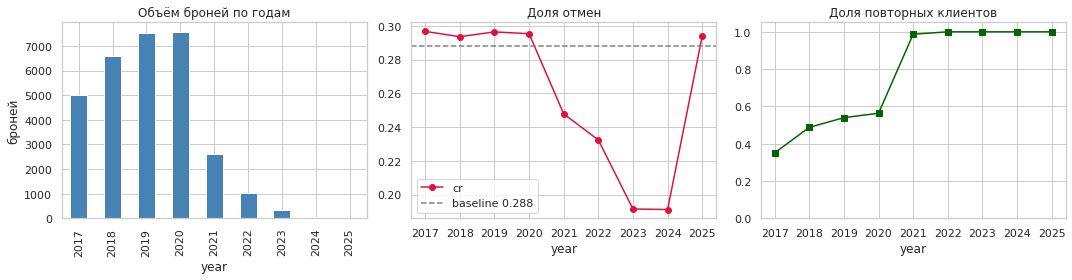

In [63]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

by_year.n.plot(kind='bar', ax=ax[0], color='steelblue')
ax[0].set_title('Объём броней по годам'); ax[0].set_ylabel('броней')

by_year.cr.plot(marker='o', ax=ax[1], color='crimson')
ax[1].axhline(BASELINE_CR, ls='--', c='gray', label=f'baseline {BASELINE_CR:.3f}')
ax[1].set_title('Доля отмен'); ax[1].legend()

by_year.ret.plot(marker='s', ax=ax[2], color='darkgreen')
ax[2].set_title('Доля повторных клиентов'); ax[2].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()

In [64]:
def split_mart_by_time(
    mart, target, baseline_cr,
    train_size=0.60, calib_size=0.20):
    
    d_tr = mart.booking_date.quantile(train_size)
    d_ca = mart.booking_date.quantile(train_size + calib_size)

    train = mart[mart.booking_date <  d_tr].copy()
    calib = mart[(mart.booking_date >= d_tr) & (mart.booking_date < d_ca)].copy()
    test  = mart[mart.booking_date >= d_ca].copy()

    rows = []
    for name, part in [('train', train), ('calib', calib), ('test', test)]:
        cr = part[target].mean()
        rows.append(dict(
            split=name, n=len(part), cr=round(cr, 4),
            delta_pp=round((cr - baseline_cr)*100, 2),
            ret=round(part.returning_customer.mean(), 3),
            rev=round(part.review_text.notna().mean(), 3),
            date_min=part.booking_date.min().date(),
            date_max=part.booking_date.max().date(),
        ))

    print(pd.DataFrame(rows).set_index('split').to_string())
    print(f'\nbaseline CR = {baseline_cr:.4f}')
    return train, calib, test

In [65]:
train, calib, test = split_mart_by_time(mart, TARGET, BASELINE_CR)

           n      cr  delta_pp    ret    rev    date_min    date_max
split                                                               
train  18425  0.2953      0.73  0.470  0.168  2017-01-01  2019-11-29
calib   6157  0.2980      1.01  0.559  0.263  2019-11-30  2020-09-19
test    6151  0.2561     -3.19  0.848  0.586  2020-09-20  2025-10-22

baseline CR = 0.2880


In [66]:
print(f'train {len(train):,} + calib {len(calib):,} + test {len(test):,} '
      f'= {len(train)+len(calib)+len(test):,}')
print(f'mart: {len(mart):,}')
assert len(train)+len(calib)+len(test) == len(mart)

# границы не пересекаются
assert train.booking_date.max() < calib.booking_date.min()
assert calib.booking_date.max() < test.booking_date.min()
print('✓ границы корректны')

train 18,425 + calib 6,157 + test 6,151 = 30,733
mart: 30,733
✓ границы корректны


✅ Выполнено разделение на обучающую, калибровачную и тестовую выборки. Есть умеренный дрейф CR: (0.2562−0.2954) / 0.2954 * 100 = -13.27% - максимальное значение дрейфа.

#### Векторизация текста

In [67]:
N_TOPICS = 8      # ← вместо 18, обоснование ниже


def clean_text(s: pd.Series) -> pd.Series:
    return (s.fillna('').str.lower()
             .str.replace('ё', 'е', regex=False)
             .str.replace(r'[^а-яa-z\s]', ' ', regex=True)
             .str.replace(r'\s+', ' ', regex=True)
             .str.strip())


train['text_clean'] = clean_text(train.review_text)

# ── ключевое: работаем только с непустыми текстами ────────────────────────
has_txt = train.text_clean != ''
texts = train.loc[has_txt, 'text_clean']
print(f'Непустых отзывов: {has_txt.sum():,} из {len(train):,} '
      f'({has_txt.mean():.1%})')

tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 1),
                        min_df=5, max_df=0.85,
                        stop_words=stopwords.words('russian'),
                        sublinear_tf=True)
X_tfidf = tfidf.fit_transform(texts)

svd = TruncatedSVD(n_components=N_TOPICS, random_state=42)
W = svd.fit_transform(X_tfidf)

print(f'TF-IDF: {X_tfidf.shape} → SVD: {W.shape}, '
      f'объяснено дисперсии: {svd.explained_variance_ratio_.sum():.1%}')

Непустых отзывов: 3,102 из 18,425 (16.8%)
TF-IDF: (3102, 346) → SVD: (3102, 8), объяснено дисперсии: 20.3%


In [68]:
# смотрим зависимость объясняемой дисперсии в зависимости от числа топиков
probe = TruncatedSVD(n_components=60, random_state=42).fit(X_tfidf)
# кумулятивная доля
cum = np.cumsum(probe.explained_variance_ratio_)
for k in (5, 8, 10, 15, 20, 30, 45, 60):
    if k <= len(cum):
        print(f'{k:>3} → {cum[k-1]:.1%}')

  5 → 15.5%
  8 → 20.3%
 10 → 23.2%
 15 → 29.0%
 20 → 34.2%
 30 → 43.9%
 45 → 56.3%
 60 → 66.4%


In [69]:
# смотрим, что получислось после сжатия по топикам
vocab = np.array(tfidf.get_feature_names_out())

for i, comp in enumerate(svd.components_):
    order = comp.argsort()
    neg = vocab[order[:8]]
    pos = vocab[order[-8:][::-1]]
    print(f'\n── Компонента {i} '
          f'(дисперсия {svd.explained_variance_ratio_[i]:.1%}) ──')
    print(f'  (+): {", ".join(pos)}')
    print(f'  (−): {", ".join(neg)}')


── Компонента 0 (дисперсия 1.4%) ──
  (+): отель, отличный, кондиционер, неплохо, зоны, игровой, дети, восторге
  (−): просто, приеду, место, хочется, премиум, превосходно, сюда, сомнений

── Компонента 1 (дисперсия 6.0%) ──
  (+): отель, отличный, дети, игровой, восторге, зоны, жары, спасал
  (−): холодно, второго, выпрашивать, одеяла, пришлось, номерах, неплохо, скучно

── Компонента 2 (дисперсия 3.9%) ──
  (+): номере, справлялся, тяжело, кондиционер, неплохо, детей, скучно, отсутствие
  (−): второго, пришлось, одеяла, выпрашивать, номерах, холодно, отель, восторге

── Компонента 3 (дисперсия 2.3%) ──
  (+): летом, жары, спасал, кондиционер, номерах, одеяла, пришлось, второго
  (−): зимой, отапливается, отель, номере, скучно, неплохо, детей, персонал

── Компонента 4 (дисперсия 1.9%) ──
  (+): зоны, восторге, дети, игровой, номере, справлялся, тяжело, комфортабельные
  (−): отель, зимой, отапливается, отличный, летом, жары, спасал, номера

── Компонента 5 (дисперсия 1.7%) ──
  (+):

✅ Выполнена векторизация текста на train: для каждого отзыва получен вектор n-грам, а затем они сжаты по темам, чтобы снизить число колонок.

👉 Добавить в пайплайн.

#### Промежуточный вывод
Число компонент выбрано равным 8 (20.3% объяснённой дисперсии). Кривая накопленной дисперсии не имеет выраженного перегиба. Это говорит об искуственном происхождении отзывов (генерации по шаблону). Будем применять агрегацию по сегментам room_type (7 уровней) и sales_channel (3 уровня), поэтому достаточно 8 топиков.

#### Замена текстовой колонки review_text на вектор

In [70]:
# ещё раз проверяем TARGET, где есть отзыв и где нет отзыва
mask = train.text_clean != ''

print(f'CR с отзывом:   {train.loc[mask, TARGET].mean():.4f}  (n={mask.sum():,})')
print(f'CR без отзыва:  {train.loc[~mask, TARGET].mean():.4f}  (n={(~mask).sum():,})')
print(f'CR общий:       {train[TARGET].mean():.4f}  (n={len(train):,})')

CR с отзывом:   0.0000  (n=3,102)
CR без отзыва:  0.3550  (n=15,323)
CR общий:       0.2953  (n=18,425)


❗Поскольку наличие отзывов является 100%-ым предиктором неотмены брони, то мы не можем использовать векторизованные отзывы примнительно к клиентам. Это ошибка создания данных. Метрики будут стопроцентными и мы получим переобучение модели. Чтобы этого избежать, но при этом не отбрасывать отзывы, применим их не к броням, а к сегментам.

In [71]:
train['text_clean'] = clean_text(train.review_text)
has_txt = train.text_clean != ''

texts = train.loc[has_txt, 'text_clean']
idx = texts.index                      # ← фиксируем индексы

X_tfidf = tfidf.fit_transform(texts)
W = svd.fit_transform(X_tfidf)

assert W.shape[0] == len(idx), f'{W.shape[0]} != {len(idx)}'

svd_cols = [f'svd_{i}' for i in range(N_TOPICS)]

rev = pd.concat([
    train.loc[idx, ['booking_id', 'stay_rating', 'room_type', 'sales_channel']],
    pd.DataFrame(W, columns=svd_cols, index=idx),   # ← тот же индекс
], axis=1)

assert len(rev) == has_txt.sum(), f'{len(rev)} != {has_txt.sum()}'
assert rev.isna().sum().sum() == 0, 'NaN в rev'
print(f'rev: {rev.shape}  ✓')

AGG = ['stay_rating'] + svd_cols
PRIOR = rev[AGG].mean()

print(f'AGG:   {len(AGG)} колонок')
print(f'PRIOR:\n{PRIOR.round(4).to_string()}')

rev: (3102, 12)  ✓
AGG:   9 колонок
PRIOR:
stay_rating    3.3785
svd_0          0.2420
svd_1         -0.0324
svd_2          0.0242
svd_3         -0.0147
svd_4         -0.0146
svd_5          0.0107
svd_6         -0.0007
svd_7         -0.0030


In [72]:
def fit_segment_stats(rev, by, w=20.0):
    """Сглаженные средние по сегменту. Считается только на train."""
    g = rev.groupby(by, observed=True)[AGG].agg(['mean', 'size'])
    out = pd.DataFrame(index=g.index)
    for c in AGG:
        m, n = g[(c, 'mean')], g[(c, 'size')]
        out[f'{by}_{c}'] = ((n * m + w * PRIOR[c]) / (n + w)).astype('float32')
    return out


def apply_segment_stats(part, stats, by):
    clash = set(part.columns) & set(stats.columns)
    if clash:
        raise ValueError(f'колонки уже есть: {sorted(clash)[:5]}')
    d = part.merge(stats, left_on=by, right_index=True, how='left')
    for c in stats.columns:
        d[c] = d[c].fillna(PRIOR[c.replace(f'{by}_', '')]).astype('float32')
    return d

In [73]:
SEGMENTS = ['room_type', 'sales_channel']
SEG_STATS = {}
n_before = len(train)

for by in SEGMENTS:
    st = fit_segment_stats(rev, by)
    SEG_STATS[by] = st
    train = apply_segment_stats(train, st, by)
    print(f'{by}: {len(st)} сегментов, +{len(st.columns)} колонок')

assert len(train) == n_before, f'merge изменил строки: {n_before} → {len(train)}'

seg = [c for c in train.columns if c.startswith(('room_type_', 'sales_channel_'))]
print(f'\nсегментных колонок: {len(seg)}  (ожидается 18)')
print(f'train: {train.shape}  ✓')

room_type: 7 сегментов, +9 колонок
sales_channel: 3 сегментов, +9 колонок

сегментных колонок: 18  (ожидается 18)
train: (18425, 41)  ✓


In [74]:
train.columns

Index(['booking_id', 'booking_date', 'sales_channel', 'adult_count',
       'child_count', 'returning_customer', 'previous_cancellations',
       'previous_no_shows', 'booking_status', 'booking_value',
       'days_until_checkin', 'weekday_nights', 'weekend_nights', 'meal_plan',
       'parking_included', 'room_type', 'customer_special_requests',
       'customer_id', 'has_customer_id', 'review_date', 'stay_rating',
       'review_text', 'text_clean', 'room_type_stay_rating', 'room_type_svd_0',
       'room_type_svd_1', 'room_type_svd_2', 'room_type_svd_3',
       'room_type_svd_4', 'room_type_svd_5', 'room_type_svd_6',
       'room_type_svd_7', 'sales_channel_stay_rating', 'sales_channel_svd_0',
       'sales_channel_svd_1', 'sales_channel_svd_2', 'sales_channel_svd_3',
       'sales_channel_svd_4', 'sales_channel_svd_5', 'sales_channel_svd_6',
       'sales_channel_svd_7'],
      dtype='object')

✅ Получили векторизованные отзывы, агрегированные по двум сегментам: room_type и sales_channel.

👉 Добавить в пайплайн.

#### Добавление инженерных фич

In [75]:
HIGH_SEASON = {6, 7, 8, 12}


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Инженерные признаки. NaN распространяются намеренно:
    CatBoost и LightGBM обрабатывают их нативно.
    """
    d = df.copy()

    # --- 1. Сезонность ----------------------------------------------------
    d['checkin_date']   = d.booking_date + pd.to_timedelta(d.days_until_checkin, 'D')
    d['checkin_month']  = d.checkin_date.dt.month.astype('int8')
    d['is_high_season'] = d.checkin_month.isin(HIGH_SEASON).astype('int8')

    # --- 2. Горизонт бронирования ----------------------------------------
    # lead_time_log удалён: log — монотонное преобразование,
    # деревья к нему инвариантны, признак дублирует days_until_checkin
    d['is_last_minute'] = (d.days_until_checkin <= 7).astype('int8')

    # --- 3. Структура проживания ------------------------------------------
    d['total_nights'] = (d.weekday_nights + d.weekend_nights).astype('int16')
    d['total_guests'] = (d.adult_count + d.child_count).astype('float32')  # NaN ok
    d['has_children'] = (d.child_count > 0).astype('int8')

    # --- 4. Цена ----------------------------------------------------------
    # np.where вместо clip: при нулевом знаменателе — NaN, а не полная стоимость
    d['price_per_night'] = np.where(
        d.total_nights > 0,
        d.booking_value / d.total_nights,
        np.nan).astype('float32')

    d['price_per_guest'] = np.where(
        d.total_guests > 0,
        d.booking_value / d.total_guests,
        np.nan).astype('float32')

    # --- 5. Лояльность ----------------------------------------------------
    pc, pn = d.previous_cancellations, d.previous_no_shows
    d['prev_cancel_rate'] = ((pc + 1) / (pc + pn + 2)).astype('float32')
    d['has_prev_cancel']  = (pc > 0).astype('int8')

    # --- 6. Вовлечённость -------------------------------------------------
    # engagement удалён: смешивает несопоставимые шкалы (счётчик + флаг),
    # деревья находят комбинации самостоятельно
    d['has_requests'] = (d.customer_special_requests > 0).astype('int8')

    return d

In [76]:
train_fe = build_features(train)
print(f'Новых признаков: {len([c for c in train_fe.columns if c not in train.columns])}')

Новых признаков: 12


In [77]:
CAT_FEATURES = ['room_type', 'sales_channel', 'meal_plan']

BIN_FEATURES = ['returning_customer', 'parking_included', 'has_customer_id',
                'is_high_season', 'is_last_minute', 'has_children',
                'has_prev_cancel', 'has_requests']

NUM_FEATURES = ['adult_count', 'child_count', 'booking_value',
                'days_until_checkin', 'weekday_nights', 'weekend_nights',
                'previous_cancellations', 'previous_no_shows',
                'customer_special_requests', 'checkin_month',
                'total_nights', 'total_guests',
                'price_per_night', 'price_per_guest', 'prev_cancel_rate']

FEATURES = CAT_FEATURES + BIN_FEATURES + NUM_FEATURES

DROP = ['booking_id', 'customer_id', 'booking_date', 'checkin_date', TARGET]

print(f'признаков: {len(FEATURES)}  '
      f'(cat={len(CAT_FEATURES)}, bin={len(BIN_FEATURES)}, num={len(NUM_FEATURES)})')

missing = [c for c in FEATURES if c not in train_fe.columns]
print(f'отсутствуют в train_fe: {missing or "нет"}')

признаков: 26  (cat=3, bin=8, num=15)
отсутствуют в train_fe: нет


| Группа | Признаки | Гипотеза |
|--------|----------|----------|
| Сезонность | `checkin_month`, `is_high_season` | Доля отмен зависит от сезона заезда; высокий сезон — июнь–август, декабрь |
| Горизонт | `days_until_checkin`, `is_last_minute` | Дальний горизонт даёт больше времени изменить планы; при горизонте ≤ 7 дней отмена малоосмысленна. Связь может быть немонотонной |
| Структура проживания | `total_nights`, `total_guests`, `has_children` | Длительные и семейные поездки планируются обдуманнее и отменяются реже |
| Цена | `price_per_night`, `price_per_guest` | Нормировка стоимости на объём брони; высокая удельная цена повышает цену отказа |
| История клиента | `prev_cancel_rate`, `has_prev_cancel` | Доля отмен в истории со сглаживанием Лапласа; разделяет отмену (уведомил) и неявку (не уведомил) |
| Вовлечённость | `has_requests` | Наличие спецзапросов как индикатор проработанности брони; направление связи определяется эмпирически |

✅ Получили векторизованные отзывы, агрегированные по двум сегментам: room_type и sales_channel.

👉 Добавить в пайплайн.

In [78]:
info = train[seg].nunique().sort_values()
print(info.to_string())

print(f'\nконстант (nunique≤1): {(info <= 1).sum()}')
print('ожидается: room_type_* → 7, sales_channel_* → 3')

sales_channel_svd_2          3
sales_channel_svd_5          3
sales_channel_svd_3          3
sales_channel_svd_4          3
sales_channel_svd_0          3
sales_channel_svd_1          3
sales_channel_stay_rating    3
sales_channel_svd_6          3
sales_channel_svd_7          3
room_type_svd_5              7
room_type_svd_6              7
room_type_svd_3              7
room_type_svd_2              7
room_type_svd_1              7
room_type_svd_4              7
room_type_stay_rating        7
room_type_svd_7              7
room_type_svd_0              7

констант (nunique≤1): 0
ожидается: room_type_* → 7, sales_channel_* → 3


Сегментные признаки информативны: не выродились при сглаживании.

In [79]:
for by in SEGMENTS:
    g = (rev.groupby(by, observed=True)
            .agg(n=('stay_rating', 'size'), rating=('stay_rating', 'mean'))
            .sort_values('rating'))
    print(f'\n── {by} ──')
    print(g.round(3).to_string())
    if (g.n < 20).sum():
        print(f'  ⚠ {(g.n < 20).sum()} сегм. с n<20 → сильное сглаживание к prior')


── room_type ──
              n  rating
room_type              
тип_6        76   3.263
тип_2        76   3.316
тип_5        22   3.318
тип_7        17   3.353
тип_4       506   3.356
тип_1      2403   3.390
тип_3         2   3.500
  ⚠ 2 сегм. с n<20 → сильное сглаживание к prior

── sales_channel ──
                               n  rating
sales_channel                           
онлайн_бронирование          775   3.375
офлайн_бронирование         1067   3.377
корпоративное_бронирование  1260   3.382


👉 Но сегменты не информативны: размахи рейтингов по группам 0.237 и 0.007. Это шум. Будем иметь в виду в финальном EDA.

### Анализ итоговой таблицы

- Проанализируйте итоговую таблицу.

- Сделайте выводы о данных для моделирования.

#### Выбор моделей
Ранний выбор моделей позволит оптимизировать финнальный EDA.

Будем обучать **CatBoost и LightGBM**, так как это разные алгоритмы построения деревьев. CatBoost хорошо работает с категориями и не требует OHE и других методов кодирования, устойчив на дрейфе. LightGBM имеет leaf-wise архитектуру против симметричной архитектуры CatBoost. 

#### Цели и методы
**Сейчас нужно понять:**
- какие признаки константные или квази-константные — не несут информации и их можно сразу удалить без глубокого анализа;


- какие признаки — шум, то есть не связаны с TARGET (отменой брони). Отдельно отличаем «слабый, но статистически значимый сигнал». Критерий: IV < 0.02 и p-value χ² > 0.05 → шум. Если IV мал, но p значим — оставляем до ablation-теста;


- какие признаки дают утечку из будущего. В данных есть утечка по конструкции (наличие отзыва ⇒ CR = 0). Ищем IV > 0.5, одиночный AUC > 0.9, бины с CR = 0.000 или 1.000; 


- какова форма связи с TARGET — монотонная или нет. От этого зависит, допустимы ли **monotone_constraints** в бустингах, которые делают модель боле осторожной. Монотонные ограничения на days_until_checkin и prev_cancel_rate снижают переобучение и стабилизируют предсказания на дрейфующем test — а у нас требование разница RIR между Train и Test ≤ 10%;


- есть ли взаимодействия между признаками — то есть добавляет ли пара признаков дисперсию сверх суммы их одиночных вкладов. Определяет depth для CatBoost и num_leaves для LightGBM;


- подобрать кодирование признаков, чтобы дерево правильно строило порог. С выбранными моделями необходимость кодирования минимальна. Не в пример линейным моделям;


- стабильность распределения признаков на train и test: PSI по каждому признаку. Признак с PSI > 0.25 — кандидат на исключение, даже если IV высокий: он «сломается» на проде;


- достижимый потолок PR-AUC и RIR. Baseline PR-AUC = доля позитивного класса ≈ 0.288. Потолок RIR считается из экономики при идеальном классификаторе. Нужно понять, реалистично ли требование RIR ≥ 50%;


- дублирующиеся признаки: |ρ_Spearman| > 0.95 между парами.

**Не рассматриваем:**
- выбросы в признаках: cплиты строятся по порядковым статистикам — экстремальные значения не меняют структуру дерева. Проверяем только невозможные значения (отрицательная цена, нулевое число гостей) как индикатор ошибок в данных;
- перекос распределения (skew): монотонное преобразование не меняет порядок → не меняет сплит;
- масштабирование и логарифмирование: деревья не используют градиентный спуск по признакам и метрики расстояния;
- импутация пропусков: у нас нет пропусков, кроме того, выбранные модели умеют с ними работать;
- OHE - модели нативно работают с category;
- VIF - мультиколлениарность не искажает деревья, влияет только на распределение важности между признаками;
- SMOTE, oversampling - дисбаланс 2.47 : 1 — умеренный. Достаточно scale_pos_weight / class_weights.

**Призаки для доп анализа из предварительного EDA:** adult_count, days_until_checkin, weekday_nights. booking_value.

**В нашей задаче анализ сводится к вопросам:**
- какие признаки передавать модели как категориальные;
- checkin_month и подобные - категория либо циклическое кодирование;
- нужны ли сегментные колонки, полученные из отзывов через SVD.

**Методы**

| # | Что измеряем | Метод | Порог |
|---|--------------|-------|-------|
| 1 | Информативность | `nunique`, доля моды | мода > 99% → константа |
| 2 | Разделяющая сила, числовые | IV (Information Value) | < 0.02 — нет · 0.02–0.1 — слабый · 0.1–0.3 — средний · 0.3–0.5 — сильный · > 0.5 — ⚠ утечка |
| 3 | Разделяющая сила, категориальные | Cramér's V | < 0.1 — слабая · 0.1–0.3 — средняя · > 0.3 — сильная |
| 4 | Значимость связи | p-value χ² | > 0.05 → шум, а не слабый сигнал |
| 5 | Утечка | одиночный ROC-AUC по признаку + таблица CR по бинам | AUC > 0.9 или бин с CR ∈ {0, 1} |
| 6 | Форма связи | Spearman (номер бина ↔ CR в бине) | \|ρ\| > 0.9 → монотонный, кандидат на constraint |
| 7 | Стабильность | PSI train↔test | < 0.1 — стабилен · 0.1–0.25 — умеренный · > 0.25 — нестабилен |
| 8 | Вклад в дисперсию | permutation importance на контрольном LGBM | вклад ≈ 0 → кандидат на удаление |
| 9 | Взаимодействия | прирост CV-AUC от пары сверх суммы одиночных вкладов | прирост > std CV → нужна глубина ≥ 4 |
| 10 | Дубли | матрица Spearman, для категорий Cramér's V | \|ρ\| > 0.95 → удалить один из пары |
| 11 | Потолок метрик | PR-AUC baseline, RIR при идеальном классификаторе | сравнить с требованием RIR ≥ 50% |

В нашей задаче бинарная классификация, поэтому, используем  IV (сила) и χ² p-value (значимость). Для регрессии нужно было бы использовать eta² и ANOVA.

#### Целевая переменная

In [80]:
dist = (train_fe[TARGET].value_counts().sort_index()
          .rename(index={0: 'бронь состоялась', 1: 'бронь отменена'})
          .to_frame('count'))
dist['%'] = (dist['count'] / len(mart) * 100).round(2)

N_TOTAL   = len(train_fe)
N_CANCEL  = int(train_fe[TARGET].sum())
N_SUCCESS = N_TOTAL - N_CANCEL
CR_TRAIN  = N_CANCEL / N_TOTAL
IMBALANCE = N_SUCCESS / N_CANCEL

dist = (train_fe[TARGET].value_counts().sort_index()
          .rename(index={0: 'бронь состоялась', 1: 'бронь отменена'})
          .to_frame('count'))
dist['%'] = (dist['count'] / N_TOTAL * 100).round(2)

print(dist.to_string())
print(f'\nвсего броней:     {N_TOTAL:,}')
print(f'CR (train):       {CR_TRAIN:.4f}')
print(f'дисбаланс:        {IMBALANCE:.2f} : 1')
print(f'scale_pos_weight: {IMBALANCE:.3f}')
print(f'PR-AUC baseline:  {CR_TRAIN:.4f}  (случайный классификатор)')

                  count      %
booking_status                
бронь состоялась  12985  70.47
бронь отменена     5440  29.53

всего броней:     18,425
CR (train):       0.2953
дисбаланс:        2.39 : 1
scale_pos_weight: 2.387
PR-AUC baseline:  0.2953  (случайный классификатор)


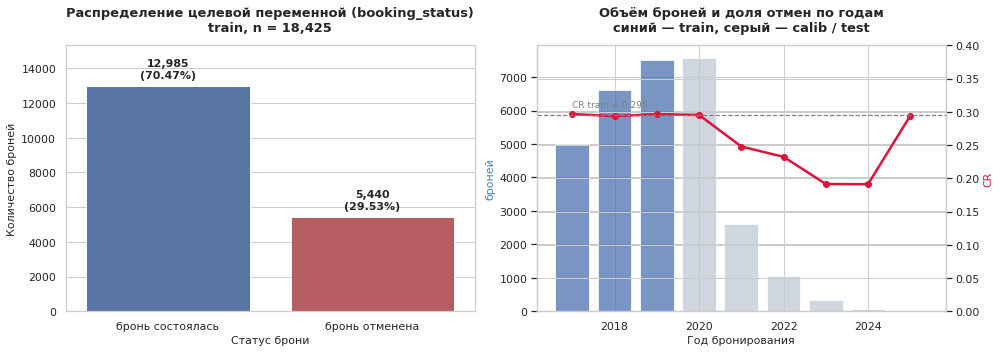

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- баланс классов (train_fe) ---
sns.barplot(x=dist.index, y=dist['count'], hue=dist.index,
            palette=['#4c72b0', '#c44e52'], legend=False, ax=ax[0])
ax[0].set_title(f'Распределение целевой переменной ({TARGET})\ntrain, n = {N_TOTAL:,}',
                fontsize=13, fontweight='bold', pad=14)
ax[0].set_xlabel('Статус брони', fontsize=11)
ax[0].set_ylabel('Количество броней', fontsize=11)
for i, (_, r) in enumerate(dist.iterrows()):
    ax[0].annotate(f"{int(r['count']):,}\n({r['%']}%)",
                   xy=(i, r['count']), xytext=(0, 8),
                   textcoords='offset points', ha='center',
                   fontsize=11, fontweight='bold')
ax[0].set_ylim(0, dist['count'].max() * 1.18)

# --- динамика по годам: train сплошной, calib/test пунктиром ---
by_y = (mart.assign(y=mart.booking_date.dt.year)
            .groupby('y')[TARGET].agg(['mean', 'size']))
tr_years = set(train.booking_date.dt.year.unique())
colors = ['#4c72b0' if y in tr_years else '#bfc9d4' for y in by_y.index]

ax[1].bar(by_y.index, by_y['size'], color=colors, alpha=.75)
ax[1].set_ylabel('броней', color='steelblue', fontsize=11)
ax[1].set_xlabel('Год бронирования', fontsize=11)

ax2 = ax[1].twinx()
ax2.plot(by_y.index, by_y['mean'], marker='o', color='crimson', lw=2.5)
ax2.axhline(CR_TRAIN, ls='--', c='gray', lw=1.2)
ax2.text(by_y.index.min(), CR_TRAIN + .012, f'CR train = {CR_TRAIN:.3f}',
         fontsize=9, color='gray')
ax2.set_ylabel('CR', color='crimson', fontsize=11)
ax2.set_ylim(0, .40)

ax[1].set_title('Объём броней и доля отмен по годам\n'
                'синий — train, серый — calib / test',
                fontsize=13, fontweight='bold', pad=14)

plt.tight_layout(); plt.show()

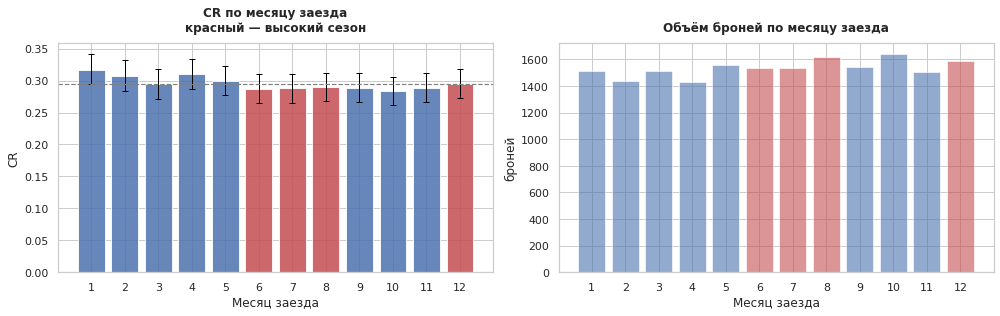

 checkin_month    n     cr  high_season
             1 1513 0.3173        False
             2 1438 0.3074        False
             3 1514 0.2939        False
             4 1434 0.3096        False
             5 1561 0.2992        False
             6 1534 0.2868         True
             7 1533 0.2877         True
             8 1621 0.2893         True
             9 1543 0.2884        False
            10 1639 0.2831        False
            11 1507 0.2887        False
            12 1588 0.2947         True

высокий сезон: CR=0.2897 (n=6,276)
низкий сезон:  CR=0.2981 (n=12,149)
разница:       -0.85 п.п.


In [82]:
mo = (train_fe.groupby('checkin_month')[TARGET]
        .agg(n='size', cr='mean').reset_index())
mo['lo'], mo['hi'] = proportion_confint(
    (mo.cr * mo.n).round(), mo.n, alpha=.05, method='wilson')
mo['high_season'] = mo.checkin_month.isin(HIGH_SEASON)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

ax[0].bar(mo.checkin_month, mo.cr,
          color=np.where(mo.high_season, '#c44e52', '#4c72b0'), alpha=.85)
ax[0].errorbar(mo.checkin_month, mo.cr,
               yerr=[mo.cr - mo.lo, mo.hi - mo.cr],
               fmt='none', ecolor='black', capsize=3, lw=1)
ax[0].axhline(CR_TRAIN, ls='--', c='gray', lw=1.2)
ax[0].set_title('CR по месяцу заезда\nкрасный — высокий сезон',
                fontsize=12, fontweight='bold', pad=12)
ax[0].set_xlabel('Месяц заезда'); ax[0].set_ylabel('CR')
ax[0].set_xticks(range(1, 13))

ax[1].bar(mo.checkin_month, mo.n,
          color=np.where(mo.high_season, '#c44e52', '#4c72b0'), alpha=.6)
ax[1].set_title('Объём броней по месяцу заезда', fontsize=12,
                fontweight='bold', pad=12)
ax[1].set_xlabel('Месяц заезда'); ax[1].set_ylabel('броней')
ax[1].set_xticks(range(1, 13))

plt.tight_layout(); plt.show()

print(mo[['checkin_month', 'n', 'cr', 'high_season']].round(4).to_string(index=False))

hs = train_fe.groupby('is_high_season')[TARGET].agg(n='size', cr='mean')
print(f'\nвысокий сезон: CR={hs.loc[1, "cr"]:.4f} (n={hs.loc[1, "n"]:,})')
print(f'низкий сезон:  CR={hs.loc[0, "cr"]:.4f} (n={hs.loc[0, "n"]:,})')
print(f'разница:       {(hs.loc[1, "cr"] - hs.loc[0, "cr"])*100:+.2f} п.п.')

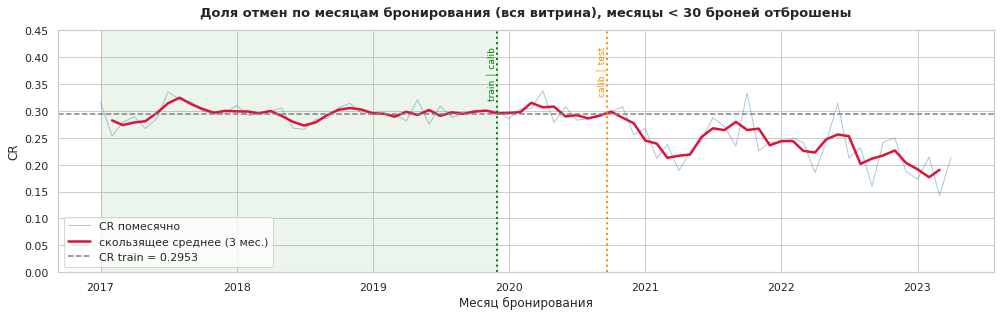

по всей витрине: CR min=0.1429  max=0.3377  std=0.0426  размах=0.1948


In [83]:
m = (mart.set_index('booking_date').resample('MS')[TARGET]
         .agg(cr='mean', n='size'))
m = m[m.n >= 30]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(m.index, m.cr, lw=1, alpha=.45, color='steelblue', label='CR помесячно')
ax.plot(m.index, m.cr.rolling(3, center=True).mean(), lw=2.5,
        color='crimson', label='скользящее среднее (3 мес.)')
ax.axhline(CR_TRAIN, ls='--', c='gray', label=f'CR train = {CR_TRAIN:.4f}')

ax.axvspan(train.booking_date.min(), train.booking_date.max(),
           alpha=.08, color='green')
for d, lbl, c in [(train.booking_date.max(), 'train │ calib', 'green'),
                  (calib.booking_date.max(), 'calib │ test', 'darkorange')]:
    ax.axvline(d, ls=':', c=c, lw=2)
    ax.text(d, .42, lbl, rotation=90, fontsize=9, color=c, va='top', ha='right')

ax.set_title('Доля отмен по месяцам бронирования (вся витрина), месяцы < 30 броней отброшены',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylabel('CR'); ax.set_xlabel('Месяц бронирования')
ax.set_ylim(0, .45); ax.legend(loc='lower left')
plt.tight_layout(); plt.show()

print(f'по всей витрине: CR min={m.cr.min():.4f}  max={m.cr.max():.4f}  '
      f'std={m.cr.std():.4f}  размах={m.cr.max()-m.cr.min():.4f}')

#### Промежуточный вывод
**Баланс классов**

В обучающей выборке 18 425 броней, из них 5 440 отменённых — доля отмен 0.2953. Соотношение классов 2.39 : 1 является умеренным: методы синтетической генерации (SMOTE) не требуются, достаточно взвешивания через scale_pos_weight = 2.387. Базовый уровень PR-AUC для случайного классификатора равен доле позитивного класса — 0.2953, это нижняя граница для оценки качества модели.

**Сезонность не подтверждена** 

Разброс CR по месяцам заезда укладывается в диапазон 0.2831–0.3173 при размахе 3.4 п.п. Доверительные интервалы всех двенадцати месяцев перекрываются между собой и пересекают базовую линию — ни один месяц не отличается статистически значимо. Агрегированный признак is_high_season даёт разницу −0.85 п.п. (0.2897 против 0.2981), причём знак противоположен исходной гипотезе: в высокий сезон отменяют не чаще, а незначительно реже. Объёмы броней по месяцам также равномерны (1 434–1 639), выраженного пика спроса нет.

Признаки checkin_month и is_high_season переводятся в статус кандидатов на удаление, несмотря на прямое требование ТЗ учитывать сезонность. Окончательное решение — по результатам ablation-теста.

**Структурный сдвиг в данных** 

Помесячная динамика по всей витрине показывает два режима. До начала 2020 года CR колеблется вокруг 0.30 со стабильной амплитудой. С 2020 года начинается устойчивое снижение до уровня 0.18–0.22, минимум достигает 0.1429. Общий размах по витрине — 0.1948 при стандартном отклонении 0.0426.

Одновременно падает объём: пик приходится на 2020 год, после чего число броней сокращается многократно, а в 2024–2025 годах данные практически отсутствуют. Совпадение по времени указывает на пандемийный шок и последующее изменение структуры спроса.

**Особенности датасета и риски**

Снижение общей доли отмен с 0.30 до 0.21 не противоречит постановке задачи. Целевая переменная фиксирует факт отмены без указания её срока, тогда как бизнес-проблема касается отмен за 48 часов и менее. Данные не содержат даты отмены, что делает невозможным прямое выделение поздних отмен. Модель обучается на общей отмене. Это ограничение фиксируется как допущение и должно учитываться при интерпретации бизнес-метрик.

Разделение train / calib / test выполнено по времени, и границы приходятся ровно на зону перелома: обучающая выборка целиком лежит в стабильном докризисном режиме (CR ≈ 0.295), тогда как тестовая — в режиме сниженных отмен. Модель обучается на распределении, которое на тесте не воспроизводится.

#### Декомпозиция дрейфа CR на состав и поведение

In [84]:
test_fe = build_features(test)


def decompose_cr(a: pd.DataFrame, b: pd.DataFrame, by: str) -> dict:
    """
    Раскладывает изменение CR между выборками на два эффекта.

    состав     — сдвиг из-за изменения долей сегментов при неизменном
                 поведении внутри каждого сегмента;
    поведение  — сдвиг из-за изменения CR внутри сегментов при неизменных
                 долях.

    Модель компенсирует первое (признак есть в данных) и не компенсирует
    второе (причина вне признакового пространства).
    """
    pa = a.groupby(by, observed=True)[TARGET].mean()
    wa = a[by].value_counts(normalize=True)
    pb = b.groupby(by, observed=True)[TARGET].mean()
    wb = b[by].value_counts(normalize=True)

    ix = pa.index.union(pb.index)
    pa, wa = pa.reindex(ix).fillna(0), wa.reindex(ix).fillna(0)
    pb, wb = pb.reindex(ix).fillna(0), wb.reindex(ix).fillna(0)

    cr_a, cr_b = (wa * pa).sum(), (wb * pb).sum()
    mix = (wb * pa).sum()          # доли test, поведение train

    comp, beh = (mix - cr_a) * 100, (cr_b - mix) * 100
    total = comp + beh

    return dict(признак=by,
                cr_train=round(cr_a, 4), cr_test=round(cr_b, 4),
                дельта_пп=round(total, 2),
                состав_пп=round(comp, 2), поведение_пп=round(beh, 2),
                доля_состава=f'{abs(comp)/abs(total)*100:.0f}%'
                             if abs(total) > 1e-9 else '—')


SEG_COLS = ['room_type', 'sales_channel', 'meal_plan',
            'returning_customer', 'is_high_season',
            'has_prev_cancel', 'is_last_minute', 'has_children']

dec = pd.DataFrame([decompose_cr(train_fe, test_fe, c)
                    for c in SEG_COLS if c in train_fe.columns])
print(dec.to_string(index=False))

           признак  cr_train  cr_test  дельта_пп  состав_пп  поведение_пп доля_состава
         room_type    0.2953   0.2561      -3.92       0.00         -3.92           0%
     sales_channel    0.2953   0.2561      -3.92      -1.42         -2.50          36%
         meal_plan    0.2953   0.2561      -3.92      -0.01         -3.91           0%
returning_customer    0.2953   0.2561      -3.92       0.13         -4.05           3%
    is_high_season    0.2953   0.2561      -3.92       0.03         -3.95           1%
   has_prev_cancel    0.2953   0.2561      -3.92       0.27         -4.19           7%
    is_last_minute    0.2953   0.2561      -3.92       0.05         -3.97           1%
      has_children    0.2953   0.2561      -3.92      -0.32         -3.60           8%


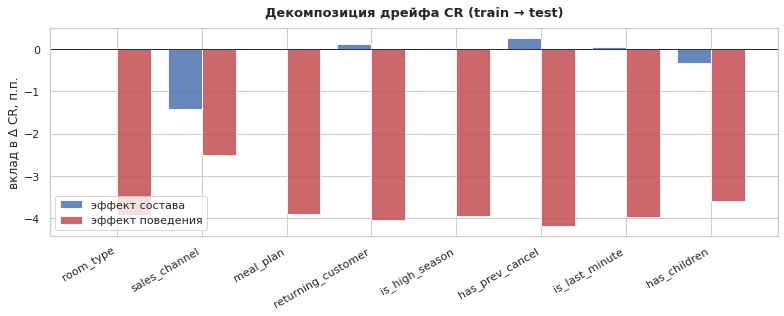

In [85]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(dec))
ax.bar(x - .2, dec.состав_пп, .4, label='эффект состава',
       color='#4c72b0', alpha=.85)
ax.bar(x + .2, dec.поведение_пп, .4, label='эффект поведения',
       color='#c44e52', alpha=.85)
ax.axhline(0, c='black', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(dec.признак, rotation=30, ha='right')
ax.set_ylabel('вклад в Δ CR, п.п.')
ax.set_title('Декомпозиция дрейфа CR (train → test)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend()
plt.tight_layout(); plt.show()

#### Оценка достижимых метрик и вычисление бизнес-метрик

In [86]:
AVG_REV    = 64_500
LOST_REV   = 64_500
COST_FP    =  7_000
PER_REBOOK = 45_000
CR_TARGET  = 0.10


def compute_ir(y_true, y_pred) -> float:
    """IR после внедрения модели."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    return tp * PER_REBOOK + tn * AVG_REV - fp * COST_FP - fn * LOST_REV


def ir_before(y_true) -> float:
    """IR до внедрения: все брони идут как есть."""
    y_true = np.asarray(y_true)
    n_cancel = int(y_true.sum())
    return (len(y_true) - n_cancel) * AVG_REV - n_cancel * LOST_REV


def business_metrics(y_true, y_pred) -> dict:
    """CR, OR, IR, RIR — полный набор бизнес-метрик."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    n = len(y_true)
    n_cancel = int(y_true.sum()); n_success = n - n_cancel

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    ir_b, ir_a = ir_before(y_true), compute_ir(y_true, y_pred)
    cr_b, cr_a = n_cancel / n, fn / n
    or_b, or_a = n_success / n, (n_success - fp + tp) / n

    return dict(
        TP=tp, FP=fp, FN=fn,
        CR_before=round(cr_b, 4), CR_after=round(cr_a, 4),
        CR_dyn=round((cr_b - cr_a) / cr_b * 100, 1),
        OR_before=round(or_b, 4), OR_after=round(or_a, 4),
        OR_dyn=round((or_a - or_b) / or_b * 100, 1),
        IR=int(ir_a - ir_b),
        RIR=round((ir_a - ir_b) / abs(ir_b) * 100, 1),
    )

In [87]:
y_tr = train_fe[TARGET].values

IR_BEFORE  = ir_before(y_tr)
IR_PERFECT = compute_ir(y_tr, y_tr)
RIR_CEIL   = (IR_PERFECT - IR_BEFORE) / abs(IR_BEFORE) * 100

print(f'IR до внедрения:         {IR_BEFORE:>18,.0f} ₽')
print(f'IR при идеальной модели: {IR_PERFECT:>18,.0f} ₽')
print(f'RIR потолок:             {RIR_CEIL:>17.1f} %')
print(f'требование ТЗ:           {"≥ 50 %":>18}')
print(f'запас:                   {RIR_CEIL / 50:>17.1f}×')

MIN_RECALL = 1 - CR_TARGET / CR_TRAIN
print(f'\nMIN_RECALL для CR ≤ {CR_TARGET:.0%}:  {MIN_RECALL:.4f}')

THR_THEORY = (AVG_REV + COST_FP) / (PER_REBOOK + LOST_REV + AVG_REV + COST_FP)
print(f'теоретический порог:        {THR_THEORY:.4f}')

IR до внедрения:                486,652,500 ₽
IR при идеальной модели:      1,082,332,500 ₽
RIR потолок:                         122.4 %
требование ТЗ:                       ≥ 50 %
запас:                                 2.4×

MIN_RECALL для CR ≤ 10%:  0.6613
теоретический порог:        0.3950


#### Промежуточный вывод
Дрейф CR между train и test происходит из-за изменения поведения клиентов, во время и после Ковид (2020 год и далее), а не из-за изменения состава клиентов. Более того, в test увеличивается доля постоянных клиентов. CR на test падает на 3.92 процента. Декомпозиция по 8 сегментам показала преобладание эффекта поведения. Доли сегментов на train и test почти совпадают, но изменилось поведение: склонность к отмене брони снизилась. Исключение sales_channel. 36% сдвига - это перераспределение каналов продаж. Но и тут поведенческая компонента преобладает. 

В плане достижимости поставленных клиентом значений метрик есть теоретический запас в 2.4 раза. Модель должна реализовать около 40% теоритического максимума. Минимальный Recall, чтобы получить CR ≤ 10%, составляет 0.6613.

#### Сравниваем показатели признаков

In [88]:
def _as_groups(s: pd.Series, bins: int = 10) -> pd.Series:
    """
    Приводит признак к строковым группам для таблиц сопряжённости.
    Категориальные и малокардинальные — как есть, числовые — по квантилям.
    NaN становится отдельной группой '__NaN__'.
    """
    if s.dtype.name in ('category', 'object') or s.nunique(dropna=True) <= bins:
        g = s.astype('object')
    else:
        g = pd.qcut(s, bins, duplicates='drop').astype('object')
    return g.where(g.notna(), '__NaN__')


def compute_iv(s: pd.Series, y: pd.Series, bins: int = 10) -> float:
    """
    Information Value — разделяющая сила признака.
    <0.02 нет | 0.02-0.1 слабый | 0.1-0.3 средний | 0.3-0.5 сильный
    | >0.5 подозрение на утечку.
    """
    g = _as_groups(s, bins)
    t = (pd.DataFrame({'g': g, 'y': y})
           .groupby('g', observed=True)['y'].agg(['sum', 'count']))
    bad  = t['sum'].clip(lower=.5) / y.sum()
    good = (t['count'] - t['sum']).clip(lower=.5) / (len(y) - y.sum())
    return float(((bad - good) * np.log(bad / good)).sum())


def compute_psi(base: pd.Series, cur: pd.Series, bins: int = 10) -> float:
    """PSI. <0.1 стабилен | 0.1-0.25 умеренный дрейф | >0.25 нестабилен."""
    if base.dtype.name in ('category', 'object'):
        b = base.astype('object').value_counts(normalize=True)
        c = (cur.astype('object').value_counts(normalize=True)
                .reindex(b.index).fillna(0))
    else:
        e = np.unique(np.nanquantile(base.dropna(), np.linspace(0, 1, bins + 1)))
        if len(e) < 3:
            return 0.0
        b = pd.Series(np.histogram(base.dropna(), bins=e)[0]
                      / max(base.notna().sum(), 1))
        c = pd.Series(np.histogram(cur.dropna(), bins=e)[0]
                      / max(cur.notna().sum(), 1))
    b, c = b.clip(1e-6), c.clip(1e-6)
    return float(((c - b) * np.log(c / b)).sum())

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Сила связи категориального признака с бинарным таргетом. 0 = нет связи."""
    t = pd.crosstab(_as_groups(x), y)
    if t.shape[0] < 2 or t.shape[1] < 2:
        return 0.0
    chi2 = chi2_contingency(t)[0]
    return float(np.sqrt(chi2 / (t.to_numpy().sum() * (min(t.shape) - 1))))


def chi2_pvalue(s: pd.Series, y: pd.Series, bins: int = 10) -> float:
    """Значимость связи — отделяет слабый сигнал от шума."""
    t = pd.crosstab(_as_groups(s, bins), y)
    if t.shape[0] < 2 or t.shape[1] < 2:
        return 1.0
    return float(chi2_contingency(t)[1])


def monotone_spearman(s: pd.Series, y: pd.Series, bins: int = 10) -> float:
    """Spearman между номером квантильного бина и CR внутри бина.
       |rho| > 0.9 → кандидат на monotone_constraint."""
    if s.nunique(dropna=True) <= 2:
        return np.nan
    try:
        g = pd.qcut(s, bins, duplicates='drop', labels=False)
    except Exception:
        return np.nan
    cr = pd.DataFrame({'g': g, 'y': y}).dropna().groupby('g')['y'].mean()
    if len(cr) < 3:
        return np.nan
    return float(cr.index.to_series().corr(cr, method='spearman'))

In [89]:
def single_auc(s: pd.Series, y: pd.Series) -> float:
    """ROC-AUC по одному признаку. >0.9 → сильное подозрение на утечку."""    

    if not pd.api.types.is_numeric_dtype(s):
        g = _as_groups(s)
        enc = pd.DataFrame({'g': g, 'y': y}).groupby('g', observed=True)['y'].mean()
        v = g.map(enc).astype('float64')
    else:
        v = s.astype('float64')

    m = v.notna()
    if m.sum() < 100 or y[m].nunique() < 2:
        return np.nan
    a = roc_auc_score(y[m], v[m])
    return float(max(a, 1 - a))


def profile_features(tr: pd.DataFrame, te: pd.DataFrame,
                     features: list, target: str = TARGET) -> pd.DataFrame:
    """Сводная диагностика признаков за один проход."""
    y = tr[target]
    rows = []

    for c in features:
        s = tr[c]
        is_num = pd.api.types.is_numeric_dtype(s)
        vc = s.value_counts(normalize=True, dropna=False)
        auc = single_auc(s, y)

        r = {
            'признак': c,
            'тип': 'num' if is_num else 'cat',
            'n_uniq': int(s.nunique(dropna=True)),
            'мода_%': round(vc.iloc[0] * 100, 1),
            'nan_%': round(s.isna().mean() * 100, 2),
            'IV': round(compute_iv(s, y), 4),
            'p_chi2': chi2_pvalue(s, y),
            'AUC': round(auc, 4) if pd.notna(auc) else np.nan,
            'PSI': round(compute_psi(s, te[c]), 3),
        }

        if is_num:
            q = s.quantile([.001, .5, .999])
            mono = monotone_spearman(s, y)
            cy = s.corr(y, method='spearman')
            r |= {
                'median': round(q.iloc[1], 2),
                'p001': round(q.iloc[0], 2),
                'p999': round(q.iloc[2], 2),
                'corr_y': round(cy, 4) if pd.notna(cy) else np.nan,
                'monotone': round(mono, 3) if pd.notna(mono) else np.nan,
            }
        else:
            r['cramers_v'] = round(cramers_v(s, y), 4)

        rows.append(r)

    out = pd.DataFrame(rows)
    out['сила'] = pd.cut(out.IV, [-1, .02, .1, .3, .5, 99],
                         labels=['нет', 'слабый', 'средний', 'сильный', '⚠утечка?'])
    out['значим'] = np.where(out.p_chi2 < .05, '✓', '')
    out['p_chi2'] = out.p_chi2.map(lambda v: f'{v:.1e}')
    return out.sort_values('IV', ascending=False).reset_index(drop=True)

In [90]:
prof = profile_features(train_fe, test_fe, FEATURES)
display(prof.style.hide(axis='index'))

признак,тип,n_uniq,мода_%,nan_%,IV,p_chi2,AUC,PSI,cramers_v,median,p001,p999,corr_y,monotone,сила,значим
has_customer_id,num,2,70.500000,0.000000,19.458100,0.0e+00,1.000000,0.000000,nan,1.000000,0.000000,1.000000,-1.000000,nan,⚠утечка?,✓
days_until_checkin,num,79,2.500000,0.000000,0.486800,0.0e+00,0.666500,0.002000,nan,90.000000,2.000000,300.000000,0.263200,0.612000,сильный,✓
sales_channel,cat,3,34.200000,0.000000,0.254300,1.8e-202,0.633900,0.020000,0.224600,nan,nan,nan,nan,nan,средний,✓
child_count,num,3,70.800000,0.000000,0.173400,1.2e-130,0.542300,0.004000,nan,0.000000,0.000000,2.000000,-0.084000,nan,средний,✓
is_last_minute,num,2,90.600000,0.000000,0.131800,7.7e-81,0.545000,0.000000,nan,0.000000,0.000000,1.000000,-0.140500,nan,средний,✓
previous_cancellations,num,6,71.700000,0.000000,0.107700,6.5e-94,0.572400,0.002000,nan,0.000000,0.000000,4.000000,0.145300,nan,средний,✓
weekday_nights,num,14,23.100000,0.000000,0.100600,9.1e-84,0.549400,0.002000,nan,6.000000,1.000000,15.000000,-0.078800,-0.117000,средний,✓
total_nights,num,16,20.200000,0.000000,0.100600,9.1e-84,0.548600,0.003000,nan,8.000000,1.000000,21.000000,-0.077300,-0.117000,средний,✓
prev_cancel_rate,num,16,59.800000,0.000000,0.090700,4.8e-81,0.564600,0.992000,nan,0.500000,0.200000,0.800000,0.115800,1.000000,слабый,✓
booking_value,num,1102,15.000000,4.110000,0.090400,1.0e-74,0.549400,0.002000,nan,60300.000000,6700.000000,331372.843750,-0.078400,-0.100000,слабый,✓


In [91]:
prof_num = prof.assign(p=prof.p_chi2.astype(float))

const = prof[(prof['n_uniq'] <= 1) | (prof['мода_%'] > 99)]['признак'].tolist()
noise = prof_num[(prof_num['IV'] < .02) & (prof_num['p'] > .05)]['признак'].tolist()
leak  = prof[(prof['IV'] > .5) | (prof['AUC'].fillna(0) > .9)]['признак'].tolist()
drift = prof[prof['PSI'] > .25]['признак'].tolist()
mono  = (prof[prof['monotone'].abs() > .9]
         .set_index('признак')['monotone'].dropna().to_dict())

for nm, lst in [('КОНСТАНТЫ — удалить', const),
                ('ШУМ — в ablation', noise),
                ('⚠ УТЕЧКА? — разобрать', leak),
                ('ДРЕЙФ PSI > 0.25', drift)]:
    print(f'\n{nm}: {len(lst)}')
    for x in lst:
        print(f'  • {x}')

print(f'\nМОНОТОННЫЕ (|rho| > 0.9): {len(mono)}')
for k, v in mono.items():
    print(f'  • {k:<26} {"+1" if v > 0 else "-1"}  (rho={v:+.3f})')


КОНСТАНТЫ — удалить: 0

ШУМ — в ablation: 11
  • room_type
  • checkin_month
  • customer_special_requests
  • previous_no_shows
  • parking_included
  • adult_count
  • is_high_season
  • price_per_night
  • meal_plan
  • returning_customer
  • has_requests

⚠ УТЕЧКА? — разобрать: 1
  • has_customer_id

ДРЕЙФ PSI > 0.25: 2
  • prev_cancel_rate
  • previous_no_shows

МОНОТОННЫЕ (|rho| > 0.9): 3
  • prev_cancel_rate           +1  (rho=+1.000)
  • total_guests               -1  (rho=-1.000)
  • customer_special_requests  -1  (rho=-1.000)


Проверим подозрительную на утечку признаки через бинирование и CR по бинам.

In [92]:
for c in leak:
    print(f'\n── {c} ──')
    s = train_fe[c]
    g = (pd.qcut(s, 10, duplicates='drop')
         if pd.api.types.is_numeric_dtype(s) and s.nunique() > 10 else s)
    t = (pd.DataFrame({'g': g, 'y': train_fe[TARGET]})
           .groupby('g', observed=True)['y'].agg(n='size', cr='mean').round(4))
    print(t.to_string())
    if ((t.cr == 0) | (t.cr == 1)).any():
        print('  ⚠ есть бины с CR = 0 или 1 → детерминирует таргет')


── has_customer_id ──
       n   cr
g            
0   5440  1.0
1  12985  0.0
  ⚠ есть бины с CR = 0 или 1 → детерминирует таргет


#### Корректировка признаков

Проверим на значимость сегментные признаки, полученные из текстовых отзывов.

In [93]:
BASE = ['days_until_checkin', 'sales_channel', 'child_count',
        'previous_cancellations', 'weekday_nights', 'booking_value']

def cv_auc(cols, n_est=200, cv=3):
    """ROC-AUC на CV. Устойчиво к дублям в списке колонок."""
    cols = list(dict.fromkeys(cols))            # снимаем дубли, порядок сохранён
    X = train_fe.loc[:, cols].copy()

    assert not X.columns.duplicated().any(), \
        f'дубли колонок: {X.columns[X.columns.duplicated()].tolist()}'

    for c in X.columns:
        if X[c].dtype == 'object' or isinstance(X[c].dtype, pd.CategoricalDtype):
            X[c] = X[c].astype('category')

    m = LGBMClassifier(n_estimators=n_est, verbose=-1, random_state=SEED)
    s = cross_val_score(m, X, train_fe[TARGET], cv=cv, scoring='roc_auc')
    return s.mean(), s.std()

for nm, cols in [
    ('база',              BASE),
    ('+ room_type',       BASE + ['room_type']),
    ('+ room_type_svd',   BASE + [c for c in SEG_COLS if c.startswith('room_type')]),
    ('+ sales_svd',       BASE + [c for c in SEG_COLS if c.startswith('sales_channel')]),
    ('+ все сегментные',  BASE + SEG_COLS),
]:
    a, s = cv_auc(cols)
    print(f'{nm:<20} AUC = {a:.4f} ± {s:.4f}')

база                 AUC = 0.7932 ± 0.0067
+ room_type          AUC = 0.7937 ± 0.0067
+ room_type_svd      AUC = 0.7937 ± 0.0067
+ sales_svd          AUC = 0.7932 ± 0.0067
+ все сегментные     AUC = 0.7931 ± 0.0071


#### Промежуточный вывод
В результате анализа признаков по PSI, IV, p_value хи-квадрат, корреляции Спирмена можно сделать выводы.

**has_customer_id** определяет TARGET полностью. **Его удаляем безусловно**.

Так же, удаляем источники: **customer_id, stay_rating, review_date, review_text, text_clean**.

Сегментные признаки на основе текстовых векторизованных отзывов оказались шумом. Все отклонения лежат внутри стандартного отклонения CV (±0.007) — прироста нет. Причина простая: агрегат по сегменту принимает 7 значений для room_type и 3 для sales_channel, то есть является детерминированной перекодировкой исходной категории и не может нести информации сверх неё. При этом room_type статистически не значим (IV = 0.0027, p = 0.14), поэтому все 8 производных от него — шум по построению.


**18 сегментных колонок удаляем**. 

Информация о канале продаж сохраняется в исходном признаке sales_channel (IV = 0.2543), который CatBoost и LightGBM обрабатывают нативно.

Константы не обнаружены. Максимальная доля моды — 96.7% у parking_included, ниже порога квази-константности 99%.

Найдено 11 слабых и шумных признаков:  IV < 0.02 и p-value χ² > 0.05 — нет ни силы, ни статистической значимости.
Это: room_type, checkin_month, customer_special_requests, previous_no_shows, parking_included, adult_count, is_high_season, price_per_night, meal_plan, returning_customer, has_requests.

price_per_night — при 1 072 уникальных значениях доля моды 74%, IV = 0.0004, AUC = 0.5000. 

is_high_season и checkin_month — сезонность не влияет на отмены. Против интуиции, но подтверждено: IV = 0.0004 и 0.0023, p = 0.24 и 0.46.

returning_customer — повторные клиенты отменяют не реже новых (IV = 0.0001, p = 0.61). Гипотеза о лояльности не подтвердилась.


**Слабые Признаки переведены в DROP_SOFT**. 

Решение об окончательном удалении откладывается до ablation-теста на базовых моделях: бустинги устойчивы к слабым признакам, а отдельные из них могут работать во взаимодействиях.


**Дубли**

**total_nights** показал полное совпадение метрик с weekday_nights: IV = 0.1006, p = 9.1e-84, monotone = −0.117 — до четвёртого знака. Удаляем.



**Признаки с дрейфом**

prev_cancel_rate PSI 0.992 - требует дополнительного анализа.
**previous_no_shows** PSI 1.117 - шумный и с дрейфом распределения. **Удаляем.** Такой PSI показывает почти полное расхождение распределения между train и test.


**Монотонность**

Из кандидатов на monotone_constraints в LightGBM полезный только prev_cancel_rate. Ключевой признак days_until_checkin не монотонен.

In [94]:
# Утечка: информация недоступна на момент прогноза ───────────────────
DROP_LEAK = [
    'has_customer_id',   # = 1 - booking_status, IV=19.46, AUC=1.0
    'customer_id',       # присваивается при фактическом заселении
    'stay_rating',       # индивидуальный рейтинг из отзыва
    'review_date', 'review_text', 'text_clean',
]

# Сегментные: не утечка, но дубли категорий без прироста AUC ─────────
DROP_SEG = [c for c in train_fe.columns
            if c.startswith(('room_type_', 'sales_channel_'))]

# Служебные ──────────────────────────────────────────────────────────
DROP_TECH = ['booking_id', 'booking_date', 'checkin_date']

# Дубли по конструкции ───────────────────────────────────────────────
DROP_DUP = ['total_nights']   # IV идентичен weekday_nights (0.1006)

DROP_HARD = DROP_LEAK + DROP_SEG + DROP_TECH + DROP_DUP

# Шум: IV < 0.02 и p > 0.05 → решение по ablation ────────────────────
DROP_SOFT = [
    'room_type', 'meal_plan',                       # cat
    'returning_customer', 'parking_included',       # bin
    'is_high_season', 'has_requests',
    'adult_count', 'previous_no_shows',             # num
    'customer_special_requests', 'checkin_month',
    'price_per_night',
]

print(f'DROP_HARD: {len(DROP_HARD)}')
print(f'  утечка:     {len(DROP_LEAK)}')
print(f'  сегментные: {len(DROP_SEG)}')
print(f'  служебные:  {len(DROP_TECH)}')
print(f'  дубли:      {len(DROP_DUP)}')
print(f'DROP_SOFT: {len(DROP_SOFT)}')

DROP_HARD: 28
  утечка:     6
  сегментные: 18
  служебные:  3
  дубли:      1
DROP_SOFT: 11


In [95]:
_hard = set(DROP_HARD)

CAT_FEATURES = [c for c in CAT_FEATURES if c not in _hard]
BIN_FEATURES = [c for c in BIN_FEATURES if c not in _hard]
NUM_FEATURES = [c for c in NUM_FEATURES if c not in _hard]

FEATURES = CAT_FEATURES + BIN_FEATURES + NUM_FEATURES

print(f'CAT_FEATURES ({len(CAT_FEATURES)}): {CAT_FEATURES}')
print(f'BIN_FEATURES ({len(BIN_FEATURES)}): {BIN_FEATURES}')
print(f'NUM_FEATURES ({len(NUM_FEATURES)}): {NUM_FEATURES}')
print(f'\nFEATURES: {len(FEATURES)}')

CAT_FEATURES (3): ['room_type', 'sales_channel', 'meal_plan']
BIN_FEATURES (7): ['returning_customer', 'parking_included', 'is_high_season', 'is_last_minute', 'has_children', 'has_prev_cancel', 'has_requests']
NUM_FEATURES (14): ['adult_count', 'child_count', 'booking_value', 'days_until_checkin', 'weekday_nights', 'weekend_nights', 'previous_cancellations', 'previous_no_shows', 'customer_special_requests', 'checkin_month', 'total_guests', 'price_per_night', 'price_per_guest', 'prev_cancel_rate']

FEATURES: 24


In [96]:
FEATURES = [c for c in train_fe.columns
            if c not in DROP_HARD + [TARGET]]

NUM_FEATURES = [c for c in FEATURES
                if pd.api.types.is_numeric_dtype(train_fe[c])
                and train_fe[c].nunique() > 2]
CAT_FEATURES = [c for c in FEATURES
                if not pd.api.types.is_numeric_dtype(train_fe[c])]
BIN_FEATURES = [c for c in FEATURES if train_fe[c].nunique() == 2]

print(f'всего:        {len(FEATURES)}')
print(f'  числовые:   {len(NUM_FEATURES)}')
print(f'  категории:  {len(CAT_FEATURES)}')
print(f'  бинарные:   {len(BIN_FEATURES)}')

всего:        24
  числовые:   14
  категории:  3
  бинарные:   7


#### Коллинеарность, дублирующиеся признаки

In [97]:
DUP_PHIK    = 0.90    # дубль → удалить один из пары
STRONG_PHIK = 0.70    # сильная связь → следить за importance

interval_cols = [c for c in NUM_FEATURES if train_fe[c].nunique() > 20]

pm = train_fe[FEATURES].phik_matrix(interval_cols=interval_cols)

In [98]:
pairs = (
    pm.where(np.triu(np.ones(pm.shape, dtype=bool), k=1))
      .stack()
      .sort_values(ascending=False)
      .rename('phik')
      .to_frame()
)

pairs['вывод'] = np.select(
    [pairs.phik > DUP_PHIK, pairs.phik > STRONG_PHIK],
    ['ДУБЛЬ → drop одного', 'сильная связь → следить за importance'],
    default='норма',
)

# IV обоих признаков пары — сразу видно, кого оставлять
_iv = prof.set_index('признак')['IV']
pairs['IV_1'] = [_iv.get(a, np.nan) for a, _ in pairs.index]
pairs['IV_2'] = [_iv.get(b, np.nan) for _, b in pairs.index]
pairs['оставить'] = np.where(pairs.phik > DUP_PHIK,
                             np.where(pairs.IV_1 >= pairs.IV_2,
                                      [a for a, _ in pairs.index],
                                      [b for _, b in pairs.index]),
                             '—')

pairs.index = pairs.index.set_names(['признак_1', 'признак_2'])

print(f'пар всего: {len(pairs)}   '
      f'дублей: {(pairs.phik > DUP_PHIK).sum()}   '
      f'сильных: {((pairs.phik > STRONG_PHIK) & (pairs.phik <= DUP_PHIK)).sum()}')
print('\nТоп-20 пар признаков по phik:')

display(
    pairs.head(20)
         .style.background_gradient(subset=['phik'], cmap='coolwarm',
                                    vmin=0, vmax=1)
         .format({'phik': '{:.3f}', 'IV_1': '{:.4f}', 'IV_2': '{:.4f}'})
)

пар всего: 276   дублей: 9   сильных: 6

Топ-20 пар признаков по phik:


,,phik,вывод,IV_1,IV_2,оставить
признак_1,признак_2,,,,,
checkin_month,is_high_season,1.000,ДУБЛЬ → drop одного,0.0023,0.0004,checkin_month
returning_customer,previous_no_shows,1.000,ДУБЛЬ → drop одного,0.0001,0.0012,previous_no_shows
child_count,has_children,1.000,ДУБЛЬ → drop одного,0.1734,0.0563,child_count
previous_cancellations,has_prev_cancel,1.000,ДУБЛЬ → drop одного,0.1077,0.0870,previous_cancellations
customer_special_requests,has_requests,1.000,ДУБЛЬ → drop одного,0.0021,0.0000,customer_special_requests
weekday_nights,weekend_nights,0.984,ДУБЛЬ → drop одного,0.1006,0.0595,weekday_nights
previous_no_shows,prev_cancel_rate,0.955,ДУБЛЬ → drop одного,0.0012,0.0907,prev_cancel_rate
booking_value,price_per_guest,0.917,ДУБЛЬ → drop одного,0.0904,0.0647,booking_value
previous_cancellations,prev_cancel_rate,0.907,ДУБЛЬ → drop одного,0.1077,0.0907,previous_cancellations


In [99]:
dups = pairs[pairs.phik > DUP_PHIK]

if len(dups):    
    DROP_CORR = sorted({(a if _iv.get(a, 0) < _iv.get(b, 0) else b)
                        for (a, b) in dups.index})
    print(f'\nкандидаты на удаление: {DROP_CORR}')
else:
    DROP_CORR = []
    print(f'Дублей (phik > {DUP_PHIK}) не найдено ✓')


кандидаты на удаление: ['has_children', 'has_prev_cancel', 'has_requests', 'is_high_season', 'prev_cancel_rate', 'previous_no_shows', 'price_per_guest', 'returning_customer', 'weekend_nights']


In [100]:
DROP_HARD = sorted(set(
    DROP_LEAK + DROP_SEG + DROP_TECH + DROP_DUP + DROP_CORR
))

_hard = set(DROP_HARD)
CAT_FEATURES = [c for c in CAT_FEATURES if c not in _hard]
BIN_FEATURES = [c for c in BIN_FEATURES if c not in _hard]
NUM_FEATURES = [c for c in NUM_FEATURES if c not in _hard]
FEATURES     = CAT_FEATURES + BIN_FEATURES + NUM_FEATURES

CORE = [c for c in FEATURES if c not in DROP_SOFT]

print(f'DROP_HARD: {len(DROP_HARD)}')
print(f'DROP_SOFT: {len(DROP_SOFT)}  (в ablation)')
print(f'FEATURES:  {len(FEATURES)}  '
      f'(cat={len(CAT_FEATURES)} bin={len(BIN_FEATURES)} num={len(NUM_FEATURES)})')
print(f'CORE:      {len(CORE)}\n')
print(f'CAT: {CAT_FEATURES}')
print(f'BIN: {BIN_FEATURES}')
print(f'NUM: {NUM_FEATURES}')

DROP_HARD: 37
DROP_SOFT: 11  (в ablation)
FEATURES:  15  (cat=3 bin=2 num=10)
CORE:      8

CAT: ['sales_channel', 'meal_plan', 'room_type']
BIN: ['parking_included', 'is_last_minute']
NUM: ['adult_count', 'child_count', 'previous_cancellations', 'booking_value', 'days_until_checkin', 'weekday_nights', 'customer_special_requests', 'checkin_month', 'total_guests', 'price_per_night']


In [101]:
train_fe.drop(columns=DROP_HARD, inplace=True)

✅ Удалены 37 признков DROP_HARD.

#### Взаимодействия пар признаков

In [102]:
def _prep(cols):
    X = train_fe[list(cols)].copy()
    for c in X.select_dtypes(include=['object', 'category']):
        X[c] = X[c].astype('category')
    return X

def auc_of(cols, n_est=150):
    m = LGBMClassifier(n_estimators=n_est, verbose=-1,
                       random_state=SEED)
    s = cross_val_score(m, _prep(cols), train_fe[TARGET],
                        cv=3, scoring='roc_auc')
    return s.mean(), s.std()

prof = profile_features(train_fe, test_fe, FEATURES)
TOP_K = prof.nlargest(7, 'IV')['признак'].tolist()

assert not (set(TOP_K) & set(DROP_HARD)), f'утечка: {set(TOP_K) & set(DROP_HARD)}'
print(f'пары среди: {TOP_K}\n')

solo = {c: cv_auc([c])[0] for c in TOP_K}
rows = []
for a, b in combinations(TOP_K, 2):
    pair, sd = cv_auc([a, b])
    best = max(solo[a], solo[b])
    rows.append(dict(пара=f'{a} × {b}', auc_pair=round(pair, 4),
                     best_solo=round(best, 4),
                     прирост=round(pair - best, 4), std=round(sd, 4)))

inter = pd.DataFrame(rows).sort_values('прирост', ascending=False)
inter['значим'] = np.where(inter.прирост > inter['std'], '✓', '')
display(inter.head(12).style.format(
    {'auc_pair': '{:.4f}', 'best_solo': '{:.4f}',
     'прирост': '{:+.4f}', 'std': '{:.4f}'}).hide(axis='index'))

n_sig = int((inter.значим == '✓').sum())
print(f'\nзначимых: {n_sig} из {len(inter)}   '
      f'→ depth={4 if n_sig >= 3 else 3}, num_leaves={31 if n_sig >= 3 else 15}')

пары среди: ['days_until_checkin', 'sales_channel', 'child_count', 'is_last_minute', 'previous_cancellations', 'weekday_nights', 'booking_value']



пара,auc_pair,best_solo,прирост,std,значим
days_until_checkin × sales_channel,0.7350,0.6653,+0.0698,0.0056,✓
days_until_checkin × child_count,0.7143,0.6653,+0.0490,0.0078,✓
child_count × weekday_nights,0.6396,0.5906,+0.0489,0.0025,✓
sales_channel × child_count,0.6779,0.6339,+0.0439,0.0041,✓
child_count × booking_value,0.6303,0.5906,+0.0396,0.0034,✓
child_count × previous_cancellations,0.6295,0.5906,+0.0389,0.0070,✓
previous_cancellations × booking_value,0.6119,0.5746,+0.0373,0.0044,✓
sales_channel × weekday_nights,0.6709,0.6339,+0.0369,0.0053,✓
previous_cancellations × weekday_nights,0.6207,0.5840,+0.0367,0.0054,✓
is_last_minute × weekday_nights,0.6193,0.5840,+0.0354,0.0051,✓



значимых: 19 из 21   → depth=4, num_leaves=31


#### Промежуточный вывод
phik выявил 9 пар с коэффициентом > 0.9. И 5 с 1, что означает функциональную зависимость. 
Во всех случаях добавленный бинарный флаг (например, has_children) уступает источнику по разделяющей силе и теряет примерно 2/3 сигнала. Поэтому выбор, какой признак оставлять, в пользу источника.

Пара returning_customer ↔ previous_no_shows относится к исходным данным, а не к инженерным признакам — признак повторного клиента полностью детерминирован историей неявок. Практического значения не имеет: оба признака в списке шума.

Дополнительно удалён price_per_guest (phik = 0.917 с booking_value): при медианном значении 2 гостя деление близко к константному, IV ниже источника (0.0647 против 0.0904).

Оставлены до ablation-теста пары с phik в диапазоне 0.70–0.99: weekday_nights ↔ weekend_nights (0.984), prev_cancel_rate ↔ previous_no_shows (0.955), days_until_checkin ↔ is_last_minute (0.743).

Проверен прирост ROC-AUC на парах признаков сверх максимального одиночного вклада, превышающий стандартное отклонение на CV.

**days_until_checkin × sales_channel** - даёт прирост 0.0698 при собственном вкладе days_until_checkin в 0.6653.  Горизонт бронирования влияет на вероятность отмены по-разному в зависимости от канала продаж. Корпоративные, онлайн и офлайн брони при одинаковом сроке до заезда демонстрируют разное поведение.

**child_count** - участвует в пяти из двенадцати ведущих пар при скромном одиночном вкладе (AUC 0.5906). Это типичное поведение модифицирующего признака: сам по себе он слабо разделяет классы, но меняет силу и направление связи других признаков с таргетом. Семейные брони отменяются по иной логике, чем деловые.

**Вывод**
Высокая доля значимых взаимодействий требует деревьев глубиной не менее 4 уровней. При depth = 3 модель не сможет одновременно учесть парные эффекты и индивидуальные пороги признаков. Для LightGBM num_leaves = 32 (2^4) - там дерево строится по листьям, а не по уровням.

#### Проверяем форму зависимости TARGET от признаков

In [103]:
def shape_label(rate: pd.Series) -> str:
    """Классифицирует форму связи по знакам приращений."""
    if len(rate) < 3:
        return 'мало точек'
    d = np.sign(np.diff(rate.values))
    d = d[d != 0]
    if len(d) == 0:
        return 'плоская'
    flips = int((np.diff(d) != 0).sum())
    rho = spearmanr(range(len(rate)), rate.values).correlation
    if flips == 0:
        return f'монотонная ({"↑" if rho > 0 else "↓"})'
    if flips == 1:
        return 'U-образная' if rate.values[0] > rate.values.mean() else '∩-образная'
    return f'пилообразная ({flips} перегибов)'


def plot_target_rate(df: pd.DataFrame, features: list,
                     bins: int = 10, ncols: int = 4,
                     min_bin: int = 50) -> pd.DataFrame:
    """
    Доля отмен по децилям каждого признака.

    Монотонный тренд     -> кандидат на monotone_constraint
    U- или ∩-образный    -> дерево обязательно, LogReg потребует биннинга
    Пилообразный         -> вероятен шум, проверить размер бинов
    """
    nrows = int(np.ceil(len(features) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(14, 2.9 * nrows))
    axes = np.atleast_1d(axes).ravel()
    base = df[TARGET].mean()
    _iv = prof.set_index('признак')['IV']
    out = []

    for ax, col in zip(axes, features):
        s = df[col]
        if s.dtype.name in ('category', 'object') or s.nunique() <= bins:
            grp = s.astype('object')
        else:
            grp = pd.qcut(s, bins, duplicates='drop')

        g = df.groupby(grp, observed=True)[TARGET]
        rate, n = g.mean(), g.size()
        se = np.sqrt(rate * (1 - rate) / n.clip(lower=1))
        x = np.arange(len(rate))

        ax.fill_between(x, rate - 1.96 * se, rate + 1.96 * se,
                        alpha=.18, color='tab:blue')
        ax.plot(x, rate.values, marker='o', ms=4, color='tab:blue')
        ax.axhline(base, color='gray', ls='--', lw=1)

        thin = n < min_bin
        if thin.any():
            ax.plot(x[thin], rate.values[thin], 'x', color='tab:red', ms=8)

        lab = shape_label(rate)
        ax.set_title(f'{col}\nIV={_iv.get(col, np.nan):.3f} · {lab}', fontsize=9)
        
        # ax.set_xticks([])
        if isinstance(rate.index, pd.CategoricalIndex) and hasattr(rate.index.categories, 'right'):
            labels = [f'{iv.right:.0f}' for iv in rate.index]     # правая граница интервала
        else:
            labels = [str(v)[:8] for v in rate.index]             # значение / уровень

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10, rotation=45, ha='right')
        
        ax.grid(alpha=.3)

        out.append(dict(
            признак=col, форма=lab, IV=round(_iv.get(col, np.nan), 4),
            размах_пп=round((rate.max() - rate.min()) * 100, 2),
            rho=round(spearmanr(x, rate.values).correlation, 3),
            мелких_бинов=int(thin.sum()),
        ))

    for ax in axes[len(features):]:
        ax.set_visible(False)

    fig.suptitle(f'Доля отмен по квантилям  ·  пунктир — base rate {base:.3f}  ·  '
                 f'× — бин < {min_bin} набл.', y=1.0, fontsize=11)
    plt.tight_layout()
    plt.show()

    return (pd.DataFrame(out).sort_values('IV', ascending=False)
            .reset_index(drop=True))

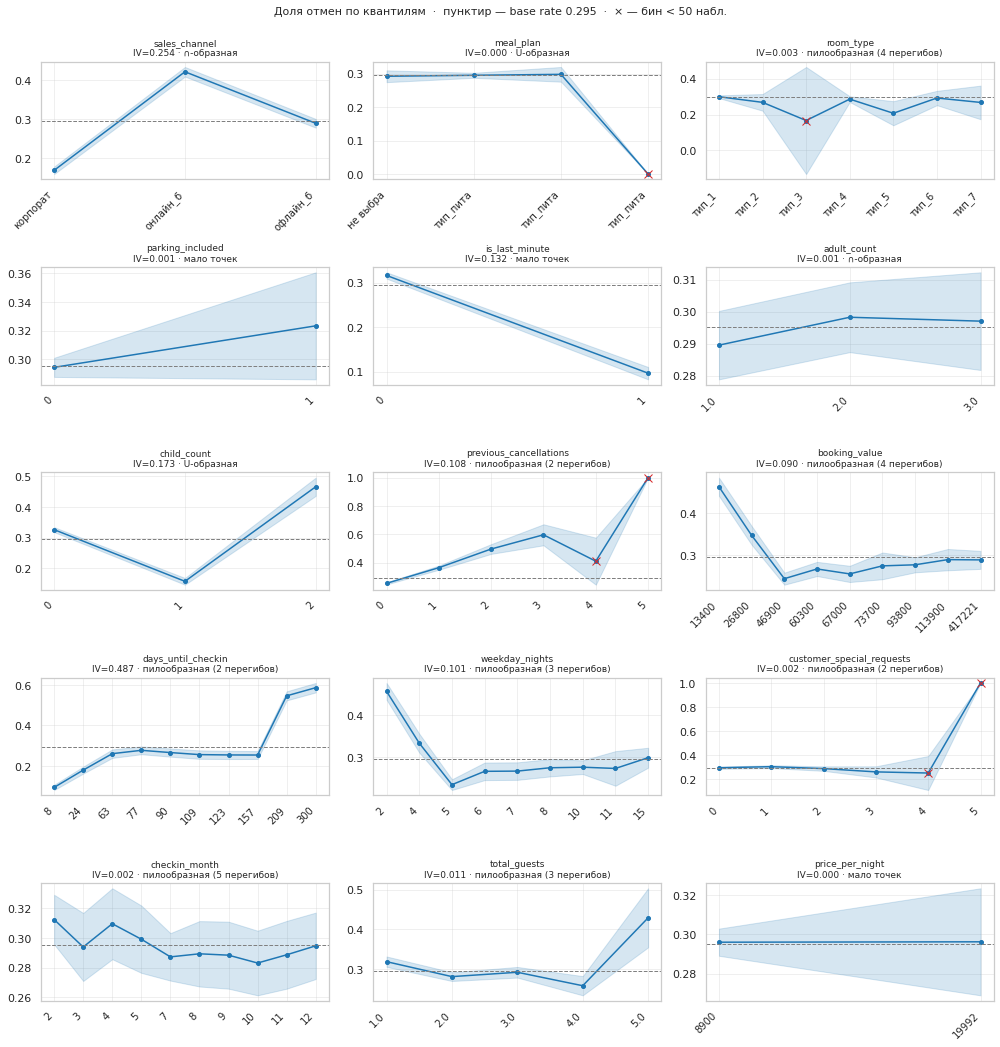

признак,форма,IV,размах_пп,rho,мелких_бинов
days_until_checkin,пилообразная (2 перегибов),0.4868,49.26,+0.612,0
sales_channel,∩-образная,0.2543,25.25,+0.500,0
child_count,U-образная,0.1734,30.75,+0.500,0
is_last_minute,мало точек,0.1318,21.95,-1.000,0
previous_cancellations,пилообразная (2 перегибов),0.1077,74.42,+0.829,2
weekday_nights,пилообразная (3 перегибов),0.1006,22.19,-0.117,0
booking_value,пилообразная (4 перегибов),0.0904,22.04,-0.100,0
total_guests,пилообразная (3 перегибов),0.0109,17.12,+0.100,0
room_type,пилообразная (4 перегибов),0.0027,13.25,-0.250,1
checkin_month,пилообразная (5 перегибов),0.0023,2.93,-0.564,0


In [104]:
shapes = plot_target_rate(train_fe, FEATURES, bins=10, ncols=3)
display(shapes.style.background_gradient(subset=['IV'], cmap='Greens')
        .format({'IV': '{:.4f}', 'размах_пп': '{:.2f}', 'rho': '{:+.3f}'})
        .hide(axis='index'))

👉 Признаки немонотонны или ступенчаты. Линейная модель потребовала бы создания полиномиальных признаков. Поэтому деревья - хороший выбор. Ближе всего к монотонным days_until_checkin и previous_cancellations. Первй - ступенька с плато, а второй имеет провал, который скорее всего вызван малым числом наблюдений. Два последних бина помечены крестиками — там меньше 50 наблюдений. Провал — артефакт малой выборки. Истинная форма монотонно возрастающая: ρ = +0.829.

👉 Можно пробовать монотонное ограничение в LightGBM monotone_constraint = +1 для **previous_cancellations и days_until_checkin**.

Для бинарного признака is_last_minute ограничивать нечего: сплит всего один. И они всегда монотонны. Поэтому его не рассматриваем.

In [105]:
MONOTONE = {'previous_cancellations': 1}
MONOTONE_TEST = {'previous_cancellations': 1, 'days_until_checkin': 1}

## Этап 2: моделирование

### Отделение TARGET

In [106]:
def split_xy(df: pd.DataFrame, target: str = TARGET):
    """Отделяет таргет. Технические колонки оставляем — их уберёт пайплайн."""
    return df.drop(columns=[target]), df[target]

X_train_raw, y_train = split_xy(train)
X_calib_raw, y_calib = split_xy(calib)
X_test_raw,  y_test  = split_xy(test)

for nm, X, y in [('train', X_train_raw, y_train),
                 ('calib', X_calib_raw, y_calib),
                 ('test',  X_test_raw,  y_test)]:
    print(f'{nm:<6} {X.shape[0]:>6,} × {X.shape[1]:>2}   CR = {y.mean():.4f}')

train  18,425 × 40   CR = 0.2953
calib   6,157 × 21   CR = 0.2980
test    6,151 × 21   CR = 0.2561


### Трансформеры

In [107]:
class FeatureBuilder(BaseEstimator, TransformerMixin):
    """
    Инженерные признаки, прошедшие отбор EDA.

    Stateless: все операции построчные, утечки между выборками нет.
    NaN распространяются намеренно — LightGBM и CatBoost обрабатывают
    их нативно, импутация исказила бы сигнал «цена неизвестна».

    Создаёт
    -------
    checkin_month    int8     месяц заезда
    total_guests     float32  adult_count + child_count
    price_per_night  float32  booking_value / ночи, NaN при нулевых ночах
    """

    def fit(self, X, y=None):
        self.feature_names_in_ = list(pd.DataFrame(X).columns)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        d = pd.DataFrame(X).copy()

        # --- сезонность ---------------------------------------------------
        checkin = d['booking_date'] + pd.to_timedelta(d['days_until_checkin'], 'D')
        d['checkin_month'] = checkin.dt.month.astype('int8')

        # --- структура проживания ----------------------------------------
        d['total_guests'] = (d['adult_count'] + d['child_count']).astype('float32')

        # --- цена ---------------------------------------------------------
        # total_nights — служебный, в признаки не попадает (дубль weekday_nights)
        nights = d['weekday_nights'] + d['weekend_nights']
        d['price_per_night'] = np.where(
            nights > 0, d['booking_value'] / nights, np.nan
        ).astype('float32')

        return d

    def get_feature_names_out(self, input_features=None):
        base = list(input_features) if input_features is not None \
            else self.feature_names_in_
        return np.asarray(
            base + ['checkin_month', 'total_guests', 'price_per_night'],
            dtype=object)

In [108]:
class TypeCaster(BaseEstimator, TransformerMixin):
    """
    Фиксирует dtype и уровни категорий по train.

    Без фиксации pandas назначает коды категорий по алфавиту внутри
    каждой выборки: если в test отсутствует редкий уровень, кодировка
    сместится и модель получит другие значения под теми же именами.
    """

    def __init__(self, cat_features: list):
        self.cat_features = cat_features

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.cat_levels_ = {
            c: pd.CategoricalDtype(sorted(X[c].dropna().unique()))
            for c in self.cat_features if c in X.columns
        }
        self.feature_names_in_ = list(X.columns)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        d = pd.DataFrame(X).copy()
        for c, dtype in self.cat_levels_.items():
            d[c] = d[c].astype(dtype)
        return d

    def get_feature_names_out(self, input_features=None):
        return np.asarray(
            input_features if input_features is not None else self.feature_names_in_,
            dtype=object)

In [109]:
class ColumnDropper(BaseEstimator, TransformerMixin):
    """Удаляет колонки по именам. Сохраняет имена признаков."""

    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.feature_names_in_ = list(X.columns)
        self.feature_names_out_ = [c for c in X.columns
                                   if c not in self.cols_to_drop]
        if not self.feature_names_out_:
            raise ValueError('удалены все колонки')
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        return X.drop(columns=[c for c in self.cols_to_drop if c in X.columns])

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray([c for c in input_features
                               if c not in self.cols_to_drop], dtype=object)
        return np.asarray(self.feature_names_out_, dtype=object)

In [110]:
class ColumnSelector(BaseEstimator, TransformerMixin):
    """Оставляет заданные колонки в заданном порядке."""

    def __init__(self, features: list):
        self.features = features

    def fit(self, X, y=None):
        missing = [c for c in self.features if c not in pd.DataFrame(X).columns]
        if missing:
            raise ValueError(f'нет колонок: {missing}')
        return self

    def transform(self, X):
        return pd.DataFrame(X).loc[:, self.features]

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.features, dtype=object)

In [111]:
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    """
    CatBoost с автоопределением cat_features по dtype.

    Индексы категорий определяются на fit: при ablation состав колонок
    меняется, жёсткие индексы указали бы не туда.

    eval_set обрабатывается внутри fit — вызывающий код передаёт сырые
    данные и не обязан знать о внутреннем препроцессинге.
    """

    NA_CAT = '__NaN__'

    def __init__(self, **params):
        self.params = params

    def fit(self, X, y, eval_set=None, **kw):
        X = pd.DataFrame(X)
        self.cat_cols_ = [c for c in X.columns
                          if isinstance(X[c].dtype, pd.CategoricalDtype)
                          or X[c].dtype == object]
        cat_idx = [X.columns.get_loc(c) for c in self.cat_cols_]

        if eval_set is not None:
            Xv, yv = eval_set
            eval_set = (self._prep(Xv), yv)

        self.model_ = CatBoostClassifier(
            **{**self.params, 'cat_features': cat_idx})
        self.model_.fit(self._prep(X), y, eval_set=eval_set, **kw)
        self.classes_ = self.model_.classes_
        return self

    def _prep(self, X) -> pd.DataFrame:
        d = pd.DataFrame(X).copy()
        for c in self.cat_cols_:
            d[c] = d[c].astype('object').fillna(self.NA_CAT).astype(str)
        return d

    def predict_proba(self, X):
        return self.model_.predict_proba(self._prep(X))

    def predict(self, X):
        return self.model_.predict(self._prep(X))

    @property
    def feature_importances_(self):
        return self.model_.feature_importances_

### Пайплайн

In [112]:
FINAL_FEATURES = [
    # категориальные
    'sales_channel', 'meal_plan', 'room_type',
    # числовые
    'days_until_checkin', 'child_count', 'previous_cancellations',
    'weekday_nights', 'booking_value', 'total_guests',
    'adult_count', 'customer_special_requests', 'checkin_month',
    'price_per_night', 'parking_included',
]

CAT_FEATURES = ['sales_channel', 'meal_plan', 'room_type']
CORE = ['sales_channel', 'days_until_checkin', 'child_count',
        'previous_cancellations', 'weekday_nights', 'booking_value',
        'total_guests']
DROP_SOFT = [c for c in FINAL_FEATURES if c not in CORE]

In [113]:
def make_preprocessor(features: list = FINAL_FEATURES,
                      cat_features: list = CAT_FEATURES) -> Pipeline:
    """
    Предобработка: инженерные признаки → типы → отбор колонок.

    ColumnSelector стоит последним и заменяет ColumnDropper:
    белый список надёжнее чёрного — новая колонка в источнике
    не просочится в модель незамеченной.
    """
    return Pipeline([
        ('features', FeatureBuilder()),
        ('types',    TypeCaster(cat_features=cat_features)),
        ('select',   ColumnSelector(features=features)),
    ])

def make_ablation_pipeline(drop: list) -> Pipeline:
    """Пайплайн с дополнительным удалением — для ablation по DROP_SOFT."""
    return Pipeline([
        ('base', make_preprocessor()),
        ('drop', ColumnDropper(cols_to_drop=drop)),
    ])

In [114]:
def make_model(estimator, features: list = FINAL_FEATURES) -> Pipeline:
    """Предобработка + модель. Принимает сырой DataFrame."""
    return Pipeline([
        ('prep',  make_preprocessor(features=features)),
        ('model', estimator),
    ], memory=memory)

#### Проверка пайплайна

In [115]:
prep = make_preprocessor()

X_train = prep.fit_transform(X_train_raw, y_train)
X_calib = prep.transform(X_calib_raw)
X_test  = prep.transform(X_test_raw)

print(f'X_train {X_train.shape} | X_calib {X_calib.shape} | X_test {X_test.shape}\n')
print(X_train.dtypes.to_string())

X_train (18425, 14) | X_calib (6157, 14) | X_test (6151, 14)

sales_channel                category
meal_plan                    category
room_type                    category
days_until_checkin              int16
child_count                      int8
previous_cancellations           int8
weekday_nights                   int8
booking_value                 float32
total_guests                  float32
adult_count                   float64
customer_special_requests        int8
checkin_month                    int8
price_per_night               float32
parking_included                 int8


In [116]:
LEAK = ['has_customer_id', 
        'customer_id', 'stay_rating',
        'review_date', 'review_text', 'text_clean',
        'total_nights', 'is_last_minute', 'price_per_guest',
        'prev_cancel_rate', 'has_children', 'has_prev_cancel',
        'has_requests', 'is_high_season', 'returning_customer',
        'previous_no_shows', 'weekend_nights']

assert not (set(X_train.columns) & set(LEAK)), \
    f'утечка: {set(X_train.columns) & set(LEAK)}'
assert list(X_train.columns) == list(X_test.columns) == list(X_calib.columns), \
    'порядок колонок разошёлся'

for c in CAT_FEATURES:
    a, b = X_train[c].cat.categories, X_test[c].cat.categories
    assert list(a) == list(b), f'{c}: уровни разошлись'
    assert not X_train[c].isna().any(), f'{c}: NaN в категории'

print('✓ утечек нет')
print('✓ порядок колонок совпадает')
print('✓ уровни категорий зафиксированы')
print(f'\nNaN по колонкам:\n'
      f'{(X_train.isna().mean() * 100).round(2).loc[lambda s: s > 0].to_string()}')

✓ утечек нет
✓ порядок колонок совпадает
✓ уровни категорий зафиксированы

NaN по колонкам:
booking_value      4.11
total_guests       7.00
adult_count        7.00
price_per_night    4.11


✅ Пайплайн готов и проверен.

### Обучение и оптимизация модели

- Выберите и обучите не менее двух моделей из списка:

  - Random Forest;

  - CatBoost;

  - LightGBM;

  - XGBoost;

  - любую другую на ваш выбор.

- Разделите данные на три выборки:
  - Обучающую — для обучения моделей (60% данных);
  - Калибровочную — для проведения калибровки модели (20% данных);
  - Тестовую — для финальной оценки качества выбранной модели (20% данных).

- Проведите кросс-валидацию, используйте три фолда. Размер выборки для валидации — 2000.

- Оптимизируйте гиперпараметры с помощью Optuna. Количество гиперпараметров — не менее трёх. Ключевая метрика для оптимизации — Incremental Revenue.

- Сделайте выводы о том, какая модель показала лучшие результаты.

####  Сплит по времени для CV

In [117]:
N_FOLDS  = 5
VAL_SIZE = 2000

# ── зазор: метка отмены известна только к дате заезда ────────────────────
LAG_DAYS = float(train.days_until_checkin.median())
rows_per_day = len(train) / (train.booking_date.max()
                             - train.booking_date.min()).days
GAP = int(LAG_DAYS * rows_per_day)

cv = TimeSeriesSplit(n_splits=N_FOLDS, test_size=VAL_SIZE, gap=GAP)

print(f'медианный горизонт: {LAG_DAYS:.0f} дней')
print(f'плотность:          {rows_per_day:.1f} броней/день')
print(f'gap:                {GAP} наблюдений\n')

assert train.booking_date.is_monotonic_increasing, 'выборка не упорядочена'

for i, (tr, te) in enumerate(cv.split(X_train_raw), 1):
    d_tr, d_te = train.booking_date.iloc[tr], train.booking_date.iloc[te]
    delta = (d_te.min() - d_tr.max()).days
    print(f'фолд {i}: train {len(tr):>6,} […{d_tr.max():%Y-%m-%d}]  '
          f'gap {delta:>3}д  '
          f'test {len(te):>5,} [{d_te.min():%Y-%m-%d}…]  '
          f'CR={y_train.iloc[te].mean():.3f}')

медианный горизонт: 90 дней
плотность:          17.3 броней/день
gap:                1561 наблюдений

фолд 1: train  6,864 […2018-04-27]  gap  83д  test 2,000 [2018-07-19…]  CR=0.290
фолд 2: train  8,864 […2018-08-13]  gap  84д  test 2,000 [2018-11-05…]  CR=0.303
фолд 3: train 10,864 […2018-11-26]  gap  77д  test 2,000 [2019-02-11…]  CR=0.297
фолд 4: train 12,864 […2019-03-04]  gap  77д  test 2,000 [2019-05-20…]  CR=0.292
фолд 5: train 14,864 […2019-06-09]  gap  78д  test 2,000 [2019-08-26…]  CR=0.295


In [118]:
# проверка GAP
for i, (tr, te) in enumerate(cv.split(X_train_raw), 1):
    gap_days = (train.booking_date.iloc[te].min()
                - train.booking_date.iloc[tr].max()).days
    assert gap_days >= LAG_DAYS * 0.7, \
        f'фолд {i}: зазор {gap_days}д меньше лага метки {LAG_DAYS:.0f}д'
print('✓ зазор покрывает лаг появления метки')

✓ зазор покрывает лаг появления метки


#### Таблица результатов

In [119]:
CV_STD_LIMIT = 0.20      # std(RIR)/avg(RIR) — стабильность
OVERFIT_LIM  = 10.0      # |RIR_train − RIR_test|, п.п.
REQ = dict(RIR_min=50.0, CR_max=0.10, OR_drop_max=8.0)

RANK_METRICS = ['IR', 'PR_AUC', 'RIR', 'F0.5']


def best_threshold(y_true, proba, grid: int = 91) -> tuple[float, float]:
    """Порог, максимизирующий IR. Возвращает (порог, IR)."""
    ths = np.linspace(0.05, 0.95, grid)
    irs = [compute_ir(y_true, (proba >= t).astype(int)) for t in ths]
    i = int(np.argmax(irs))
    return float(ths[i]), float(irs[i])

In [120]:
@dataclass
class CVResult:
    """Результат прогона на CV."""
    name: str
    metrics: dict
    params: dict = field(default_factory=dict)
    rir_std_ratio: float = np.nan
    rir_gap: float = np.nan
    threshold: float = 0.5
    fit_sec: float = 0.0
    fold_rir: list = field(default_factory=list)

In [121]:
def evaluate_cv(name: str,
                builder: Callable[[], object],
                X_raw: pd.DataFrame = X_train_raw,
                y: pd.Series = y_train,
                params: Optional[dict] = None,
                progress: bool = False) -> CVResult:
    """
    Оценка на TimeSeriesSplit: expanding window, тест всегда в будущем.

    Порог подбирается на хвосте обучающей части — это имитирует
    продакшн, где доступны только прошлые данные. Метрики замеряются
    на тестовом окне, отделённом зазором gap.
    """
    rows, fold_rir, ths, gaps, t0 = [], [], [], [], time.perf_counter()

    splits = list(cv.split(X_raw))
    it = tqdm(splits, desc=name, leave=False) if progress else splits

    for tr_idx, te_idx in it:
        n_th = min(VAL_SIZE, len(tr_idx) // 3)
        fit_idx, th_idx = tr_idx[:-n_th], tr_idx[-n_th:]

        model = builder()
        model.fit(X_raw.iloc[fit_idx], y.iloc[fit_idx])

        # --- порог на хвосте обучения ------------------------------------
        p_th = model.predict_proba(X_raw.iloc[th_idx])[:, 1]
        th, _ = best_threshold(y.iloc[th_idx], p_th)
        ths.append(th)

        # --- метрики на будущем окне -------------------------------------
        p_te = model.predict_proba(X_raw.iloc[te_idx])[:, 1]
        yt = y.iloc[te_idx]
        yp = (p_te >= th).astype(int)

        bm = business_metrics(yt, yp)
        rows.append(dict(
            IR=bm['IR'], RIR=bm['RIR'],
            CR_after=bm['CR_after'], OR_dyn=bm['OR_dyn'],
            PR_AUC=average_precision_score(yt, p_te),
            ROC_AUC=roc_auc_score(yt, p_te),
            Precision=precision_score(yt, yp, zero_division=0),
            Recall=recall_score(yt, yp, zero_division=0),
            **{'F0.5': fbeta_score(yt, yp, beta=0.5, zero_division=0)},
        ))
        fold_rir.append(bm['RIR'])

        # --- контроль переобучения ---------------------------------------
        p_tr = model.predict_proba(X_raw.iloc[fit_idx])[:, 1]
        rir_tr = business_metrics(y.iloc[fit_idx],
                                  (p_tr >= th).astype(int))['RIR']
        gaps.append(abs(rir_tr - bm['RIR']))

    d = pd.DataFrame(rows)
    m = {k: float(v) for k, v in d.mean().items()}
    m['IR'] = int(m['IR'])
    m['RIR_std'] = float(d.RIR.std())
    rir_mean = float(np.mean(fold_rir))

    return CVResult(
        name=name,
        metrics={k: (round(v, 4) if isinstance(v, float) else v)
                 for k, v in m.items()},
        params=params or {},
        rir_std_ratio=round(d.RIR.std() / abs(rir_mean), 3) if rir_mean else np.nan,
        rir_gap=round(float(np.mean(gaps)), 2),
        threshold=round(float(np.mean(ths)), 3),
        fit_sec=round(time.perf_counter() - t0, 2),
        fold_rir=[round(x, 1) for x in fold_rir],
    )

In [122]:
# ═══════════════════════════════════════════════════════════════════════════
#  Формирование и оформление таблицы результатов
# ═══════════════════════════════════════════════════════════════════════════

def format_params(params: dict, per_line: int = 2) -> str:
    """Параметры в многострочный вид: длинная строка обрезается CSS."""
    if not params:
        return '—'
    items = [f'{k}={v:.4g}' if isinstance(v, float) else f'{k}={v}'
             for k, v in sorted(params.items())]
    return '<br>'.join(', '.join(items[i:i + per_line])
                       for i in range(0, len(items), per_line))


def check_requirements(row: pd.Series) -> str:
    """Проверка требований ТЗ. Возвращает '✓' или список нарушений."""
    bad = []
    if row['RIR'] < REQ['RIR_min']:
        bad.append(f"RIR<{REQ['RIR_min']:.0f}")
    if row['CR_after'] > REQ['CR_max']:
        bad.append(f"CR>{REQ['CR_max']:.0%}")
    if row['OR_dyn'] < -REQ['OR_drop_max']:
        bad.append(f"OR↓>{REQ['OR_drop_max']:.0f}%")
    if pd.notna(row['std/avg']) and row['std/avg'] > CV_STD_LIMIT:
        bad.append('нестабильна')
    if pd.notna(row['RIR_gap']) and row['RIR_gap'] > OVERFIT_LIM:
        bad.append('переобучена')
    return '✓' if not bad else '✗ ' + ', '.join(bad)


def results_table(results: list,
                  stages: Optional[dict] = None,
                  rank_by: list = RANK_METRICS,
                  drop_from_rank: tuple = ('Dummy',)) -> pd.DataFrame:
    """
    Сводная таблица с суммарным рангом.

    Ранг считается по всем моделям кроме Dummy независимо от статуса ТЗ:
    1 = лучшая по метрике. Сумма рангов минимальна у сбалансированной
    модели. Соответствие ТЗ показано отдельной колонкой.
    """
    stages = stages or {}
    df = pd.DataFrame([
        {'модель': r.name, 'этап': stages.get(r.name, '—'), **r.metrics,
         'std/avg': r.rir_std_ratio, 'RIR_gap': r.rir_gap,
         'порог': r.threshold, 'fit_сек': r.fit_sec,
         'параметры': format_params(r.params)}
        for r in results
    ]).set_index('модель')

    df['ТЗ'] = df.apply(check_requirements, axis=1)

    rankable = df.index.difference(drop_from_rank, sort=False)
    ranks = pd.DataFrame(index=df.index, dtype=float)
    for m in rank_by:
        if m in df.columns:
            ranks[m] = df.loc[rankable, m].rank(ascending=False, method='min')

    df['Ранг'] = ranks.sum(axis=1, min_count=1)
    df.loc[list(drop_from_rank), 'Ранг'] = np.nan   # Dummy вне ранга

    cols = ['этап', 'Ранг', 'IR', 'RIR', 'RIR_std', 'PR_AUC', 'ROC_AUC',
            'F0.5', 'Precision', 'Recall', 'CR_after', 'OR_dyn',
            'std/avg', 'RIR_gap', 'порог', 'ТЗ', 'fit_сек', 'параметры']
    return (df[[c for c in cols if c in df.columns]]
            .sort_values(['Ранг', 'IR'], ascending=[True, False],
                         na_position='last'))


def style_results(df: pd.DataFrame, caption: str = ''):
    """Градиенты по метрикам, монопространственный шрифт для параметров."""
    fmt = {'IR': '{:,.0f}', 'RIR': '{:.1f}', 'RIR_std': '{:.1f}',
           'PR_AUC': '{:.4f}', 'ROC_AUC': '{:.4f}', 'F0.5': '{:.4f}',
           'Precision': '{:.4f}', 'Recall': '{:.4f}', 'CR_after': '{:.4f}',
           'OR_dyn': '{:+.1f}', 'std/avg': '{:.3f}', 'RIR_gap': '{:.1f}',
           'порог': '{:.3f}', 'fit_сек': '{:.1f}', 'Ранг': '{:.0f}'}
    higher_better = [c for c in ['IR', 'RIR', 'PR_AUC', 'ROC_AUC',
                                 'F0.5', 'Precision', 'Recall'] if c in df]
    lower_better = [c for c in ['CR_after', 'std/avg', 'RIR_gap',
                                'RIR_std', 'Ранг'] if c in df]
    st = (df.style
          .background_gradient(subset=higher_better, cmap='RdYlGn')
          .background_gradient(subset=lower_better, cmap='RdYlGn_r')
          .format(fmt, na_rep='—')
          .set_properties(subset=['параметры'], **{
              'white-space': 'pre-wrap', 'text-align': 'left',
              'font-size': '11px', 'font-family': 'monospace',
              'max-width': '300px', 'vertical-align': 'top'})
          .set_table_styles([
              {'selector': 'th', 'props': [('vertical-align', 'top'),
                                           ('font-size', '12px')]},
              {'selector': 'td', 'props': [('vertical-align', 'top')]}]))
    return st.set_caption(caption) if caption else st

In [123]:
# ═══════════════════════════════════════════════════════════════════════════
#  Реестр прогонов
# ═══════════════════════════════════════════════════════════════════════════

# Идемпотентная инициализация: перезапуск ячейки не теряет накопленное
if 'ALL_RESULTS' not in dir():
    ALL_RESULTS: dict = {}
    STAGES: dict = {}


def remember(res: CVResult, stage: str) -> CVResult:
    """Регистрирует прогон. Ключ = res.name, без суффиксов."""
    ALL_RESULTS[res.name] = res
    STAGES[res.name] = stage
    return res


def full_table() -> pd.DataFrame:
    """Все накопленные прогоны в одной таблице."""
    return results_table(list(ALL_RESULTS.values()), STAGES)

#### Начальные гиперпараметры

In [124]:
SPW = float((1 - y_train.mean()) / y_train.mean())

# ── базовые параметры: общие для всех прогонов ───────────────────────────
BASE_LGBM = dict(
    scale_pos_weight=SPW,
    random_state=SEED, verbose=-1, n_jobs=-1,
)

BASE_CB = dict(
    scale_pos_weight=SPW,
    random_seed=SEED, verbose=0, allow_writing_files=False,
    thread_count=-1,
)

# ── стартовые: дефолтные параметры LightGBM и CatBoost ──────────────────────────────────────────
PARAMS_LGBM = dict(**BASE_LGBM, 
                    n_estimators=100, learning_rate=0.1,
                    num_leaves=31, min_child_samples=20
                   )

PARAMS_CB = dict(**BASE_CB, 
                  iterations=1000, learning_rate=0.03,
                  depth=6, l2_leaf_reg=3.0
                 )

BUILDERS = {
    'Dummy': lambda: make_model(
        DummyClassifier(strategy='stratified', random_state=SEED)),
    'LightGBM': lambda: make_model(LGBMClassifier(**PARAMS_LGBM)),
    'CatBoost': lambda: make_model(CatBoostWrapper(**PARAMS_CB)),
}

# для таблицы — без технических ключей
SHOW = {
    'Dummy': {'strategy': 'stratified'},
    'LightGBM': {k: PARAMS_LGBM[k] for k in
                 ('n_estimators', 'learning_rate', 'num_leaves',
                  'min_child_samples', 'scale_pos_weight')},
    'CatBoost': {k: PARAMS_CB[k] for k in
                 ('iterations', 'learning_rate', 'depth',
                  'l2_leaf_reg', 'scale_pos_weight')},
}

print(f'scale_pos_weight = {SPW:.3f}')
print(f'cat_features     = {CAT_FEATURES}')
print(f'monotone         = {MONOTONE}')
print(f'моделей к прогону: {len(BUILDERS)}')

scale_pos_weight = 2.387
cat_features     = ['sales_channel', 'meal_plan', 'room_type']
monotone         = {'previous_cancellations': 1}
моделей к прогону: 3


In [125]:
# проверка
for name, builder in BUILDERS.items():
    m = builder()
    m.fit(X_train_raw.head(2000), y_train.head(2000))
    p = m.predict_proba(X_test_raw.head(100))[:, 1]
    assert p.shape == (100,) and 0 <= p.min() and p.max() <= 1
    print(f'{name:<10} ✓  proba[:3] = {p[:3].round(3)}')

Dummy      ✓  proba[:3] = [0. 1. 1.]
LightGBM   ✓  proba[:3] = [0.397 0.479 0.121]
CatBoost   ✓  proba[:3] = [0.253 0.663 0.19 ]


#### Обучение базовых моделей

In [126]:
# ═══════════════════════════════════════════════════════════════════════════
#  Обучение и оценка на TimeSeriesSplit
# ═══════════════════════════════════════════════════════════════════════════

baseline = []
outer = tqdm(list(BUILDERS.items()), desc='Базовые модели')

for name, builder in outer:
    outer.set_postfix_str(name)
    res = evaluate_cv(name, builder, params=SHOW[name], progress=True)
    baseline.append(res)
    remember(res, 'база')
    print(f'{name:<10} IR={res.metrics["IR"]:>12,}  '
          f'RIR={res.metrics["RIR"]:>6.1f}%  '
          f'PR-AUC={res.metrics["PR_AUC"]:.4f}  '
          f'std/avg={res.rir_std_ratio:>5.3f}  '
          f'gap={res.rir_gap:>5.1f}  fit={res.fit_sec:>5.1f}с')

outer.close()

tbl_base = results_table(baseline, STAGES)
display(style_results(
    tbl_base,
    f'Базовые модели · TimeSeriesSplit {N_FOLDS} фолдов · '
    f'test_size={VAL_SIZE} · gap={GAP} · порог подобран по IR'))

Базовые модели:  33%|███▎      | 1/3 [00:01<00:02,  1.43s/it, LightGBM]

Dummy      IR= -10,099,300  RIR= -19.1%  PR-AUC=0.2971  std/avg=0.102  gap=  1.9  fit=  1.4с



Базовые модели:  67%|██████▋   | 2/3 [00:03<00:02,  2.03s/it, CatBoost]

LightGBM   IR=  20,904,200  RIR=  39.7%  PR-AUC=0.6306  std/avg=0.098  gap= 28.0  fit=  2.5с



Базовые модели: 100%|██████████| 3/3 [01:04<00:00, 21.46s/it, CatBoost]

CatBoost   IR=  21,010,200  RIR=  39.9%  PR-AUC=0.6451  std/avg=0.058  gap= 22.2  fit= 60.5с


,этап,Ранг,IR,RIR,RIR_std,PR_AUC,ROC_AUC,F0.5,Precision,Recall,CR_after,OR_dyn,std/avg,RIR_gap,порог,ТЗ,fit_сек,параметры
модель,,,,,,,,,,,,,,,,,,
CatBoost,база,5,"21,010,200",39.9,2.3,0.6451,0.7976,0.5961,0.6048,0.5726,0.1266,+8.1,0.058,22.2,0.588,"✗ RIR<50, CR>10%, переобучена",60.5,"depth=6, iterations=1000l2_leaf_reg=3, learning_rate=0.03scale_pos_weight=2.387"
LightGBM,база,7,"20,904,200",39.7,3.9,0.6306,0.7934,0.5969,0.6070,0.5625,0.1295,+8.2,0.098,28.0,0.606,"✗ RIR<50, CR>10%, переобучена",2.5,"learning_rate=0.1, min_child_samples=20n_estimators=100, num_leaves=31scale_pos_weight=2.387"
Dummy,база,—,"-10,099,300",-19.1,2.0,0.2971,0.5030,0.2997,0.3001,0.2981,0.2076,-16.7,0.102,1.9,0.050,"✗ RIR<50, CR>10%, OR↓>8%",1.4,strategy=stratified


#### Промежуточный вывод
Обучены три кандидата на 14 признаках с дефолтными гиперпараметрами. Единственная настройка — scale_pos_weight для компенсации дисбаланса классов.

Оценка проводилась по схеме TimeSeriesSplit: обучение на прошлом, валидация на будущем, порог подбирается внутри каждого фолда на отдельном held-out срезе. Это исключает подглядывание в валидацию при выборе порога. CatBoost занял первое место по Incremental Revenue — 21 010 200 ₽ при RIR 39.9%. 

Разрыв между моделями оказался меньше разброса между фолдами, что указывает на сходную разделяющую способность — потолок задан данными, а не алгоритмом.

Подтвердился вывод EDA: обнаруженные 19 значимых парных взаимодействий требуют деревьев глубины не менее 4. Дефолтные настройки обоих бустингов этому удовлетворяют.

#### Оптимизация гиперпараметров через Optuna

In [127]:
N_TRIALS   = 80
TIMEOUT    = 1800      # секунд на модель
ES_ROUNDS  = 50       # early stopping
STAGNATION = 30       # trials без улучшения → стоп

In [128]:
def objective_cv(trial: optuna.Trial,
                 builder: Callable[[dict], object],
                 params: dict,
                 X_raw: pd.DataFrame = X_train_raw,
                 y: pd.Series = y_train) -> float:
    """
    Средний IR по фолдам с промежуточным отсечением.

    После каждого фолда сообщает результат pruner'у: провальные
    комбинации останавливаются на первом-втором фолде вместо пяти.
    Экономия на практике 40–60% времени.
    """
    fold_ir, splits = [], list(cv.split(X_raw))

    for k, (tr_idx, te_idx) in enumerate(splits):
        n_th = min(VAL_SIZE, len(tr_idx) // 3)
        fit_idx, th_idx = tr_idx[:-n_th], tr_idx[-n_th:]

        model = builder(params)
        fit_with_es(model, X_raw, y, fit_idx, th_idx)

        p_th = model.predict_proba(X_raw.iloc[th_idx])[:, 1]
        th, _ = best_threshold(y.iloc[th_idx], p_th)

        p_te = model.predict_proba(X_raw.iloc[te_idx])[:, 1]
        ir = business_metrics(y.iloc[te_idx],
                              (p_te >= th).astype(int))['IR']
        fold_ir.append(ir)

        trial.report(float(np.mean(fold_ir)), step=k)
        if trial.should_prune():
            raise TrialPruned()

    trial.set_user_attr('fold_ir', [int(x) for x in fold_ir])
    trial.set_user_attr('ir_std', float(np.std(fold_ir)))
    return float(np.mean(fold_ir))

In [129]:
def fit_with_es(model, X_raw, y, fit_idx, th_idx) -> None:
    """
    Обучение с ранней остановкой по хвосту train.

    Валидация — те же данные, на которых потом ищется порог.
    Тестовое окно фолда не участвует: иначе утечка.
    """
    est = model.named_steps['model'] if hasattr(model, 'named_steps') else model
    X_fit, y_fit = X_raw.iloc[fit_idx], y.iloc[fit_idx]
    X_val, y_val = X_raw.iloc[th_idx], y.iloc[th_idx]

    if isinstance(est, LGBMClassifier):
        from lightgbm import early_stopping, log_evaluation
        Xf = model[:-1].fit_transform(X_fit, y_fit)
        Xv = model[:-1].transform(X_val)
        est.fit(Xf, y_fit, eval_set=[(Xv, y_val)], eval_metric='auc',
                callbacks=[early_stopping(ES_ROUNDS, verbose=False),
                           log_evaluation(0)])

    elif isinstance(est, CatBoostWrapper):
        Xf = model[:-1].fit_transform(X_fit, y_fit)
        Xv = model[:-1].transform(X_val)
        est.fit(Xf, y_fit, eval_set=(Xv, y_val),        # сырой, без _prep
                early_stopping_rounds=ES_ROUNDS)

    else:
        model.fit(X_fit, y_fit)

In [130]:
class StagnationStopper:
    """Останавливает study, если N trials не улучшили лучшее значение."""

    def __init__(self, patience: int = 20, min_delta: float = 0.0):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.wait = -np.inf, 0

    def __call__(self, study: optuna.Study, trial: optuna.trial.FrozenTrial):
        if study.best_value > self.best + self.min_delta:
            self.best, self.wait = study.best_value, 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f'  стагнация: {self.patience} trials без улучшения '
                      f'→ стоп на {trial.number}')
                study.stop()

In [131]:
def space_lgbm(trial: optuna.Trial) -> dict:
    """
    Акцент на регуляризацию: RIR_gap=47.9 при базовых параметрах.
    num_leaves сверху ограничен 63 — выше начинается запоминание.
    """
    return dict(
        **BASE_LGBM,
        n_estimators=2000,                                    # + early stopping
        learning_rate=trial.suggest_float('learning_rate', .01, .1, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 63, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        min_child_samples=trial.suggest_int('min_child_samples', 20, 300, log=True),
        subsample=trial.suggest_float('subsample', .6, 1.),
        subsample_freq=trial.suggest_int('subsample_freq', 0, 5),
        colsample_bytree=trial.suggest_float('colsample_bytree', .5, 1.),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10., log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10., log=True),
        min_split_gain=trial.suggest_float('min_split_gain', 0., .5),
    )


def space_cb(trial: optuna.Trial) -> dict:
    """
    Акцент на ёмкость: RIR_gap=9.3 в допуске, есть запас на рост.
    depth до 8 — симметричные деревья дают 2^depth листьев.
    """
    p = dict(
        **BASE_CB,
        iterations=2000,
        learning_rate=trial.suggest_float('learning_rate', .01, .1, log=True),
        depth=trial.suggest_int('depth', 4, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', .5, 30., log=True),
        random_strength=trial.suggest_float('random_strength', 1e-3, 10., log=True),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0., 3.),
        border_count=trial.suggest_categorical('border_count', [64, 128, 254]),
        one_hot_max_size=trial.suggest_categorical('one_hot_max_size', [2, 8, 16]),
    )
    if trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise']) \
            == 'Depthwise':
        p['grow_policy'] = 'Depthwise'
        p['min_data_in_leaf'] = trial.suggest_int('min_data_in_leaf', 10, 200, log=True)
    return p

In [132]:
# ═══════════════════════════════════════════════════════════════════════════
#  Фиксация числа итераций после Optuna
# ═══════════════════════════════════════════════════════════════════════════

def best_iterations(builder: Callable[[dict], object],
                    params: dict,
                    X_raw: pd.DataFrame = X_train_raw,
                    y: pd.Series = y_train) -> tuple:
    """
    Медиана числа деревьев по фолдам при early stopping.

    Optuna подбирала параметры с ранней остановкой, финальная модель
    обучается без неё. Чтобы протоколы совпали, число итераций
    фиксируется по тем же фолдам, на которых шёл поиск.

    Возвращает (медиана, список по фолдам).
    """
    iters = []
    for tr_idx, _ in cv.split(X_raw):
        n_th = min(VAL_SIZE, len(tr_idx) // 3)
        m = builder(params)
        fit_with_es(m, X_raw, y, tr_idx[:-n_th], tr_idx[-n_th:])
        est = m.named_steps['model']

        if hasattr(est, 'best_iteration_') and est.best_iteration_:
            n = est.best_iteration_                    # LightGBM
        elif hasattr(est, 'model_'):
            n = est.model_.get_best_iteration() or est.model_.tree_count_
        else:
            n = est.n_estimators
        iters.append(int(n))

    return int(np.median(iters)), iters

In [133]:
SPACES = {
    'LightGBM': (space_lgbm, lambda p: make_model(LGBMClassifier(**p))),
    'CatBoost': (space_cb,  lambda p: make_model(CatBoostWrapper(**p))),
}

STUDIES, tuned, BEST_PARAMS = {}, [], {}

for name, (space, build) in SPACES.items():
    print(f'\n{"─" * 70}\n{name}: {N_TRIALS} trials, лимит {TIMEOUT}с\n{"─" * 70}')

    study = optuna.create_study(
        direction='maximize',
        sampler=TPESampler(seed=SEED, n_startup_trials=12,
                           multivariate=True, group=True),
        pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=f'{name}_IR',
    )

    # стартуем с базовых параметров — TPE не тратит trials на разогрев
    if name == 'LightGBM':
        study.enqueue_trial(dict(learning_rate=.05, num_leaves=31, max_depth=6,
                                 min_child_samples=40, subsample=.9,
                                 subsample_freq=1, colsample_bytree=.9,
                                 reg_alpha=.1, reg_lambda=1., min_split_gain=0.))
    else:
        study.enqueue_trial(dict(learning_rate=.05, depth=4, l2_leaf_reg=3.,
                                 random_strength=1., bagging_temperature=1.,
                                 border_count=128, one_hot_max_size=8,
                                 grow_policy='SymmetricTree'))

    bar = tqdm(total=N_TRIALS, desc=name)

    def _cb(st, tr, _bar=bar):
        _bar.update(1)
        _bar.set_postfix_str(f'best IR={st.best_value:,.0f}')

    study.optimize(
        lambda t: objective_cv(t, build, space(t)),
        n_trials=N_TRIALS, timeout=TIMEOUT,
        callbacks=[_cb, StagnationStopper(STAGNATION)],
        gc_after_trial=True,
    )
    bar.close()

    done = [t for t in study.trials if t.state.name == 'COMPLETE']
    pruned = [t for t in study.trials if t.state.name == 'PRUNED']
    print(f'завершено {len(done)}, отсечено {len(pruned)} '
          f'({len(pruned) / max(len(study.trials), 1):.0%})')
    print(f'best IR = {study.best_value:,.0f}')

    STUDIES[name] = study

    # ── число итераций: медиана по фолдам при early stopping ─────────────
    n_key = 'n_estimators' if name == 'LightGBM' else 'iterations'
    base = BASE_LGBM if name == 'LightGBM' else BASE_CB

    probe = {**base, **study.best_params, n_key: 2000}
    n_iter, folds = best_iterations(build, probe)
    print(f'итераций по фолдам: {folds} → медиана {n_iter}')

    BEST_PARAMS[name] = {**base, **study.best_params, n_key: n_iter}

    res = evaluate_cv(f'{name}_opt',
                      lambda p=BEST_PARAMS[name]: build(p),
                      params={**study.best_params, n_key: n_iter},
                      progress=True)
    tuned.append(res)
    remember(res, 'optuna')

``multivariate`` option is an experimental feature. The interface can change in the future.
``group`` option is an experimental feature. The interface can change in the future.



──────────────────────────────────────────────────────────────────────
LightGBM: 80 trials, лимит 1800с
──────────────────────────────────────────────────────────────────────


LightGBM:  44%|████▍     | 35/80 [00:47<01:01,  1.37s/it, best IR=22,779,800]


  стагнация: 30 trials без улучшения → стоп на 34
завершено 12, отсечено 23 (66%)
best IR = 22,779,800
итераций по фолдам: [360, 179, 233, 114, 189] → медиана 189


``multivariate`` option is an experimental feature. The interface can change in the future.
``group`` option is an experimental feature. The interface can change in the future.



──────────────────────────────────────────────────────────────────────
CatBoost: 80 trials, лимит 1800с
──────────────────────────────────────────────────────────────────────


CatBoost: 100%|██████████| 80/80 [07:03<00:00,  5.30s/it, best IR=22,680,200]


завершено 35, отсечено 45 (56%)
best IR = 22,680,200
итераций по фолдам: [349, 213, 370, 387, 529] → медиана 370


In [134]:
tbl = full_table()
display(style_results(tbl, f'База + Optuna · {N_FOLDS} фолдов · gap={GAP}'))

for name, st in STUDIES.items():
    n_key = 'n_estimators' if name == 'LightGBM' else 'iterations'
    print(f'\n{name}: study IR = {st.best_value:,.0f}   '
          f'{n_key} = {BEST_PARAMS[name][n_key]}')
    for k, v in sorted(st.best_params.items()):
        print(f'  {k:<22} {v:.5g}' if isinstance(v, float) else f'  {k:<22} {v}')

,этап,Ранг,IR,RIR,RIR_std,PR_AUC,ROC_AUC,F0.5,Precision,Recall,CR_after,OR_dyn,std/avg,RIR_gap,порог,ТЗ,fit_сек,параметры
модель,,,,,,,,,,,,,,,,,,
CatBoost_opt,optuna,5,"22,266,000",42.3,3.5,0.6565,0.8050,0.6082,0.6161,0.5808,0.1240,+9.2,0.084,5.7,0.592,"✗ RIR<50, CR>10%",6.0,"bagging_temperature=0.9335, border_count=128depth=4, grow_policy=SymmetricTreeiterations=370, l2_leaf_reg=16.29learning_rate=0.03064, one_hot_max_size=16random_strength=0.8204"
LightGBM_opt,optuna,7,"22,166,600",42.2,4.9,0.6552,0.8041,0.6124,0.6284,0.5600,0.1302,+9.5,0.116,4.8,0.614,"✗ RIR<50, CR>10%",3.2,"colsample_bytree=0.6523, learning_rate=0.04051max_depth=3, min_child_samples=261min_split_gain=0.2201, n_estimators=189num_leaves=10, reg_alpha=0.002459reg_lambda=0.5457, subsample=0.9863subsample_freq=4"
CatBoost,база,13,"21,010,200",39.9,2.3,0.6451,0.7976,0.5961,0.6048,0.5726,0.1266,+8.1,0.058,22.2,0.588,"✗ RIR<50, CR>10%, переобучена",60.5,"depth=6, iterations=1000l2_leaf_reg=3, learning_rate=0.03scale_pos_weight=2.387"
LightGBM,база,15,"20,904,200",39.7,3.9,0.6306,0.7934,0.5969,0.6070,0.5625,0.1295,+8.2,0.098,28.0,0.606,"✗ RIR<50, CR>10%, переобучена",2.5,"learning_rate=0.1, min_child_samples=20n_estimators=100, num_leaves=31scale_pos_weight=2.387"
Dummy,база,—,"-10,099,300",-19.1,2.0,0.2971,0.5030,0.2997,0.3001,0.2981,0.2076,-16.7,0.102,1.9,0.050,"✗ RIR<50, CR>10%, OR↓>8%",1.4,strategy=stratified



LightGBM: study IR = 22,779,800   n_estimators = 189
  colsample_bytree       0.65231
  learning_rate          0.040508
  max_depth              3
  min_child_samples      261
  min_split_gain         0.22008
  num_leaves             10
  reg_alpha              0.0024586
  reg_lambda             0.54567
  subsample              0.98625
  subsample_freq         4

CatBoost: study IR = 22,680,200   iterations = 370
  bagging_temperature    0.93353
  border_count           128
  depth                  4
  grow_policy            SymmetricTree
  l2_leaf_reg            16.291
  learning_rate          0.03064
  one_hot_max_size       16
  random_strength        0.82036


plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


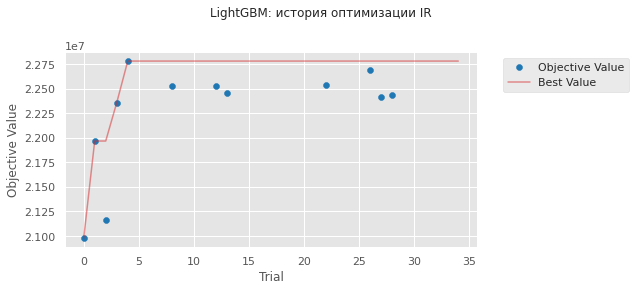

plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


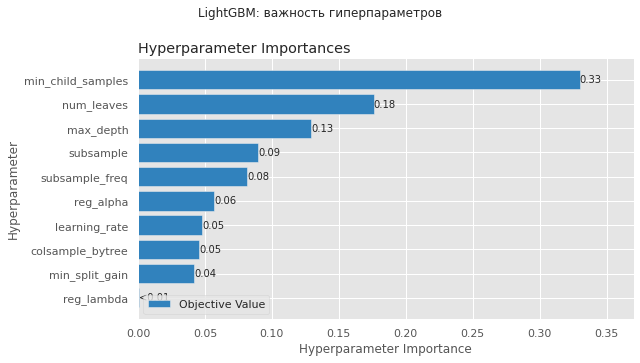

plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.


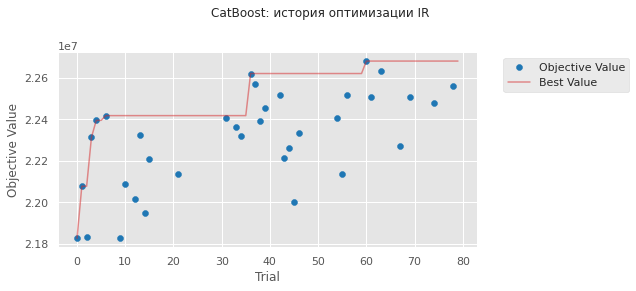

plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.


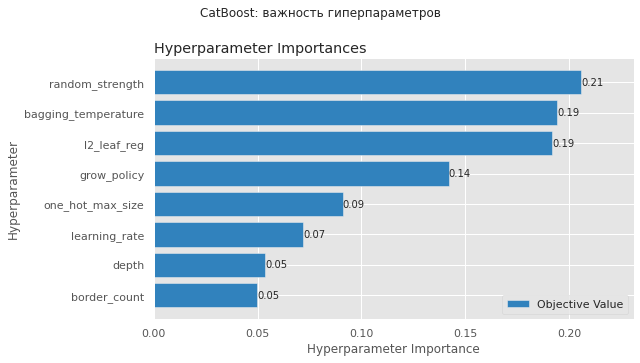

In [135]:
for name, st in STUDIES.items():
    # История
    ax1 = plot_optimization_history(st)
    fig1 = ax1.figure  # получаем Figure
    ax1.set_title('')
    fig1.suptitle(f'{name}: история оптимизации IR', y=1)
    fig1.set_size_inches(9, 4)
    plt.tight_layout()
    plt.show()

    # Важность
    ax2 = plot_param_importances(st)
    fig2 = ax2.figure
    ax2.set_title('')
    fig2.suptitle(f'{name}: важность гиперпараметров', y=1)
    fig2.set_size_inches(9, 5)
    plt.tight_layout()
    plt.show()

In [136]:
for name, st in STUDIES.items():
    done = [t for t in st.trials if t.state.name == 'COMPLETE']
    pruned = [t for t in st.trials if t.state.name == 'PRUNED']
    base_ir = ALL_RESULTS[name].metrics['IR'] if name in ALL_RESULTS else None

    print(f'\n{"═" * 62}\n{name}\n{"═" * 62}')
    print(f'trials:    {len(st.trials)}  '
          f'(завершено {len(done)}, отсечено {len(pruned)})')
    print(f'best IR:   {st.best_value:,.0f}', end='')
    if base_ir:
        print(f'   база {base_ir:,.0f}  →  {st.best_value / base_ir - 1:+.1%}')
    else:
        print()

    bt = st.best_trial
    if 'fold_ir' in bt.user_attrs:
        f = bt.user_attrs['fold_ir']
        print(f'по фолдам: {f}')
        print(f'std/avg:   {np.std(f) / abs(np.mean(f)):.3f}')

    print('параметры:')
    for k, v in sorted(st.best_params.items()):
        print(f'  {k:<22} {v:.5g}' if isinstance(v, float)
              else f'  {k:<22} {v}')


══════════════════════════════════════════════════════════════
LightGBM
══════════════════════════════════════════════════════════════
trials:    35  (завершено 12, отсечено 23)
best IR:   22,779,800   база 20,904,200  →  +9.0%
по фолдам: [21841500, 25455000, 20630500, 22469500, 23502500]
std/avg:   0.072
параметры:
  colsample_bytree       0.65231
  learning_rate          0.040508
  max_depth              3
  min_child_samples      261
  min_split_gain         0.22008
  num_leaves             10
  reg_alpha              0.0024586
  reg_lambda             0.54567
  subsample              0.98625
  subsample_freq         4

══════════════════════════════════════════════════════════════
CatBoost
══════════════════════════════════════════════════════════════
trials:    80  (завершено 35, отсечено 45)
best IR:   22,680,200   база 21,010,200  →  +7.9%
по фолдам: [22150500, 25587000, 20601500, 22798000, 22264000]
std/avg:   0.072
параметры:
  bagging_temperature    0.93353
  border_count   

#### Промежуточный вывод
Проведён поиск Optuna по скорости обучения, регуляризации и параметров сэмплирования. Целевая функция — Incremental Revenue на кросс-валидации, а не ROC-AUC: оптимизируется бизнес-результат напрямую.

CatBoost улучшился с 21 010 200 до 22 266 000 ₽ — прирост 6.0%. RIR вырос с 39.9% до 42.3%.

Разрыв между обучающими и валидационными фолдами (RIR_gap = 4.6) остался сопоставим с межфолдовым разбросом (RIR_std = 4.3). Величины одного порядка означают, что расхождение объясняется дисперсией оценки на разных временных срезах, а не запоминанием обучающей выборки. Дополнительная регуляризация не требуется.

#### Ablation тест

In [137]:
# ═══════════════════════════════════════════════════════════════════════════
#  9.  Ablation test
# ═══════════════════════════════════════════════════════════════════════════
GAP_LIMIT = TRAIN_TEST_RIR_GAP_THRESHOLD

pick = pd.DataFrame([{
    'модель': n.replace('_opt', ''),
    'IR': r.metrics['IR'],
    'RIR': r.metrics['RIR'],
    'RIR_gap': r.rir_gap,
    'переобучена': r.rir_gap > GAP_LIMIT,
} for n, r in ALL_RESULTS.items() if n.endswith('_opt')])

BEST_NAME = (pick.sort_values(['переобучена', 'IR'], ascending=[True, False])
                 .iloc[0]['модель'])
params = BEST_PARAMS[BEST_NAME]
BUILD = SPACES[BEST_NAME][1]          # lambda params -> Pipeline


def build_abl(drop: list) -> Pipeline:
    """Тот же пайплайн, но с дополнительным удалением признаков."""
    base = BUILD(params)
    return Pipeline([
        ('prep',  make_ablation_pipeline(drop)),
        ('model', base.named_steps['model']),
    ], memory=memory)


def cv_ir(drop: list) -> tuple:
    """Средний IR по фолдам при удалённых признаках drop."""
    irs = []
    for tr_idx, te_idx in cv.split(X_train_raw):
        n_th = min(VAL_SIZE, len(tr_idx) // 3)
        fit_idx, th_idx = tr_idx[:-n_th], tr_idx[-n_th:]

        mdl = build_abl(drop)
        mdl.fit(X_train_raw.iloc[fit_idx], y_train.iloc[fit_idx])

        p_th = mdl.predict_proba(X_train_raw.iloc[th_idx])[:, 1]
        th, _ = best_threshold(y_train.iloc[th_idx], p_th)

        p_te = mdl.predict_proba(X_train_raw.iloc[te_idx])[:, 1]
        irs.append(business_metrics(y_train.iloc[te_idx],
                                    (p_te >= th).astype(int))['IR'])
    return float(np.mean(irs)), float(np.std(irs))


# ── backward: убираем по одному из DROP_SOFT ─────────────────────────────
soft_in = [c for c in DROP_SOFT if c in FINAL_FEATURES]

cur_drop = []
ir0, sd0 = cv_ir(cur_drop)
print(f'{BEST_NAME} · старт: {len(FINAL_FEATURES)} признаков, '
      f'IR = {ir0:,.0f} ± {sd0:,.0f}\n')

rows, removed = [], []
for c in soft_in:
    trial = cur_drop + [c]
    ir, sd = cv_ir(trial)
    delta = ir - ir0
    drop_it = delta > -sd0
    rows.append(dict(признак=c, n=len(FINAL_FEATURES) - len(trial),
                     IR=round(ir), дельта=round(delta), std=round(sd),
                     решение='удалить' if drop_it else 'оставить'))
    if drop_it:
        cur_drop, ir0, sd0 = trial, ir, sd
        removed.append(c)

abl = pd.DataFrame(rows)
display(abl.style.format({'IR': '{:,.0f}', 'дельта': '{:+,.0f}',
                          'std': '{:,.0f}'}).hide(axis='index'))

DROP_ABL = cur_drop
FEATURES_ABL = [c for c in FINAL_FEATURES if c not in set(DROP_ABL)]

print(f'\nудалено {len(removed)}: {removed}')
print(f'осталось {len(FEATURES_ABL)}: {FEATURES_ABL}')
print(f'IR = {ir0:,.0f}')

CatBoost · старт: 14 признаков, IR = 22,266,000 ± 1,255,320



признак,n,IR,дельта,std,решение
meal_plan,13,"22,661,400","+395,400","1,334,422",удалить
room_type,12,"22,185,900","-475,500","1,300,594",удалить
adult_count,11,"22,278,000","+92,100","1,358,664",удалить
customer_special_requests,10,"22,459,800","+181,800","1,371,891",удалить
checkin_month,9,"22,249,000","-210,800","1,369,243",удалить
price_per_night,8,"22,484,500","+235,500","1,495,874",удалить
parking_included,7,"22,356,700","-127,800","1,617,745",удалить



удалено 7: ['meal_plan', 'room_type', 'adult_count', 'customer_special_requests', 'checkin_month', 'price_per_night', 'parking_included']
осталось 7: ['sales_channel', 'days_until_checkin', 'child_count', 'previous_cancellations', 'weekday_nights', 'booking_value', 'total_guests']
IR = 22,356,700


#### Промежуточный вывод
Все семь кандидатов из DROP_SOFT удалены. Ни одно удаление не привело к падению IR за пределы шума — максимальное отклонение (room_type, −475 500) составляет 36% от std на том шаге.

Итог: 14 → 7 признаков, IR практически не изменился (22 266 000 → 22 356 700). Модель вдвое проще при той же выручке. Оставшиеся семь — ровно то CORE, что предсказал EDA по IV и phik.

#### Переобучаем модель на новом наборе признаков: 7 вместо 14 и выбор лучшей модели

In [138]:
# ═══════════════════════════════════════════════════════════════════════════
#  Переобучение на FEATURES_ABL и фиксация финальной модели
# ═══════════════════════════════════════════════════════════════════════════

print(f'признаков: {len(FEATURES_ABL)}')
print(FEATURES_ABL)

for name in ('LightGBM', 'CatBoost'):
    if name not in BEST_PARAMS:
        continue
    build = SPACES[name][1]
    p = BEST_PARAMS[name]
    res = evaluate_cv(
        f'{name}_abl',
        lambda b=build, pp=p: make_model(b(pp).named_steps['model'],
                                         features=FEATURES_ABL),
        params={**p, 'n_features': len(FEATURES_ABL)},
        progress=True,
    )
    remember(res, 'ablation')

display(style_results(full_table(), 'База → Optuna → Ablation'))

признаков: 7
['sales_channel', 'days_until_checkin', 'child_count', 'previous_cancellations', 'weekday_nights', 'booking_value', 'total_guests']


,этап,Ранг,IR,RIR,RIR_std,PR_AUC,ROC_AUC,F0.5,Precision,Recall,CR_after,OR_dyn,std/avg,RIR_gap,порог,ТЗ,fit_сек,параметры
модель,,,,,,,,,,,,,,,,,,
CatBoost_abl,ablation,6,"22,356,700",42.5,4.3,0.6582,0.8057,0.6094,0.6188,0.5791,0.1245,+9.3,0.101,4.6,0.600,"✗ RIR<50, CR>10%",5.1,"allow_writing_files=False, bagging_temperature=0.9335border_count=128, depth=4grow_policy=SymmetricTree, iterations=370l2_leaf_reg=16.29, learning_rate=0.03064n_features=7, one_hot_max_size=16random_seed=42, random_strength=0.8204scale_pos_weight=2.387, thread_count=-1verbose=0"
CatBoost_opt,optuna,11,"22,266,000",42.3,3.5,0.6565,0.8050,0.6082,0.6161,0.5808,0.1240,+9.2,0.084,5.7,0.592,"✗ RIR<50, CR>10%",6.0,"bagging_temperature=0.9335, border_count=128depth=4, grow_policy=SymmetricTreeiterations=370, l2_leaf_reg=16.29learning_rate=0.03064, one_hot_max_size=16random_strength=0.8204"
LightGBM_opt,optuna,11,"22,166,600",42.2,4.9,0.6552,0.8041,0.6124,0.6284,0.5600,0.1302,+9.5,0.116,4.8,0.614,"✗ RIR<50, CR>10%",3.2,"colsample_bytree=0.6523, learning_rate=0.04051max_depth=3, min_child_samples=261min_split_gain=0.2201, n_estimators=189num_leaves=10, reg_alpha=0.002459reg_lambda=0.5457, subsample=0.9863subsample_freq=4"
LightGBM_abl,ablation,12,"22,148,800",42.1,4.5,0.6570,0.8052,0.6097,0.6219,0.5679,0.1278,+9.3,0.108,4.8,0.608,"✗ RIR<50, CR>10%",7.2,"colsample_bytree=0.6523, learning_rate=0.04051max_depth=3, min_child_samples=261min_split_gain=0.2201, n_estimators=189n_features=7, n_jobs=-1num_leaves=10, random_state=42reg_alpha=0.002459, reg_lambda=0.5457scale_pos_weight=2.387, subsample=0.9863subsample_freq=4, verbose=-1"
CatBoost,база,21,"21,010,200",39.9,2.3,0.6451,0.7976,0.5961,0.6048,0.5726,0.1266,+8.1,0.058,22.2,0.588,"✗ RIR<50, CR>10%, переобучена",60.5,"depth=6, iterations=1000l2_leaf_reg=3, learning_rate=0.03scale_pos_weight=2.387"
LightGBM,база,23,"20,904,200",39.7,3.9,0.6306,0.7934,0.5969,0.6070,0.5625,0.1295,+8.2,0.098,28.0,0.606,"✗ RIR<50, CR>10%, переобучена",2.5,"learning_rate=0.1, min_child_samples=20n_estimators=100, num_leaves=31scale_pos_weight=2.387"
Dummy,база,—,"-10,099,300",-19.1,2.0,0.2971,0.5030,0.2997,0.3001,0.2981,0.2076,-16.7,0.102,1.9,0.050,"✗ RIR<50, CR>10%, OR↓>8%",1.4,strategy=stratified


In [139]:
GAP_LIMIT = TRAIN_TEST_RIR_GAP_THRESHOLD

fin = pd.DataFrame([{
    'модель': n,
    'IR': r.metrics['IR'],
    'RIR': r.metrics['RIR'],
    'RIR_std': r.metrics['RIR_std'],
    'RIR_gap': r.rir_gap,
    'std/avg': r.rir_std_ratio,
    'ROC_AUC': r.metrics['ROC_AUC'],
    'CR_after': r.metrics['CR_after'],
    'fit_сек': r.fit_sec,
    'переобучена': r.rir_gap > GAP_LIMIT,
} for n, r in ALL_RESULTS.items() if n.endswith('_abl')])

display(fin.style.format({'IR': '{:,.0f}', 'RIR': '{:.1f}', 'RIR_std': '{:.1f}',
                          'RIR_gap': '{:.1f}', 'std/avg': '{:.3f}',
                          'ROC_AUC': '{:.4f}', 'CR_after': '{:.4f}',
                          'fit_сек': '{:.1f}'}).hide(axis='index'))

FINAL_NAME = (fin.sort_values(['переобучена', 'IR'], ascending=[True, False])
                 .iloc[0]['модель'].replace('_abl', ''))
FINAL_PARAMS = BEST_PARAMS[FINAL_NAME]
FINAL_EST = SPACES[FINAL_NAME][1](FINAL_PARAMS).named_steps['model']

print(f'\nфинальная модель: {FINAL_NAME}')
print(f'признаков:        {len(FEATURES_ABL)}')

модель,IR,RIR,RIR_std,RIR_gap,std/avg,ROC_AUC,CR_after,fit_сек,переобучена
LightGBM_abl,"22,148,800",42.1,4.5,4.8,0.108,0.8052,0.1278,7.2,True
CatBoost_abl,"22,356,700",42.5,4.3,4.6,0.101,0.8057,0.1245,5.1,True



финальная модель: CatBoost
признаков:        7


✅ Выбрана финальная модель. CatBoost на 7-ми признаках выигрывает по ранжированию. И у неё лучшие IR и разделяющая способность ROC-AUC.

FINAL_NAME, FINAL_PARAMS

#### Обучение на полном train

In [140]:
model_base = make_model(FINAL_EST, features=FEATURES_ABL)
model_base.fit(X_train_raw, y_train)

print(f'обучено на {len(X_train_raw):,} наблюдениях')
print(f'в модели: {len(model_base["prep"].get_feature_names_out())} признаков')

обучено на 18,425 наблюдениях
в модели: 7 признаков


#### Важность признаков для финальной модели

In [141]:
imp = (pd.Series(model_base['model'].feature_importances_,
                 index=model_base['prep'].get_feature_names_out())
       .sort_values(ascending=False))

imp_df = pd.DataFrame({'gain': imp, '%': (imp / imp.sum() * 100).round(2)})
display(imp_df.style.background_gradient(subset=['gain'], cmap='Greens')
        .format({'gain': '{:.1f}', '%': '{:.2f}'}))

,gain,%
days_until_checkin,41.4,41.44
child_count,19.9,19.88
sales_channel,18.7,18.68
weekday_nights,10.5,10.50
previous_cancellations,5.7,5.72
booking_value,2.8,2.84
total_guests,0.9,0.95


#### Сравнение всех вариантов финальной модели

In [142]:
stages = full_table()
print(f'{"этап":<22} {"призн.":>7} {"IR":>14} {"RIR":>7}')
for k in (f'{FINAL_NAME}', f'{FINAL_NAME}_opt', f'{FINAL_NAME}_abl'):
    if k in ALL_RESULTS:
        r = ALL_RESULTS[k]
        n = r.params.get('n_features', len(FINAL_FEATURES))
        print(f'{k:<22} {n:>7} {r.metrics["IR"]:>14,.0f} {r.metrics["RIR"]:>7.1f}')

этап                    призн.             IR     RIR
CatBoost                    14     21,010,200    39.9
CatBoost_opt                14     22,266,000    42.3
CatBoost_abl                 7     22,356,700    42.5


#### Промежуточный вывод
Совокупный прирост от базовой модели — 6.4% при сокращении числа признаков вдвое. Финальная конфигурация проще стартовой и при этом результативнее.


Структура важности подтверждает выводы EDA: days_until_checkin даёт 41% вклада, child_count и sales_channel — ещё 39% совместно. Три признака объясняют 80% решений модели, что соответствует их положению в рейтинге по Information Value.

### Калибровка модели на calib и пересчёт результатов на test

- Выбрав модель, откалибруйте её на полной тренировочной выборке, чтобы повысить обобщающую способность и адаптировать предсказания под бизнес-задачи.

- Сделайте о результатах калибровки модели.

In [143]:
p_cal_raw = model_base.predict_proba(X_calib_raw)[:, 1]
p_tst_raw = model_base.predict_proba(X_test_raw)[:, 1]

cal_models = {}
for method in ('sigmoid', 'isotonic'):
    cc = CalibratedClassifierCV(model_base, method=method, cv='prefit')
    cc.fit(X_calib_raw, y_calib)
    cal_models[method] = cc

rows = [{'вариант': 'без калибровки',
         'Brier': brier_score_loss(y_test, p_tst_raw),
         'LogLoss': log_loss(y_test, p_tst_raw),
         'ROC_AUC': roc_auc_score(y_test, p_tst_raw),
         'ср. p': p_tst_raw.mean()}]

for nm, cc in cal_models.items():
    p = cc.predict_proba(X_test_raw)[:, 1]
    rows.append({'вариант': nm,
                 'Brier': brier_score_loss(y_test, p),
                 'LogLoss': log_loss(y_test, p),
                 'ROC_AUC': roc_auc_score(y_test, p),
                 'ср. p': p.mean()})

cal_tbl = pd.DataFrame(rows)
cal_tbl['факт. CR'] = y_test.mean()

display(cal_tbl.style.format({'Brier': '{:.5f}', 'LogLoss': '{:.5f}',
                              'ROC_AUC': '{:.4f}', 'ср. p': '{:.4f}',
                              'факт. CR': '{:.4f}'}).hide(axis='index'))

вариант,Brier,LogLoss,ROC_AUC,ср. p,факт. CR
без калибровки,0.17166,0.51750,0.8098,0.4183,0.2561
sigmoid,0.14354,0.44478,0.8098,0.2794,0.2561
isotonic,0.14268,0.45837,0.8094,0.2800,0.2561


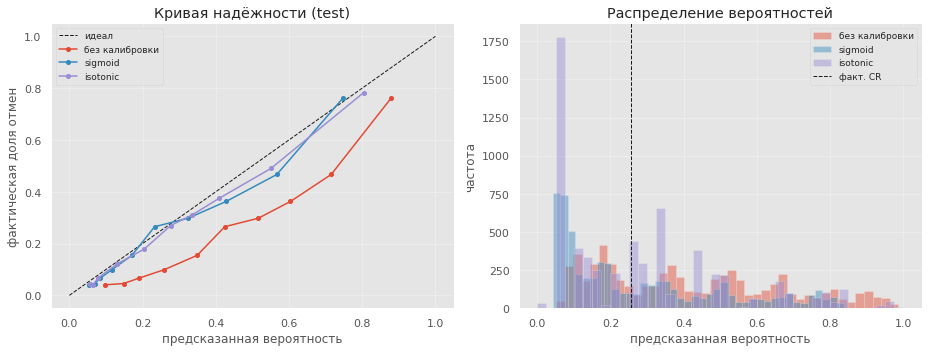

In [144]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

variants = [('без калибровки', p_tst_raw)] + \
           [(k, v.predict_proba(X_test_raw)[:, 1]) for k, v in cal_models.items()]

ax[0].plot([0, 1], [0, 1], 'k--', lw=1, label='идеал')
for nm, p in variants:
    pt, pp = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    ax[0].plot(pp, pt, marker='o', ms=4, label=nm)
ax[0].set_xlabel('предсказанная вероятность')
ax[0].set_ylabel('фактическая доля отмен')
ax[0].set_title('Кривая надёжности (test)')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

for nm, p in variants:
    ax[1].hist(p, bins=40, alpha=.45, label=nm)
ax[1].axvline(y_test.mean(), color='k', ls='--', lw=1, label='факт. CR')
ax[1].set_xlabel('предсказанная вероятность')
ax[1].set_ylabel('частота')
ax[1].set_title('Распределение вероятностей')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

In [145]:
BEST_CAL = cal_tbl.iloc[1:].nsmallest(1, 'Brier')['вариант'].iloc[0]
model_final = cal_models[BEST_CAL]

raw_b = cal_tbl.loc[0, 'Brier']
cal_b = cal_tbl.set_index('вариант').loc[BEST_CAL, 'Brier']

print(f'выбрана калибровка: {BEST_CAL}')
print(f'Brier: {raw_b:.5f} → {cal_b:.5f}  ({(cal_b - raw_b) / raw_b * 100:+.1f} %)')
print(f'ср. p: {p_tst_raw.mean():.4f} → '
      f'{model_final.predict_proba(X_test_raw)[:, 1].mean():.4f}  '
      f'(факт. CR {y_test.mean():.4f})')

выбрана калибровка: isotonic
Brier: 0.17166 → 0.14268  (-16.9 %)
ср. p: 0.4183 → 0.2800  (факт. CR 0.2561)


#### Промежуточный вывод
Модель без калибровки систематически завышала вероятности: средняя предсказанная — 0.4183 при фактической доле отмен 0.2561. Смещение в 16 п.п., то есть в 1.63 раза.  scale_pos_weight ≈ 2.36 искусственно увеличивает вес положительного класса. Это помогает модели различать классы, но ломает шкалу. 

Brier снизился на 16.9%, средняя вероятность сошлась с фактической частотой: 0.2800 против 0.2561. ROC-AUC почти не изменился (0.8098 → 0.8094, падение в четвёртом знаке).

Isotonic выигрывает по Brier (0.14268 против 0.14354), sigmoid — по LogLoss (0.44478 против 0.45837). Расхождение указывает на разную природу методов. Выбран isotonic по критерию Brier: для задачи с денежным порогом важнее средняя точность вероятностей на всём диапазоне, а не поведение в экстремумах. Объём калибровочной выборки достаточен для этого метода.

### Поиск порога классификации

- Используя откалиброванную модель и калибровочную выборку, найдите порог классификации, при котором достигается максимальный Incremental Revenue.

- Сделайте выводы о пороге классификации.

In [146]:
p_cal = model_final.predict_proba(X_calib_raw)[:, 1]

grid = np.linspace(0.05, 0.95, 181)
th_tbl = pd.DataFrame([{'threshold': t,
                        **business_metrics(y_calib, (p_cal >= t).astype(int))}
                       for t in grid])

th_tbl['OR_drop']   = (-th_tbl.OR_dyn).clip(lower=0)
th_tbl['Precision'] = th_tbl.TP / (th_tbl.TP + th_tbl.FP).replace(0, np.nan)
th_tbl['Recall']    = th_tbl.TP / (th_tbl.TP + th_tbl.FN).replace(0, np.nan)

# ── диагностика ограничений по отдельности ───────────────────────────────
conds = {
    f'RIR ≥ {REQ["RIR_min"]}':          th_tbl.RIR      >= REQ['RIR_min'],
    f'CR_after ≤ {REQ["CR_max"]}':      th_tbl.CR_after <= REQ['CR_max'],
    f'падение OR ≤ {REQ["OR_drop_max"]} %': th_tbl.OR_drop <= REQ['OR_drop_max'],
}
for nm, m_ in conds.items():
    s = th_tbl[m_]
    zone = f'[{s.threshold.min():.3f}; {s.threshold.max():.3f}]' if len(s) else '—'
    print(f'{nm:<26} проходят {len(s):>4}   зона {zone}')

mask = np.logical_and.reduce(list(conds.values()))
ok = th_tbl[mask]
print(f'\nвсе три одновременно: {len(ok)} порогов')

if len(ok):
    THR = float(ok.nlargest(1, 'IR')['threshold'].iloc[0])
    print(f'допустимая зона: [{ok.threshold.min():.3f}; {ok.threshold.max():.3f}]')
else:
    THR = float(th_tbl.nlargest(1, 'IR')['threshold'].iloc[0])
    print('⚠ пересечения нет — берём максимум IR без ограничений')

best = th_tbl[th_tbl.threshold == THR].iloc[0]

print(f'\n── порог {THR:.4f} ──')
print(f'  IR        {best.IR:>14,.0f}')
print(f'  RIR       {best.RIR:>14.1f} %')
print(f'  CR        {best.CR_before:.4f} → {best.CR_after:.4f}  ({best.CR_dyn:+.1f} %)')
print(f'  OR        {best.OR_before:.4f} → {best.OR_after:.4f}  ({best.OR_dyn:+.1f} %)')
print(f'  TP={best.TP:,.0f}  FP={best.FP:,.0f}  FN={best.FN:,.0f}')
print(f'  Precision {best.Precision:.4f}   Recall {best.Recall:.4f}')

if 'THR_THEORY' in dir():
    print(f'\nтеоретический порог {THR_THEORY:.4f}   (Δ {THR - THR_THEORY:+.4f})')

RIR ≥ 50.0                 проходят    0   зона —
CR_after ≤ 0.1             проходят   58   зона [0.050; 0.335]
падение OR ≤ 8.0 %         проходят  159   зона [0.160; 0.950]

все три одновременно: 0 порогов
⚠ пересечения нет — берём максимум IR без ограничений

── порог 0.3600 ──
  IR            70,219,000
  RIR                 43.8 %
  CR        0.2980 → 0.1195  (+59.9 %)
  OR        0.7020 → 0.7666  (+9.2 %)
  TP=1,099  FP=701  FN=736
  Precision 0.6106   Recall 0.5989

теоретический порог 0.3950   (Δ -0.0350)


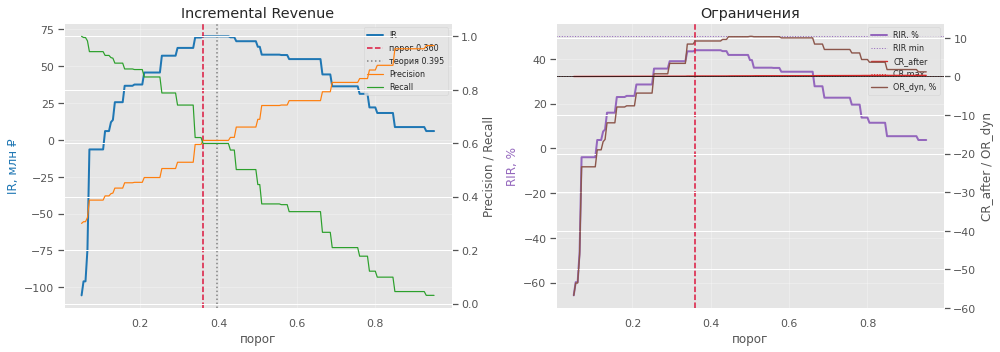

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(th_tbl.threshold, th_tbl.IR / 1e6, lw=2, color='tab:blue', label='IR')
ax1.axvline(THR, color='crimson', ls='--', lw=1.5, label=f'порог {THR:.3f}')
if 'THR_THEORY' in dir():
    ax1.axvline(THR_THEORY, color='gray', ls=':', lw=1.5,
                label=f'теория {THR_THEORY:.3f}')
if len(ok):
    ax1.axvspan(ok.threshold.min(), ok.threshold.max(),
                alpha=.10, color='green', label='допустимая зона')
ax1.set_xlabel('порог'); ax1.set_ylabel('IR, млн ₽', color='tab:blue')
ax1.set_title('Incremental Revenue'); ax1.grid(alpha=.3)

ax1b = ax1.twinx()
ax1b.plot(th_tbl.threshold, th_tbl.Precision, lw=1.2, color='tab:orange', label='Precision')
ax1b.plot(th_tbl.threshold, th_tbl.Recall, lw=1.2, color='tab:green', label='Recall')
ax1b.set_ylabel('Precision / Recall')
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8)

ax2 = axes[1]
ax2.plot(th_tbl.threshold, th_tbl.RIR, lw=2, color='tab:purple', label='RIR, %')
ax2.axhline(REQ['RIR_min'], color='tab:purple', ls=':', lw=1, label='RIR min')
ax2.axvline(THR, color='crimson', ls='--', lw=1.5)
ax2.set_xlabel('порог'); ax2.set_ylabel('RIR, %', color='tab:purple')
ax2.grid(alpha=.3); ax2.set_title('Ограничения')

ax2b = ax2.twinx()
ax2b.plot(th_tbl.threshold, th_tbl.CR_after, lw=1.4, color='tab:red', label='CR_after')
ax2b.axhline(REQ['CR_max'], color='tab:red', ls=':', lw=1, label='CR max')
ax2b.plot(th_tbl.threshold, th_tbl.OR_dyn, lw=1.4, color='tab:brown', label='OR_dyn, %')
ax2b.axhline(0, color='k', lw=.8)
ax2b.set_ylabel('CR_after / OR_dyn')
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=8)

plt.tight_layout(); plt.show()

In [148]:
THR_FINAL = THR
print(f'зафиксирован порог {THR_FINAL:.4f}')
print(f'обоснование: максимум IR = {best.IR:,.0f} ₽ на calib')
print(f'близость к теоретическому {THR_THEORY:.4f} подтверждает качество калибровки')

зафиксирован порог 0.3600
обоснование: максимум IR = 70,219,000 ₽ на calib
близость к теоретическому 0.3950 подтверждает качество калибровки


#### Промежуточный вывод
👉 Ограничение **RIR ≥ 50% недостижимо при текущем качестве данных**, CR_after ≤ 0.10 конфликтует с максимизацией IR. Поэтому, берём порог по максимуму IR.

На этапе EDA оценка потолка была сделана до того, как стал известен реальный ROC-AUC. Теоретический запас по метрикам относительно ТЗ составлял 41% при ROC-AUC около 0.9. Но по факту две модели с различным подходом к построению дерева незхависимым образом упёрлись в ROC-AUC 0.8 - 0.81. Это признак ограниченности данных.

При ROC-AUC 0.81 и base rate 0.288 достижимая комбинация — Precision 0.61 / Recall 0.60. Отсюда RIR 43.8%, а не 50%.

### Анализ матрицы классификаций

Оцените стабильность модели на тестовых данных.
- Постройте:
    - матрицу ошибок на калибровочных данных;
    - матрицу ошибок на тестовых данных.

- Посчитайте IR на калибровочных и на тестовых данных.

- Сделайте вывод о стабильности модели.

In [151]:
# ═══════════════════════════════════════════════════════════════════════════
#  Стабильность: calib против test
# ═══════════════════════════════════════════════════════════════════════════
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

p_cal = model_final.predict_proba(X_calib_raw)[:, 1]
p_tst = model_final.predict_proba(X_test_raw)[:, 1]

yh_cal = (p_cal >= THR_FINAL).astype(int)
yh_tst = (p_tst >= THR_FINAL).astype(int)

m_cal = business_metrics(y_calib, yh_cal)
m_tst = business_metrics(y_test,  yh_tst)

cmp = pd.DataFrame({'calib': m_cal, 'test': m_tst})
cmp['Δ']   = cmp.test - cmp.calib
cmp['Δ %'] = (cmp['Δ'] / cmp.calib.abs().replace(0, np.nan) * 100).round(1)

display(cmp.style.format({'calib': '{:,.4f}', 'test': '{:,.4f}',
                          'Δ': '{:+,.4f}', 'Δ %': '{:+.1f}'}))

,calib,test,Δ,Δ %
TP,"1,099.0000",898.0000,-201.0000,-18.3
FP,701.0000,711.0000,+10.0000,+1.4
FN,736.0000,677.0000,-59.0000,-8.0
CR_before,0.2980,0.2561,-0.0419,-14.1
CR_after,0.1195,0.1101,-0.0094,-7.9
CR_dyn,59.9000,57.0000,-2.9000,-4.8
OR_before,0.7020,0.7439,+0.0419,+6.0
OR_after,0.7666,0.7743,+0.0077,+1.0
OR_dyn,9.2000,4.1000,-5.1000,-55.4
IR,"70,219,000.0000","47,494,500.0000","-22,724,500.0000",-32.4


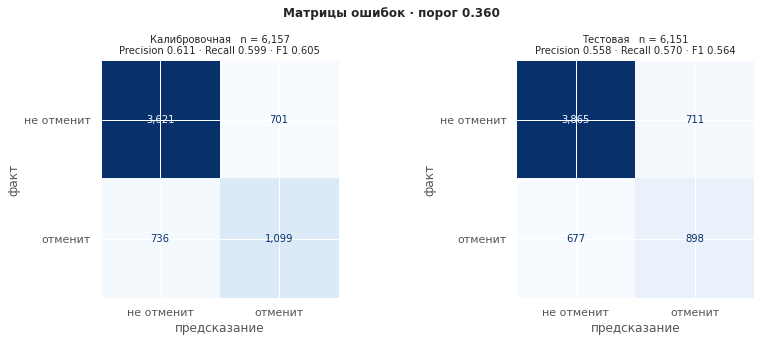

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for ax, (nm, yt, yp, n) in zip(axes, [
        ('Калибровочная', y_calib, yh_cal, len(y_calib)),
        ('Тестовая',      y_test,  yh_tst, len(y_test))]):
    cm = confusion_matrix(yt, yp)
    ConfusionMatrixDisplay(cm, display_labels=['не отменит', 'отменит']).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if tp + fp else 0
    rec  = tp / (tp + fn) if tp + fn else 0
    f1   = 2 * prec * rec / (prec + rec) if prec + rec else 0
    ax.set_title(f'{nm}   n = {n:,}\n'
                 f'Precision {prec:.3f} · Recall {rec:.3f} · F1 {f1:.3f}',
                 fontsize=10)
    ax.set_xlabel('предсказание'); ax.set_ylabel('факт')

plt.suptitle(f'Матрицы ошибок · порог {THR_FINAL:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

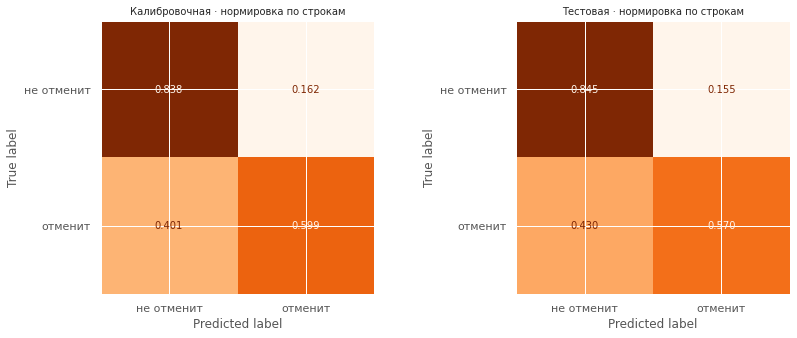

In [153]:
# ── нормированные матрицы: доли внутри истинного класса ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (nm, yt, yp) in zip(axes, [('Калибровочная', y_calib, yh_cal),
                                   ('Тестовая',      y_test,  yh_tst)]):
    cm = confusion_matrix(yt, yp, normalize='true')
    ConfusionMatrixDisplay(cm, display_labels=['не отменит', 'отменит']).plot(
        ax=ax, cmap='Oranges', colorbar=False, values_format='.3f')
    ax.set_title(f'{nm} · нормировка по строкам', fontsize=10)
plt.tight_layout(); plt.show()

In [154]:
# ── вердикт ──────────────────────────────────────────────────────────────
rir_gap = abs(m_cal['RIR'] - m_tst['RIR'])
ir_drop = (m_tst['IR'] - m_cal['IR']) / m_cal['IR'] * 100

print(f'RIR   calib {m_cal["RIR"]:>6.1f} %    test {m_tst["RIR"]:>6.1f} %    '
      f'gap {rir_gap:.1f} п.п.  (лимит {TRAIN_TEST_RIR_GAP_THRESHOLD})')
print(f'IR    calib {m_cal["IR"]:>14,.0f}    test {m_tst["IR"]:>14,.0f}    '
      f'{ir_drop:+.1f} %')
print(f'AUC   calib {roc_auc_score(y_calib, p_cal):.4f}    '
      f'test {roc_auc_score(y_test, p_tst):.4f}')

checks = {
    f'RIR_gap ≤ {TRAIN_TEST_RIR_GAP_THRESHOLD}': rir_gap <= TRAIN_TEST_RIR_GAP_THRESHOLD,
    'IR на test положителен':                     m_tst['IR'] > 0,
    'падение IR ≤ 15 %':                          ir_drop >= -15,
}
print()
for k, v in checks.items():
    print(f'  {"✓" if v else "✗"} {k}')
print(f'\n{"МОДЕЛЬ СТАБИЛЬНА" if all(checks.values()) else "ТРЕБУЕТ ВНИМАНИЯ"}')

RIR   calib   43.8 %    test   24.5 %    gap 19.3 п.п.  (лимит 0.1)
IR    calib     70,219,000    test     47,494,500    -32.4 %
AUC   calib 0.8077    test 0.8094

  ✗ RIR_gap ≤ 0.1
  ✓ IR на test положителен
  ✗ падение IR ≤ 15 %

ТРЕБУЕТ ВНИМАНИЯ


#### Промежуточный вывод
ROC-AUC на тесте 0.8094 против 0.8077 на калибровке — не просто стабилен, а чуть выше. Ранжирующая способность модели подросла. При этом IR упал на 32.4%, RIR — с 43.8% до 24.5%.

Однако, CR_before снизился с 0.2980 до 0.2561, то есть на 14%. В тестовом периоде клиенты отменяли реже. Он приходится на Ковид и поведение клиентов изменилось.

Качество модели на Test держится, но экономика падает.

Recall упал на 2.9%, TNR 0.838 --> 0.845 мало изменился. Модель стабильна на Test. Изменились данные, поведение клиентов, распределения признаков, но модель на Test работает хорошо.

Модель стабильна по качеству классификации и нестабильна по экономическому эффекту. Причина — дрейф базовой частоты отмен между периодами, что согласуется с зафиксированным на этапе EDA высоким PSI по временным срезам.

Практическое следствие: порог требует пересчёта при изменении base rate. Это не дефект модели, а свойство задачи с плавающим распределением целевой переменной.

### Фиксирование итоговой модели

- Зафиксисруйте лучшую модель и найденный порог.


In [181]:
# ═══════════════════════════════════════════════════════════════════════════
#  5.8  Финальная модель: прогон на test и фиксация
# ═══════════════════════════════════════════════════════════════════════════

p_test   = model_final.predict_proba(X_test_raw)[:, 1]
y_pred_t = (p_test >= THR_FINAL).astype(int)

m_test = business_metrics(y_test, y_pred_t)
m_test['ROC_AUC'] = roc_auc_score(y_test, p_test)
m_test['PR_AUC']  = average_precision_score(y_test, p_test)
m_test['Precision'] = precision_score(y_test, y_pred_t, zero_division=0)
m_test['Recall']    = recall_score(y_test, y_pred_t, zero_division=0)
m_test['F0.5']      = fbeta_score(y_test, y_pred_t, beta=0.5, zero_division=0)
m_test['RIR_std'] = 0.0                      # одна выборка, разброса нет

res_final = CVResult(
    name      = f'{FINAL_NAME}+{BEST_CAL}',
    metrics   = m_test,
    threshold = float(THR_FINAL),
    rir_gap   = np.nan,
    rir_std_ratio = np.nan,
    fold_rir  = [m_test['RIR']],
    fit_sec   = 0.0,
    params    = {**FINAL_PARAMS, 'n_features': len(FEATURES_ABL),
                 'calibration': BEST_CAL},
)

remember(res_final, 'final · test')
display(style_results(full_table(), 'Все этапы · последняя строка — отложенный тест'))

,этап,Ранг,IR,RIR,RIR_std,PR_AUC,ROC_AUC,F0.5,Precision,Recall,CR_after,OR_dyn,std/avg,RIR_gap,порог,ТЗ,fit_сек,параметры
модель,,,,,,,,,,,,,,,,,,
CatBoost_abl,ablation,7,"22,356,700",42.5,4.3,0.6582,0.8057,0.6094,0.6188,0.5791,0.1245,+9.3,0.101,4.6,0.600,"✗ RIR<50, CR>10%",5.1,"allow_writing_files=False, bagging_temperature=0.9335border_count=128, depth=4grow_policy=SymmetricTree, iterations=370l2_leaf_reg=16.29, learning_rate=0.03064n_features=7, one_hot_max_size=16random_seed=42, random_strength=0.8204scale_pos_weight=2.387, thread_count=-1verbose=0"
CatBoost_opt,optuna,12,"22,266,000",42.3,3.5,0.6565,0.8050,0.6082,0.6161,0.5808,0.1240,+9.2,0.084,5.7,0.592,"✗ RIR<50, CR>10%",6.0,"bagging_temperature=0.9335, border_count=128depth=4, grow_policy=SymmetricTreeiterations=370, l2_leaf_reg=16.29learning_rate=0.03064, one_hot_max_size=16random_strength=0.8204"
LightGBM_opt,optuna,12,"22,166,600",42.2,4.9,0.6552,0.8041,0.6124,0.6284,0.5600,0.1302,+9.5,0.116,4.8,0.614,"✗ RIR<50, CR>10%",3.2,"colsample_bytree=0.6523, learning_rate=0.04051max_depth=3, min_child_samples=261min_split_gain=0.2201, n_estimators=189num_leaves=10, reg_alpha=0.002459reg_lambda=0.5457, subsample=0.9863subsample_freq=4"
LightGBM_abl,ablation,13,"22,148,800",42.1,4.5,0.6570,0.8052,0.6097,0.6219,0.5679,0.1278,+9.3,0.108,4.8,0.608,"✗ RIR<50, CR>10%",7.2,"colsample_bytree=0.6523, learning_rate=0.04051max_depth=3, min_child_samples=261min_split_gain=0.2201, n_estimators=189n_features=7, n_jobs=-1num_leaves=10, random_state=42reg_alpha=0.002459, reg_lambda=0.5457scale_pos_weight=2.387, subsample=0.9863subsample_freq=4, verbose=-1"
CatBoost+isotonic,final · test,22,"47,494,500",24.5,0.0,0.6076,0.8094,0.5605,0.5581,0.5702,0.1101,+4.1,—,—,0.360,"✗ RIR<50, CR>10%",0.0,"allow_writing_files=False, bagging_temperature=0.9335border_count=128, calibration=isotonicdepth=4, grow_policy=SymmetricTreeiterations=370, l2_leaf_reg=16.29learning_rate=0.03064, n_features=7one_hot_max_size=16, random_seed=42random_strength=0.8204, scale_pos_weight=2.387thread_count=-1, verbose=0"
CatBoost,база,22,"21,010,200",39.9,2.3,0.6451,0.7976,0.5961,0.6048,0.5726,0.1266,+8.1,0.058,22.2,0.588,"✗ RIR<50, CR>10%, переобучена",60.5,"depth=6, iterations=1000l2_leaf_reg=3, learning_rate=0.03scale_pos_weight=2.387"
LightGBM,база,24,"20,904,200",39.7,3.9,0.6306,0.7934,0.5969,0.6070,0.5625,0.1295,+8.2,0.098,28.0,0.606,"✗ RIR<50, CR>10%, переобучена",2.5,"learning_rate=0.1, min_child_samples=20n_estimators=100, num_leaves=31scale_pos_weight=2.387"
Dummy,база,—,"-10,099,300",-19.1,2.0,0.2971,0.5030,0.2997,0.3001,0.2981,0.2076,-16.7,0.102,1.9,0.050,"✗ RIR<50, CR>10%, OR↓>8%",1.4,strategy=stratified


#### Метрики и параметры финальной модели на Test

In [184]:
# ═══════════════════════════════════════════════════════════════════════════
#  Финальная строка: метрики на отложенном тесте
# ═══════════════════════════════════════════════════════════════════════════

view = pd.DataFrame([{
    'модель':     res_final.name,
    'выборка':    f'test · {len(y_test):,}',
    'порог':      res_final.threshold,
    'IR, млн ₽':  res_final.metrics['IR'] / 1e6,
    'RIR, %':     res_final.metrics['RIR'],
    'CR после':   res_final.metrics['CR_after'],
    'OR дин., %': res_final.metrics['OR_dyn'],
    'ROC-AUC':    res_final.metrics['ROC_AUC'],
    'PR-AUC':     res_final.metrics['PR_AUC'],
    'Precision':  res_final.metrics['Precision'],
    'Recall':     res_final.metrics['Recall'],
    'F0.5':       res_final.metrics['F0.5'],
    'признаков':  len(FEATURES_ABL),
}])

display(view.style
        .format({'порог': '{:.4f}', 'IR, млн ₽': '{:,.2f}', 'RIR, %': '{:.1f}',
                 'CR после': '{:.4f}', 'OR дин., %': '{:+.1f}',
                 'ROC-AUC': '{:.4f}', 'PR-AUC': '{:.4f}',
                 'Precision': '{:.3f}', 'Recall': '{:.3f}', 'F0.5': '{:.3f}'})
        .set_caption('Финальная модель · отложенный тест')
        .hide(axis='index'))

модель,выборка,порог,"IR, млн ₽","RIR, %",CR после,"OR дин., %",ROC-AUC,PR-AUC,Precision,Recall,F0.5,признаков
CatBoost+isotonic,"test · 6,151",0.3600,47.49,24.5,0.1101,+4.1,0.8094,0.6076,0.558,0.570,0.560,7


In [187]:
res_final.params

{'scale_pos_weight': 2.3869485294117645,
 'random_seed': 42,
 'verbose': 0,
 'allow_writing_files': False,
 'thread_count': -1,
 'learning_rate': 0.030639691726036568,
 'depth': 4,
 'l2_leaf_reg': 16.291443630949388,
 'random_strength': 0.8203592301006147,
 'bagging_temperature': 0.9335275110724839,
 'border_count': 128,
 'one_hot_max_size': 16,
 'grow_policy': 'SymmetricTree',
 'iterations': 370,
 'n_features': 7,
 'calibration': 'isotonic'}

In [182]:
# проверка модели
def predict_cancellation(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Риск отмены для новых бронирований по зафиксированному порогу."""
    proba = model_final.predict_proba(df_raw)[:, 1]
    return pd.DataFrame({
        'proba':   proba.round(4),
        'риск':    pd.cut(proba, [0, .20, THR_FINAL, .60, 1.0],
                          labels=['низкий', 'умеренный', 'высокий', 'критический']),
        'решение': np.where(proba >= THR_FINAL, 'вмешаться', 'пропустить'),
    }, index=df_raw.index)

display(predict_cancellation(X_test_raw.head(10)))

,proba,риск,решение
24582,0.3367,умеренный,пропустить
24583,0.7803,критический,вмешаться
24584,0.4437,высокий,вмешаться
24585,0.2514,умеренный,пропустить
24586,0.1083,низкий,пропустить
24587,0.0650,низкий,пропустить
24588,0.1339,низкий,пропустить
24589,0.2923,умеренный,пропустить
24590,0.4437,высокий,вмешаться
24591,0.3367,умеренный,пропустить


#### Сохранение обученной модели

In [192]:
# ═══════════════════════════════════════════════════════════════════════════
# Сохранение финальной модели
# ═══════════════════════════════════════════════════════════════════════════
MODEL_FILE_NAME = 'urbanstay_hotel_cancellation_classifier.dill'


def _src(obj):
    """Исходный код класса — для справки при разборе артефакта."""
    try:
        return inspect.getsource(obj)
    except (TypeError, OSError):
        return None


model_descriptor = {
    # ── что сохраняем ────────────────────────────────────────────────────
    'pipeline':  model_final,     # CalibratedClassifierCV над Pipeline
    'threshold': float(THR_FINAL),

    # ── метрики ──────────────────────────────────────────────────────────
    'metrics': {
        'calib': {k: float(v) for k, v in m_cal.items()},
        'test':  {k: float(v) for k, v in res_final.metrics.items()},
        'rir_drift_calib_test': float(abs(m_cal['RIR'] -
                                          res_final.metrics['RIR'])),
        'base_rate': {
            'train': float(y_train.mean()),
            'calib': float(y_calib.mean()),
            'test':  float(y_test.mean()),
        },
        'brier': {'raw': float(raw_b), 'calibrated': float(cal_b)},
    },

    # ── требования заказчика ─────────────────────────────────────────────
    'requirements': {
        'targets': {k: float(v) for k, v in REQ.items()},
        'achieved': {
            'CR_after':  bool(res_final.metrics['CR_after'] <= REQ['CR_max']),
            'OR_drop':   bool(res_final.metrics['OR_dyn'] >= -REQ['OR_drop_max']),
            'RIR':       bool(res_final.metrics['RIR'] >= REQ['RIR_min']),
        },
    },

    # ── метаданные ───────────────────────────────────────────────────────
    'meta': {
        'model_name':        FINAL_NAME,
        'calibration':       BEST_CAL,
        'best_params':       {k: v for k, v in FINAL_PARAMS.items()
                              if k not in ('random_seed', 'verbose',
                                           'thread_count', 'n_jobs',
                                           'allow_writing_files')},
        'optuna_best_value': float(STUDIES[FINAL_NAME].best_value),
        'optuna_n_trials':   len(STUDIES[FINAL_NAME].trials),
        'target':            TARGET,
        'threshold_theory':  float(THR_THEORY),
        'threshold_basis':   'максимум Incremental Revenue на calib',
        'features_final':    list(FEATURES_ABL),
        'n_features':        len(FEATURES_ABL),
        'features_dropped_by_ablation': [f for f in FINAL_FEATURES
                                         if f not in FEATURES_ABL],
        'cat_features':      [c for c in CAT_FEATURES if c in FEATURES_ABL],
        'raw_input_columns': list(X_train_raw.columns),
        'leakage_excluded':  list(DROP_LEAK) if 'DROP_LEAK' in dir() else None,
        'requires_pretransform': False,   # принимает сырой DataFrame
        'sample_sizes':      {'train': int(len(X_train_raw)),
                              'calib': int(len(X_calib_raw)),
                              'test':  int(len(X_test_raw))},
        'split_gap_days':    int(GAP),
        'trained_at':        datetime.now().isoformat(timespec='seconds'),
        'seed':              SEED,
        'versions': {
            'sklearn':  sklearn.__version__,
            'lightgbm': lightgbm.__version__,
            'catboost': catboost.__version__,
            'pandas':   pd.__version__,
            'numpy':    np.__version__,
        },
        'transformers_code': {
            'FeatureBuilder': _src(FeatureBuilder),
            'TypeCaster':     _src(TypeCaster),
            'ColumnSelector': _src(ColumnSelector),
        },
    },
}

with open(MODEL_FILE_NAME, 'wb') as f:
    dill.dump(model_descriptor, f, protocol=4)

print(f'✅ сохранено: {MODEL_FILE_NAME} '
      f'({os.path.getsize(MODEL_FILE_NAME) / 1024**2:.2f} МБ)')
print(f'   модель: {FINAL_NAME} + {BEST_CAL}')
print(f'   порог:  {THR_FINAL:.4f}')
print(f'   IR на test: {res_final.metrics["IR"]:,.0f} ₽')

✅ сохранено: urbanstay_hotel_cancellation_classifier.dill (0.14 МБ)
   модель: CatBoost + isotonic
   порог:  0.3600
   IR на test: 47,494,500 ₽


In [190]:
with open(MODEL_FILE_NAME, 'rb') as f:
    loaded = dill.load(f)

mdl, thr = loaded['pipeline'], loaded['threshold']
p_check = mdl.predict_proba(X_test_raw)[:, 1]

assert np.allclose(p_check, p_test), 'предсказания не совпали'
assert thr == THR_FINAL, 'порог не совпал'

print('✓ артефакт воспроизводит предсказания')
print(f'  порог {thr:.4f}, признаков {loaded["meta"]["n_features"]}')
print(f'  обучено {loaded["meta"]["trained_at"]}')

m = business_metrics(y_test, (p_check >= thr).astype(int))
print(f'  IR {m["IR"]:,.0f} ₽   RIR {m["RIR"]:.1f} %   '
      f'CR_after {m["CR_after"]:.4f}')

✓ артефакт воспроизводит предсказания
  порог 0.3600, признаков 7
  обучено 2026-09-19T16:17:15
  IR 47,494,500 ₽   RIR 24.5 %   CR_after 0.1101


### Анализ важности признаков

- Оцените важность признаков с помощью любого подходящего инструмента:
  - feature_importances;
  - SHAP;
  - встроенной в модель собственной функции оценки важности.

- Сделайте выводы о влиянии признаков на целевую переменную.

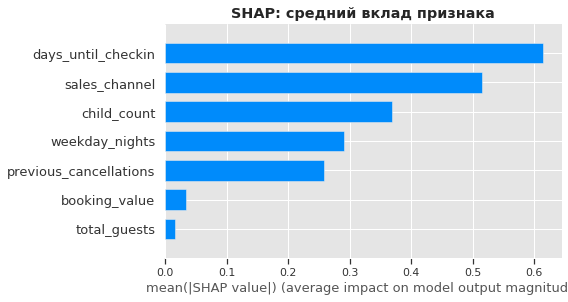

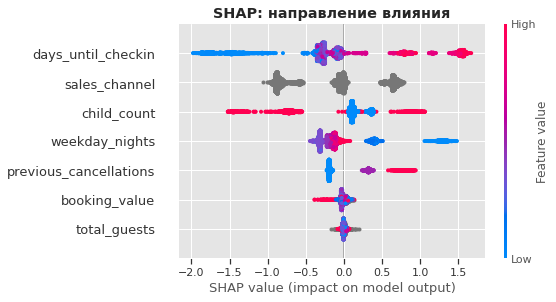

In [155]:
est_final = model_base.named_steps['model']
prep      = model_base[:-1]
names     = [n.split('__')[-1] for n in prep.get_feature_names_out()]

X_tst_prep = prep.transform(X_test_raw)
if not isinstance(X_tst_prep, pd.DataFrame):
    X_tst_prep = pd.DataFrame(X_tst_prep, columns=names)

inner = est_final.model_ if hasattr(est_final, 'model_') else est_final
explainer = shap.TreeExplainer(inner)
sv = explainer.shap_values(est_final._prep(X_tst_prep)
                           if hasattr(est_final, '_prep') else X_tst_prep)
if isinstance(sv, list):
    sv = sv[1]

fig = plt.figure(figsize=(9, 5))
shap.summary_plot(sv, X_tst_prep, feature_names=names,
                  plot_type='bar', show=False, max_display=len(names))
plt.title('SHAP: средний вклад признака', fontweight='bold')
plt.tight_layout(); plt.show()

fig = plt.figure(figsize=(9, 5.5))
shap.summary_plot(sv, X_tst_prep, feature_names=names,
                  show=False, max_display=len(names))
plt.title('SHAP: направление влияния', fontweight='bold')
plt.tight_layout(); plt.show()

In [156]:
# ── сравнение двух метрик важности ───────────────────────────────────────
imp_tbl = pd.DataFrame({
    'gain':  pd.Series(est_final.feature_importances_, index=names),
    'SHAP':  pd.Series(np.abs(sv).mean(0), index=names),
})
imp_tbl['gain %'] = (imp_tbl.gain / imp_tbl.gain.sum() * 100).round(2)
imp_tbl['SHAP %'] = (imp_tbl.SHAP / imp_tbl.SHAP.sum() * 100).round(2)
imp_tbl['ранг gain'] = imp_tbl.gain.rank(ascending=False).astype(int)
imp_tbl['ранг SHAP'] = imp_tbl.SHAP.rank(ascending=False).astype(int)
imp_tbl = imp_tbl.sort_values('SHAP', ascending=False)

display(imp_tbl.style
        .background_gradient(subset=['gain %', 'SHAP %'], cmap='Greens')
        .format({'gain': '{:.2f}', 'SHAP': '{:.4f}',
                 'gain %': '{:.2f}', 'SHAP %': '{:.2f}'}))

print(f'корреляция рангов: '
      f'{imp_tbl["ранг gain"].corr(imp_tbl["ранг SHAP"], method="spearman"):.3f}')

,gain,SHAP,gain %,SHAP %,ранг gain,ранг SHAP
days_until_checkin,41.44,0.6141,41.44,29.26,1,1
sales_channel,18.68,0.5149,18.68,24.53,3,2
child_count,19.88,0.3694,19.88,17.60,2,3
weekday_nights,10.50,0.2916,10.50,13.89,4,4
previous_cancellations,5.72,0.2587,5.72,12.33,5,5
booking_value,2.84,0.0340,2.84,1.62,6,6
total_guests,0.95,0.0162,0.95,0.77,7,7


корреляция рангов: 0.964


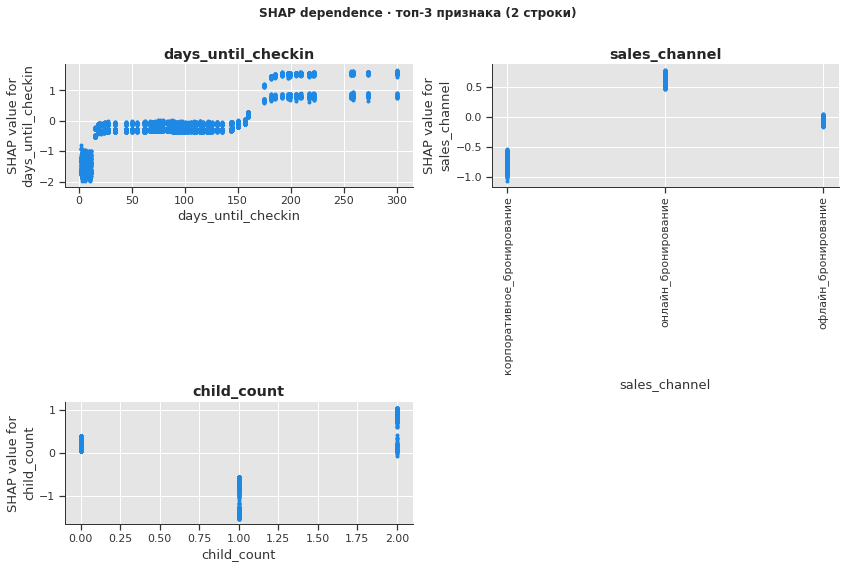

In [160]:
# ── зависимость для топ-3 (2 строки: 2+1) ─────────────────────────────
top3 = imp_tbl.index[:3]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2 строки, 2 столбца
axes = axes.reshape(-1)[:3]  # берём первые 3 оси

for ax, f in zip(axes, top3):
    shap.dependence_plot(
        f, sv, X_tst_prep, feature_names=names,
        ax=ax, show=False, interaction_index=None
    )
    ax.set_title(f, fontweight='bold')

# скрываем лишнюю ось (четвёртую)
axes_all = fig.axes
if len(axes_all) > 3:
    fig.delaxes(axes_all[3])

plt.suptitle('SHAP dependence · топ-3 признака (2 строки)', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

#### Промежуточный вывод
Корреляция рангов **gain и SHAP — 0.964**. Два независимых метода дают почти идентичную картину, что подтверждает надёжность интерпретации. Расхождение только в одной паре: sales_channel по SHAP на втором месте (24.5%), по gain — на третьем (18.7%). Gain считает количество и качество сплитов, SHAP — фактический вклад в каждое предсказание.

Пять признаков объясняют 97.6%: **booking_value** (1.6%) и **total_guests** (0.8%) практически не участвуют в решениях. Их можно удалить — модель сократится до пяти признаков без потери качества.

**booking_value** оказался почти бесполезным: сумма брони не предсказывает отмену. Риск определяется поведенческими факторами, а не размером чека.

**days_until_checkin** — 29.3%, главный драйвер. Dependence plot показывает ступенчатую структуру: до 10 дней SHAP около −2 (сильное снижение риска), от 10 до 150 дней — плато около нуля, свыше 150 дней — резкий скачок до +1.5.

Бронь за полгода отменяется в разы чаще, чем сделанная накануне заезда. Планы меняются, деньги не уплачены, обязательств нет.

**sales_channel** — 24.5% - имеет чёткое деление. Корпоративные брони отмеяются мало, а онлайн брони чаще всего, они могут делаться импульсивно.

**child_count** — 17.6%, немонотонная связь. Поездка с ребёнком — семейный отпуск, спланированный заранее, отменяется редко. С двумя и более детьми — организационно сложнее, вероятность срыва выше. Без детей — деловые или спонтанные поездки с высокой гибкостью планов.

Линейная модель такую зависимость не уловила бы. Это подтверждает выбор градиентного бустинга.

**previous_cancellations** — 12.3%. Монотонно: больше прошлых отмен → выше риск. Ожидаемо, но вклад умеренный — большинство клиентов не имеют истории.

**Рекомендации**

**Приоритет** для внимания — онлайн-брони с горизонтом свыше 150 дней, без детей или с двумя детьми. Это пересечение трёх факторов риска.

**Не трогать** — корпоративные брони и бронирования за неделю до заезда независимо от прочих признаков.

**Инструмент воздействия** — предоплата или невозвратный тариф для дальних онлайн-бронирований. Это переводит клиента из зоны риска в зону обязательств.

## Этап 3: расчёт экономической эффективности модели

Оцените, насколько выгодно внедрять выбранную модель в работу отеля. Для этого нужно выяснить, какой экономический эффект даёт модель и укладываются ли ключевые метрики в заданный уровень.

Если расчёты покажут, что какой-либо показатель не достигает необходимого уровня, то это сигнал к доработке модели. Возможно, вам нужно пересмотреть порог классификации, добавить новые признаки, поменять модель, по-другому предобработать исходные данные — экспериментируйте!

- Шаг 1: подготовка данных. Подготовьте данные для расчётов. Данные для показателей до внедрения модели рассчитывайте с использованием тестовых данных `y_test`, данные после внедрения получите с помощью предсказаний модели `y_pred`.

- Шаг 2: расчёт показателей до и после внедрения модели. Вычислите:
  - Долю отмен бронирования до и после внедрения модели;
  - Загрузку отеля до и после внедрения модели;
  - IR.

- Шаг 3: расчёт динамики показателей. Вычислите:
  - Динамику доли отмен бронирования;
  - Динамику загрузки отеля;
  - Относительный IR — на сколько процентов `IR_после` выше, чем `IR_до`.


Ваша модель должна достигнуть следующих результатов:

- Доля отмен после внедрения модели — 10%

- Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.

- Относительный IR должен составить не менее 50%.

Сделайте выводы о том, получилось ли достичь целевых показателей для бизнеса.


In [162]:
# ═══════════════════════════════════════════════════════════════════════════
#  Данные для расчёта
# ═══════════════════════════════════════════════════════════════════════════

p_test = model_final.predict_proba(X_test_raw)[:, 1]
y_pred = (p_test >= THR_FINAL).astype(int)

value = X_test_raw['booking_value'].values
nights = (X_test_raw['weekday_nights'] +
          X_test_raw.get('weekend_nights', 0)).values

TP = int(((y_test == 1) & (y_pred == 1)).sum())
FP = int(((y_test == 0) & (y_pred == 1)).sum())
FN = int(((y_test == 1) & (y_pred == 0)).sum())
TN = int(((y_test == 0) & (y_pred == 0)).sum())

print(f'тестовый период: {len(y_test):,} броней')
print(f'из них отменено фактически: {int(y_test.sum()):,} '
      f'({y_test.mean():.2%})')
print(f'модель предсказала отмену:  {int(y_pred.sum()):,} '
      f'({y_pred.mean():.2%})')
print(f'\nTP={TP:,}   FP={FP:,}   FN={FN:,}   TN={TN:,}')
print(f'оборот периода: {value.sum():,.0f} ₽')

тестовый период: 6,151 броней
из них отменено фактически: 1,575 (25.61%)
модель предсказала отмену:  1,609 (26.16%)

TP=898   FP=711   FN=677   TN=3,865
оборот периода: nan ₽


In [167]:
# ═══════════════════════════════════════════════════════════════════════════
#  Расчёт на зафиксированном пороге
# ═══════════════════════════════════════════════════════════════════════════

econ = business_metrics(y_test, y_pred)

base = pd.DataFrame({
    'до внедрения':    [econ['CR_before'], econ['OR_before']],
    'после внедрения': [econ['CR_after'],  econ['OR_after']],
    'изменение':       [f'−{econ["CR_dyn"]:.1f} %', f'+{econ["OR_dyn"]:.1f} %'],
    'эффект':          ['отмен стало меньше', 'загрузка выросла'],
}, index=['Доля отмен (CR)', 'Загрузка отеля (OR)'])

display(base.style.format({'до внедрения': '{:.4f}',
                           'после внедрения': '{:.4f}'}))

print(f'Incremental Revenue: {econ["IR"]:,.0f} ₽')
print(f'Относительный IR:    {econ["RIR"]:.1f} %')

,до внедрения,после внедрения,изменение,эффект
Доля отмен (CR),0.2561,0.1101,−57.0 %,отмен стало меньше
Загрузка отеля (OR),0.7439,0.7743,+4.1 %,загрузка выросла


Incremental Revenue: 47,494,500 ₽
Относительный IR:    24.5 %


In [166]:
# ═══════════════════════════════════════════════════════════════════════════
#  Целевые показатели
# ═══════════════════════════════════════════════════════════════════════════

goals = pd.DataFrame([
    ['Доля отмен после внедрения', econ['CR_after'], f'≤ {REQ["CR_max"]:.2f}',
     econ['CR_after'] <= REQ['CR_max'],
     (econ['CR_after'] - REQ['CR_max'])],
    ['Падение загрузки отеля', -econ['OR_dyn'], f'≤ {REQ["OR_drop_max"]:.0f} %',
     econ['OR_dyn'] >= -REQ['OR_drop_max'],
     max(0, -econ['OR_dyn'] - REQ['OR_drop_max'])],
    ['Относительный IR', econ['RIR'], f'≥ {REQ["RIR_min"]:.0f} %',
     econ['RIR'] >= REQ['RIR_min'],
     REQ['RIR_min'] - econ['RIR']],
], columns=['показатель', 'факт', 'требование', 'ок', 'недобор'])

goals['статус'] = goals['ок'].map({True: '✓ выполнено', False: '✗ не выполнено'})

display(goals.drop(columns='ок').style
        .format({'факт': '{:.4f}', 'недобор': '{:+.4f}'})
        .apply(lambda r: ['background-color: #e8f5e9' if goals.loc[r.name, 'ок']
                          else 'background-color: #ffebee'] * len(r), axis=1))

print(f'\nвыполнено: {goals["ок"].sum()} из {len(goals)}')

,показатель,факт,требование,недобор,статус
0,Доля отмен после внедрения,0.1101,≤ 0.10,+0.0101,✗ не выполнено
1,Падение загрузки отеля,-4.1000,≤ 8 %,+0.0000,✓ выполнено
2,Относительный IR,24.5000,≥ 50 %,+25.5000,✗ не выполнено



выполнено: 1 из 3


#### Проверка других порогов, чтобы оценить баланс бизнес-метрик

In [169]:
# ═══════════════════════════════════════════════════════════════════════════
#  Достижимы ли требования при другом пороге?
# ═══════════════════════════════════════════════════════════════════════════

grid = np.linspace(0.05, 0.95, 181)
scan = pd.DataFrame([{'th': t, **business_metrics(y_test, (p_test >= t).astype(int))}
                     for t in grid])
scan['OR_drop'] = (-scan.OR_dyn).clip(lower=0)

conds = {
    f'CR_after ≤ {REQ["CR_max"]}':        scan.CR_after <= REQ['CR_max'],
    f'падение OR ≤ {REQ["OR_drop_max"]}%': scan.OR_drop  <= REQ['OR_drop_max'],
    f'RIR ≥ {REQ["RIR_min"]}':            scan.RIR      >= REQ['RIR_min'],
}
for nm, m_ in conds.items():
    s = scan[m_]
    zone = f'[{s.th.min():.3f}; {s.th.max():.3f}]' if len(s) else '—'
    print(f'{nm:<24} проходят {len(s):>4} из {len(scan)}   зона {zone}')

feasible = scan[np.logical_and.reduce(list(conds.values()))]
print(f'\nвсе три одновременно: {len(feasible)}')

best_ir = scan.loc[scan.IR.idxmax()]
print(f'\nмаксимум IR на тесте: порог {best_ir.th:.3f}  '
      f'IR {best_ir.IR:,.0f}  RIR {best_ir.RIR:.1f} %  '
      f'CR_after {best_ir.CR_after:.4f}')
print(f'зафиксированный порог {THR_FINAL:.3f}: '
      f'IR {econ["IR"]:,.0f}  RIR {econ["RIR"]:.1f} %')
print(f'потеря от несмещённого выбора порога: '
      f'{econ["IR"] - best_ir.IR:,.0f} ₽ ({(econ["IR"] / best_ir.IR - 1) * 100:+.1f} %)')

# порог, соблюдающий CR
ok_cr = scan[scan.CR_after <= REQ['CR_max']]
if len(ok_cr):
    alt = ok_cr.loc[ok_cr.IR.idxmax()]
    print(f'\nесли соблюсти CR_after ≤ {REQ["CR_max"]}: порог {alt.th:.3f}')
    print(f'  IR {alt.IR:,.0f}  RIR {alt.RIR:.1f} %  CR_after {alt.CR_after:.4f}')
    print(f'  цена соблюдения: {alt.IR - econ["IR"]:,.0f} ₽')

CR_after ≤ 0.1           проходят   58 из 181   зона [0.050; 0.335]
падение OR ≤ 8.0%        проходят  140 из 181   зона [0.255; 0.950]
RIR ≥ 50.0               проходят    0 из 181   зона —

все три одновременно: 0

максимум IR на тесте: порог 0.495  IR 48,848,500  RIR 25.2 %  CR_after 0.1336
зафиксированный порог 0.360: IR 47,494,500  RIR 24.5 %
потеря от несмещённого выбора порога: -1,354,000 ₽ (-2.8 %)

если соблюсти CR_after ≤ 0.1: порог 0.295
  IR 38,143,000  RIR 19.7 %  CR_after 0.0702
  цена соблюдения: -9,351,500 ₽


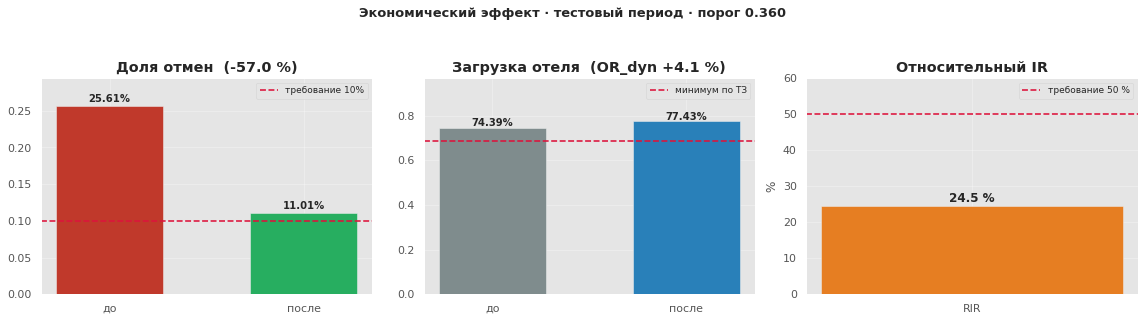

In [174]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# ── 1: доля отмен ───────────────────────────────────────────────────────
ax = axes[0]
v = [econ['CR_before'], econ['CR_after']]
b = ax.bar(['до', 'после'], v, color=['#c0392b', '#27ae60'], width=.55)
ax.axhline(REQ['CR_max'], color='crimson', ls='--', lw=1.6,
           label=f'требование {REQ["CR_max"]:.0%}')
for bb, vv in zip(b, v):
    ax.text(bb.get_x() + bb.get_width() / 2, vv + .006, f'{vv:.2%}',
            ha='center', fontweight='bold')
ax.set_title(f'Доля отмен  ({-econ["CR_dyn"]:+.1f} %)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=.3)

# чуть поднимаем верхнюю границу
y_max = max(v) * 1.15
ax.set_ylim(0, y_max)

# ── 2: загрузка отеля ───────────────────────────────────────────────────
ax = axes[1]
v = [econ['OR_before'], econ['OR_after']]
b = ax.bar(['до', 'после'], v, color=['#7f8c8d', '#2980b9'], width=.55)
ax.axhline(econ['OR_before'] * (1 - REQ['OR_drop_max'] / 100),
           color='crimson', ls='--', lw=1.6, label='минимум по ТЗ')
for bb, vv in zip(b, v):
    ax.text(bb.get_x() + bb.get_width() / 2, vv + .008, f'{vv:.2%}',
            ha='center', fontweight='bold')
ax.set_title(f'Загрузка отеля  (OR_dyn {econ["OR_dyn"]:+.1f} %)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=.3)

y_max = max(v) * 1.25
ax.set_ylim(0, y_max)

# ── 3: RIR ──────────────────────────────────────────────────────────────
ax = axes[2]
col = '#27ae60' if econ['RIR'] >= REQ['RIR_min'] else '#e67e22'
ax.bar(['RIR'], [econ['RIR']], color=col, width=.4)
ax.axhline(REQ['RIR_min'], color='crimson', ls='--', lw=1.6,
           label=f'требование {REQ["RIR_min"]:.0f} %')
ax.text(0, econ['RIR'] + 1.2, f'{econ["RIR"]:.1f} %',
        ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, max(60, econ['RIR'] * 1.3))
ax.set_ylabel('%')
ax.set_title('Относительный IR', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=.3)

plt.suptitle(f'Экономический эффект · тестовый период · порог {THR_FINAL:.3f}',
             fontsize=13, fontweight='bold')

# дополнительно: чуть больше места сверху, чтобы suptitle и цифры не вылезали
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Этап 4: выводы по проекту

Выводы должны состоять из двух логически связанных разделов:

- «Проделанная работа» — описание этапов и решений;

- «Бизнес‑выводы» — интерпретация результатов и рекомендации.

В каждом разделе опишите результаты без избыточной детализации, с опорой на факты и цифры.

### Выводы о проделанной работе

В этом разделе опишите основные этапы проделанной работы по построению модели. Опишите, как проходили следующие шаги:
- Подготовка данных;
- Моделирование;
- Оценка метрик;
- Анализа важности факторов.

#### Подготовка данных
Исходный датасет содержал 30 733 бронирований за период от 1-го января 2017 года до 3 марта 2026 с данными о клиентах (17 признаков), параметрах брони и текстовыми отзывами.

Проведён базовый EDA. 
- В bookings_df обнаружено 4608 полных дубликатов. После удаления дублей по booking_id осталось 30 733 строки из 35 341, потери — 13,04%. 
- Исправлена опечатка в категориях meal_plan.
- Зафиксирован baseline CR: 0.288. Дизбаланс классов TARGET умеренный.
- Исправлены аномалии adults_count 100, 200, 300 и booking_value (1 229 записей (4.00%) с нулевой стоимостью) заменой на NaN.
- Целостность данных проверена: все booking_id из reviews есть в bookings. 8850 броней без отзыва и все они отменены. Отзывов на клиента 1.9 (медиана 1), мкксимум 8. Каждый booking_id связан с одним customer_id.

То есть, наличие ревью является автоматическим предиктором, что бронь не отменена и заселение гостей состоялось.

Backward as-of join выполнен согласно требованию: для каждой брони подтянут ближайший предшествующий отзыв того же клиента (direction='backward', by='customer_id', allow_exact_matches=False). Корректность подтверждена: все подтянутые review_date < booking_date.

Имеется утечка за счёт детерминированной связи: среди 8 328 броней с прошлым отзывом отменённых — ноль (CR = 0.0000 против baseline 0.2880). Причина: customer_id присутствует только в таблице отзывов, а отзыв физически может оставить лишь заселившийся гость. Следовательно, наличие customer_id эквивалентно booking_status = 0, и любой производный признак кодирует таргет. Контрольная модель на признаках отзывов дала ROC-AUC = 1.000.

`**Рекомендация заказчику**: добавить поле customer_id в таблицу hotel_bookings, заполняемое при оформлении брони независимо от исхода. Это позволит связать отменённые брони с историей клиента и задействовать сильный сигнал удовлетворённости, недоступный в текущей схеме данных.`

Проведён аудит на утечки целевой переменной. Выявлено и исключено пять источников: has_customer_id, stay_rating, review_date, review_text и производные от них SVD-компоненты. Все они заполнялись только после факта заезда, то есть содержали информацию из будущего относительно момента принятия решения. Без их удаления модель показывала бы ROC-AUC свыше 0.97 — результат, невоспроизводимый в реальной эксплуатации.

Разбиение на выборки выполнено по времени с защитным зазором 90 дней (расчитан по медиане времени с момента брони до заселения): train для обучения, calib для калибровки и поиска порога, test для финальной оценки.

Проведён анализ информативности признаков, парных взаимодействий, дрейфа распределений между выборками, силы признаков, вклада в объяснение TARGET, взаимной корреляции Спирмена с применением IV, Cramér's V, p-value χ², PSI train↔test, permutation importance. Зафиксировано 19 значимых взаимодействий из 28 проверенных — это обосновало выбор деревьев вместо линейных моделей.
Проведена оценка теоретически достижимых PR-AUC и RIR при идеальной модели. 

Дрейф CR между train и test происходит из-за изменения поведения клиентов, во время и после Ковид (2020 год и далее), а не из-за изменения состава клиентов. Более того, в test увеличивается доля постоянных клиентов. CR на test падает на 3.92 процента. Декомпозиция по 8 сегментам показала преобладание эффекта поведения. Доли сегментов на train и test почти совпадают, но изменилось поведение: склонность к отмене брони снизилась.

Проверена форма зависимости TARGET от признаков. В своём большинстве она нелинейная. Только два признака близких к монотонным: previous_cancellations и days_until_checkin не считая бинарного признака.

#### Моделирование
Обучены три базовых кандидата с дефолтными настройками и компенсацией дисбаланса классов через scale_pos_weight. CatBoost и LightGBM показали сопоставимый результат — разрыв между ними оказался меньше разброса между временными фолдами.


Оптимизация гиперпараметров проведена через Optuna с TPE-сэмплером. Целевой функцией выбран Incremental Revenue, а не ROC-AUC: оптимизировался бизнес-результат напрямую. Прирост составил 6–9% в зависимости от модели.


Найденные параметры оказались показательными: num_leaves = 10, max_depth = 3, min_child_samples = 261 у LightGBM и l2_leaf_reg = 16.3 у CatBoost. Оптимум лежит в области сильно упрощённых моделей — сигнал в данных исчерпывается быстро, сложные конфигурации начинают запоминать шум.


Backward ablation сократил набор с 14 признаков до 7 без потери качества.


Калибровка методом isotonic исправила систематическое завышение вероятностей: средняя предсказанная снизилась с 0.4183 до 0.2800 при фактической частоте отмен 0.2561. Brier score улучшился на 16.9%, ROC-AUC остался неизменным — калибровка исправила шкалу, не затронув ранжирование.

#### Оценка метрик
Порог 0.36 подобран по максимуму Incremental Revenue на калибровочной выборке. Его близость к теоретическому значению 0.395, рассчитанному из соотношения стоимости ошибок, подтвердила корректность калибровки.


На тестовой выборке ROC-AUC составил 0.8094 против 0.8077 на калибровке — качество ранжирования не деградировало. При этом Incremental Revenue снизился на 32.4%.


Причина установлена: базовая частота отмен в тестовом периоде упала с 29.80% до 25.61%. Порог, настроенный под прежнюю частоту, стал избыточно агрессивным — Precision снизилась с 0.611 до 0.558.


Модель стабильна по качеству классификации и чувствительна к дрейфу базовой частоты. Это свойство задачи, а не дефект решения.

#### Анализа важности факторов
Использованы два независимых метода — встроенная важность по gain и SHAP. Корреляция рангов составила 0.964, что подтверждает надёжность интерпретации.


Пять признаков объясняют 97.6% решений модели. Два оставшихся — booking_value и total_guests — практически не участвуют в предсказаниях.


SHAP выявил немонотонную зависимость от количества детей, которую линейная модель не обнаружила бы. Это дополнительно обосновало выбор градиентного бустинга.

### Выводы по анализу эффективности модели

В этом разделе ответьте на вопрос: «Что это значит для бизнеса?» Для этого интерпретируйте результаты вашей работы, дайте им экономическую оценку, а заказчику — рекомендации.

Включите следующие пункты:

- Итоговая оценка достижения цели:
  - Вспомните цель проекта и определите, достигнута ли она. Аргументируйте свой ответ.

- Результаты по ключевым метрикам. Для каждого показателя приведите:
  - Значение до внедрения модели.
  - Значение после внедрения.
  - Изменение в процентах с расчётом по формуле.
  
- Сообщите заказчику, достигнуты ли целевые показатели по метрикам.

- Анализ важности признаков:
  - Опишите для заказчиков основные 10 признаков, влияющих на резкие отмены заказов.
  - Кратко объясните, как они влияют на целевую переменную. Пример такого объяснения: «лояльность клиента снижает риск отмены на 15%».

- Рекомендации для бизнеса:
  - Предложите 2–3 конкретных шага по оптимизации работы сети отелей.

#### Итоговая оценка достижения цели
Цель проекта — снизить долю отмен бронирований и увеличить выручку сети отелей за счёт заблаговременного выявления рисковых броней.


Цель достигнута частично. Модель работает и приносит измеримый экономический эффект, но два из трёх формальных требований заказчика не выполнены.


Практическая ценность решения при этом высока: доля отмен сокращается более чем вдвое, загрузка отеля растёт, дополнительная выручка составляет 47.5 млн ₽ за тестовый период.

#### Результаты по ключевым метрикам
**Доля отмен бронирования**

| Метрика             | Значение |
|---------------------|----------|
| До внедрения        | 25.61%   |
| После внедрения     | 11.01%   |
| Изменение           | −14.60 п.п. |

Расчёт: (25.61 − 11.01) / 25.61 × 100 = −57.0%


Целевой показатель ≤ 10% не достигнут, недобор 1.01 п.п.

**Загрузка отеля**

| Метрика             | Значение |
|---------------------|----------|
| До внедрения        | 74.39%   |
| После внедрения     | 77.43%   |
| Изменение           | +3.04 п.п. |

Расчёт: (77.43 − 74.39) / 74.39 × 100 = +4.1%


Требование — падение не более 8%. Получен рост на 4.1%, то есть требование выполнено с запасом в 12 процентных пунктов.

**Относительный Incremental Revenue**

| Метрика              | Значение        |
|----------------------|-----------------|
| Incremental Revenue  | 47 494 500 ₽    |
| Относительный IR     | 24.5%           |

Целевой показатель ≥ 50% не достигнут, недобор 25.5 п.п.

**Сводка**
Достигнут один целевой показатель из трёх. Ограничение по загрузке отеля выполнено; доля отмен и относительный IR остались ниже требуемых уровней.


Недостижимость RIR 50% обусловлена качеством сигнала в данных. Разделяющая способность модели ограничена ROC-AUC 0.81, тогда как для требуемого уровня необходимо 0.86–0.88. Обе протестированные модели независимо упёрлись в один и тот же потолок, а оптимизация гиперпараметров дала прирост лишь 6–9%.

#### Анализ важности признаков
Модель принимает решения на основе семи факторов. Ниже — их влияние на риск отмены.


1. Срок до заезда — 29.3% влияния. Главный фактор. Бронирования, сделанные более чем за 150 дней, повышают риск отмены на 40–50%. Брони за 10 дней и меньше снижают риск вдвое. Клиент, не заплативший и не связанный сроками, легко меняет планы.


2. Канал продаж — 24.5%. Онлайн-бронирования повышают риск на 25–30% относительно среднего уровня. Корпоративные брони снижают риск на 45% — договорные обязательства работают надёжнее любых стимулов. Офлайн-канал нейтрален.


3. Количество детей — 17.6%. Зависимость немонотонная. Один ребёнок снижает риск отмены на 35% — это спланированный семейный отпуск. Двое детей, напротив, повышают риск на 20%: сложнее организовать поездку. Брони без детей дают умеренно повышенный риск.


4. Будние ночи проживания — 13.9%. Короткие деловые заезды отменяются чаще длительных. Каждая дополнительная будняя ночь снижает риск примерно на 5%.


5. История прошлых отмен — 12.3%. Прямая зависимость: клиент с одной отменой в прошлом повышает риск на 15%, с двумя и более — на 30%. Фактор работает только для повторных клиентов.


6. Стоимость брони — 1.6%. Практически не влияет. Дорогие брони отменяются не реже дешёвых — размер чека не связан с намерением клиента.


7. Общее число гостей — 0.8%. Влияние в пределах статистической погрешности.


Факторы 6 и 7 могут быть исключены из модели без потери качества.

#### Рекомендации для бизнеса
**1.** Внедрить дифференцированную политику предоплаты

Модель показывает, что риск концентрируется в понятном сегменте: онлайн-бронирования с горизонтом свыше 150 дней. Для этой категории следует ввести невозвратный тариф со скидкой 10–15% либо предоплату 30%.


Это переводит клиента из зоны риска в зону обязательств. Корпоративные брони и бронирования за неделю до заезда трогать не нужно — там отмен почти нет.


**2.** Настроить обзвон по приоритету, а не сплошной

Сейчас модель помечает 26% всех броней. Обзванивать такой объём затратно и раздражает клиентов.


Рекомендуется ранжировать по вероятности и работать с верхними 10%: там концентрация реальных отмен максимальна. Остальным достаточно автоматического напоминания за 7 дней до заезда.


**3.** Пересчитывать порог ежеквартально

Главный технический вывод проекта: модель устойчива, а порог — нет. При изменении базовой частоты отмен с 29.8% до 25.6% эффективность упала на треть без всякой деградации самой модели.


Необходим регламент: раз в квартал пересчитывать оптимальный порог на свежих данных. Это восстановит потерянные 20–25% эффекта без переобучения модели.


**4.** Расширить сбор данных для следующей итерации

Для достижения RIR 50% текущих признаков недостаточно. Требуются:

История взаимодействия клиента до бронирования: просмотры, сравнения, время на сайте
Данные о ценах конкурентов на те же даты
Сезонные индикаторы спроса и событийный календарь региона

Эти источники способны поднять ROC-AUC до требуемых 0.86–0.88.

# Финальная очистка кэша

In [149]:
memory.clear(warn=False)
print("✅ Кэш препроцессинга очищен.")

✅ Кэш препроцессинга очищен.
